# 023. State Space Model / Mamba / State Space Model and Mamba

## 1. 概要 / Overview

状態空間モデル(State Space Model)は、連続時間の線形な力学系 $h'(t) = A h(t) + B x(t)$、$y(t) = C h(t)$ を離散化し、固定サイズの状態 $h$ を持つ再帰として系列を処理するモデルである。Mamba(Gu & Dao [1])は、離散化の刻み幅 $\Delta$ と行列 $B$・$C$ を **入力の関数にする**(選択的な状態空間モデル、Selective State Space Model)ことで、入力の内容に応じて状態に記憶するか無視するかを切り替えられるようにした。学習時の計算量は系列長 $L$ に線形で、推論時は 1 トークンあたり一定の時間と一定サイズの状態で済み、注意機構(Attention Mechanism)の $O(L^2)$ の計算量や、系列長に比例して増える KV キャッシュ(010)を持たない。

本トピックでは、ゼロ次ホールド(zero-order hold)による離散化、選択的な状態空間モデルの走査(scan)、Mamba ブロック、状態を持ち回る推論をスクラッチ実装し(公式の CUDA カーネルを含むパッケージは使わず、走査は逐次ループで書く)、次の 3 つを判定つきで検証する。(A)selective copying の課題で、選択的な構成が非選択の構成より正解率が高いか。(B)順伝播の時間の系列長に対するべき指数が、注意機構の層の方が Mamba の層より大きいか。(C)induction heads の課題で、学習時より長い系列に伸ばしたときの正解率の低下が、RoPE を使う Transformer の方が Mamba より大きいか。あわせて、(D)Mamba の言語モデルを 008 のレシピで学習し、008 の Transformer と同じ評価窓で検証 bits-per-byte を測る動作確認を、判定基準を設けずに行う。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。学習を始める前に(6.4 節)、T4 上でのスケーリングの計測(6.3 節)から、7 通りの **実行計画**(6.1 節。実験 D の学習ステップ数・実験 D の省略・実験 A のシード数・実験 C のシード数・実験 A と C の学習ステップ数を、この順に 1 つずつ削る)のそれぞれについて残りの実行時間を見積もり、予算に収まる計画のうち番号の最も小さいものを自動で選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。**選ばれた計画は 6.4 節の出力に印字される。** 事前の計測のための実行やセッションの分割はしない。

**見積もりが最も下位の計画でも予算を超える場合は、学習の前に停止する。** その場合は結果の情報を何も得ていないので、実行条件(判定基準・水準・前提条件以外)を直して再実行する。

学習したモデルは、すべて条件間の比較または動作確認のためのものであり、Hugging Face Hub にはアップロードしない。

### 1.2 本番実行の結果の要約

(本番実行の後に記入する。7 節の末尾の「本番実行の後に更新が必要な箇所」を参照。)

## 2. 参考論文 / References

1. Gu, A., Dao, T.,
   "Mamba: Linear-Time Sequence Modeling with Selective State Spaces", COLM 2024(arXiv:2312.00752). https://arxiv.org/abs/2312.00752
   (選択的な状態空間モデル、Mamba ブロック、Theorem 1、selective copying と induction heads の課題。本トピックの原典。3.4〜3.9 節、実験 A・B・C・D)
2. Gu, A., Goel, K., Ré, C.,
   "Efficiently Modeling Long Sequences with Structured State Spaces", ICLR 2022. https://arxiv.org/abs/2111.00396
   (S4。時不変な状態空間モデルの畳み込みとしての計算。3.3 節、位置づけ)
3. Gu, A., Dao, T., Ermon, S., Rudra, A., Ré, C.,
   "HiPPO: Recurrent Memory with Optimal Polynomial Projections", NeurIPS 2020. https://arxiv.org/abs/2008.07669
   (状態行列 $A$ の初期化の理論的な背景。3.3 節、位置づけのみ)
4. Jing, L., Gulcehre, C., Peurifoy, J., Shen, Y., Tegmark, M., Soljačić, M., Bengio, Y.,
   "Gated Orthogonal Recurrent Units: On Learning to Forget", Neural Computation 31(4), 2019(arXiv:1706.02761). https://arxiv.org/abs/1706.02761
   (selective copying の課題の出典。原論文 [1] は denoising task と同じものとしている。実験 A)
5. Olsson, C., Elhage, N., Nanda, N., Joseph, N., DasSarma, N., Henighan, T., Mann, B., Askell, A., Bai, Y., Chen, A., Conerly, T., Drain, D., Ganguli, D.,
   Hatfield-Dodds, Z., Hernandez, D., Johnston, S., Jones, A., Kernion, J., Lovitt, L., Ndousse, K., Amodei, D., Brown, T., Clark, J., Kaplan, J., McCandlish, S., Olah, C.,
   "In-context Learning and Induction Heads", Transformer Circuits Thread, 2022(arXiv:2209.11895). https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/
   (induction heads の出典。実験 C)
6. Dao, T., Gu, A.,
   "Transformers are SSMs: Generalized Models and Efficient Algorithms Through Structured State Space Duality", ICML 2024(arXiv:2405.21060). https://arxiv.org/abs/2405.21060
   (Mamba-2。3.10 節、位置づけのみ。論文の題名に含まれる略語は原題のまま)
7. Gu, A., Gupta, A., Goel, K., Ré, C.,
   "On the Parameterization and Initialization of Diagonal State Space Models", NeurIPS 2022. https://arxiv.org/abs/2206.11893
   (対角の状態行列の初期化 S4D-Real と、$B = 1$・$C$ を標準正規分布とする初期化。3.6 節、非選択の構成の初期化)

公式の参照実装(`state-spaces/mamba`のリポジトリ、`selective_scan_ref`・`Mamba`クラス)は、離散化の簡略形 $\bar{B} x = \Delta B x$、$\Delta$ の初期化(対数一様分布から引いて softplus の逆関数をバイアスに書く)、低ランクの射影の次元(`dt_rank`、既定は $\lceil d_{\mathrm{model}} / 16 \rceil$)の確認に用いた。

本文で用いる既存トピックの部品: 注意機構と因果マスクは [001](../01_foundations/001_attention_mechanism.ipynb)、RoPE は [003](../01_foundations/003_positional_encoding_rope.ipynb)、RMSNorm と SwiGLU は [004](../01_foundations/004_normalization_and_activation.ipynb)、小型 GPT と bits-per-byte は [006](../02_pretraining/006_pretraining_small_gpt.ipynb)、AdamW・warmup + cosine・gradient clipping は [007](../02_pretraining/007_training_stabilization.ipynb)、本トピックの実験 D が踏襲する事前学習のレシピと比較の相手は [008](../02_pretraining/008_decoding_strategies.ipynb)、KV キャッシュは [010](../03_efficient_training/010_kv_cache_and_inference_compute.ipynb)、FP16 の autocast と動的損失スケーリングは [011](../03_efficient_training/011_mixed_precision_training.ipynb)、時間計測の手順(ウォームアップ・交互実行・ドリフトの不在と平均の標準誤差の前提条件)は [010](../03_efficient_training/010_kv_cache_and_inference_compute.ipynb) と [014](../03_efficient_training/014_flash_attention.ipynb)、単体テストの許容誤差の導出は [022](022_mixture_of_experts.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: 系列長に対する計算量と、推論時に増え続ける状態

注意機構(001)は、長さ $L$ の系列の全対の位置の間でスコア $q_i^\top k_j$ を計算する。計算量は $O(L^2 d_{\mathrm{model}})$、スコア行列を実体化する実装ではメモリも $O(L^2)$ である(014 の Flash Attention はこのメモリを避ける)。自己回帰の生成では、過去の Key と Value を保持する KV キャッシュが必要で、そのサイズは系列長に比例して増える(010)。

再帰型のモデルは、系列を先頭から 1 つずつ読み、固定サイズの状態 $h_t$ に過去を圧縮して持ち回る。1 トークンあたりの計算量も状態のサイズも系列の長さによらず一定である。一方で、古典的な再帰型ニューラルネットワーク(Recurrent Neural Network)は学習時に時間方向の計算を並列化しにくく、状態が小さいぶん過去の情報の取りこぼしが起こる。Gu & Dao [1] は、系列モデルの効率と効果のトレードオフを「文脈をどれだけうまく状態に圧縮できるか」で特徴づけ、**何を状態に入れて何を捨てるかを入力の内容で決められる** 状態空間モデルとして Mamba を提案した。

### 3.2 連続時間の状態空間モデル

1 つのチャネルについて、入力 $x(t) \in \mathbb{R}$ から出力 $y(t) \in \mathbb{R}$ への写像を、$N$ 次元の状態 $h(t) \in \mathbb{R}^N$ を介して次の連立の微分方程式で定める。

$$
h'(t) = A h(t) + B x(t), \qquad y(t) = C h(t)
$$

$A \in \mathbb{R}^{N \times N}$ は状態の時間発展、$B \in \mathbb{R}^{N \times 1}$ は入力が状態に入る経路、$C \in \mathbb{R}^{1 \times N}$ は状態から出力を読み出す経路である(原論文 [1] の式 (1))。Mamba は $D$ 個のチャネルのそれぞれに、独立な $(A, B, C)$ を持つこの系を適用する(チャネルの間の混合は、ブロックの前後の線形射影が担う)。以下、$A$ は対角行列とし、チャネル $d$ の状態 $n$ の対角成分を $a_{d,n}$ と書く。

### 3.3 ゼロ次ホールドによる離散化

系列を扱うために、刻み幅 $\Delta > 0$ ごとに離散化する。ゼロ次ホールドは、区間 $[t_k, t_k + \Delta]$ の間、入力を一定値 $x_k$ とみなす。定数変化法により、この区間の解は

$$
h(t_k + \Delta) = e^{\Delta A} h(t_k) + \int_0^{\Delta} e^{(\Delta - s) A} B x_k \, ds
= e^{\Delta A} h(t_k) + A^{-1} \left( e^{\Delta A} - I \right) B x_k
$$

である($A$ が可逆のとき、$I$ は単位行列。2 つ目の等号は $\int_0^\Delta e^{(\Delta - s) A} ds = A^{-1} (e^{\Delta A} - I)$ による)。したがって離散化した系は $h_k = \bar{A} h_{k-1} + \bar{B} x_k$、$y_k = C h_k$ となり、

$$
\bar{A} = \exp(\Delta A), \qquad \bar{B} = (\Delta A)^{-1} \left( \exp(\Delta A) - I \right) \cdot \Delta B
$$

である(原論文 [1] の式 (4)。$(\Delta A)^{-1} \Delta = A^{-1}$ なので上の式と一致する)。**$A$ が対角のとき**、すべてが要素ごとの式になる。

$$
\bar{A}_{d,n} = e^{\Delta a_{d,n}}, \qquad \bar{B}_{d,n} = \frac{e^{\Delta a_{d,n}} - 1}{a_{d,n}} B_{d,n}
$$

実装(`src/layers/mamba.py`の`discretize_state_space()`)はこの式を全時刻・全チャネル・全状態について一括で計算する。5.5 節の単体テストでは、拡大した行列 $\begin{pmatrix} a & b \\ 0 & 0 \end{pmatrix}$ の行列指数関数が $\begin{pmatrix} e^{\Delta a} & b (e^{\Delta a} - 1) / a \\ 0 & 1 \end{pmatrix}$ になることを使い、`torch.linalg.matrix_exp`から $\bar{A}$ と $\bar{B}$ を読んで、上の式と独立に照合する。

**公式実装の簡略形**: 公式の参照実装(`selective_scan_ref`)は、$\bar{A} = \exp(\Delta A)$ はそのまま使い、$\bar{B}$ だけを $\bar{B} = \Delta B$ とする(入力の項は`delta * B * u`)。$u = \Delta a_{d,n}$ とおくと $(e^u - 1) / u = 1 + u/2 + u^2/6 + \cdots$ なので、ゼロ次ホールドの $\bar{B}$ は

$$
\bar{B}_{d,n} = \Delta B_{d,n} \left( 1 + \frac{u}{2} + \frac{u^2}{6} + \cdots \right)
$$

であり、簡略形はこの級数の 1 項目だけを残した $\Delta$ についての 1 次の近似である。相対差は $u/2 + O(u^2)$ で、$\Delta \to 0$ で 0 に近づく。一方、$\Delta \lvert a_{d,n} \rvert$ が大きいときの $\bar{B}$ は、ゼロ次ホールドでは $-B_{d,n} / a_{d,n}$ に飽和し、簡略形では $\Delta B_{d,n}$ のまま増え続ける。本トピックの主構成はゼロ次ホールドで、簡略形は引数で切り替えられる(`discretization="euler"`)。

### 3.4 時不変な系は畳み込みで表せる。しかし入力の内容を見られない

$\Delta$・$A$・$B$・$C$ が時刻によらない(時不変、linear time-invariant)とき、離散化した再帰を展開すると

$$
y_t = \sum_{s=0}^{t} K_{t-s} \, x_s, \qquad K_k = C \bar{A}^k \bar{B}
$$

となり、系全体は入力に依存しないカーネル $K$ との畳み込みである(S4 [2] の畳み込み表現)。畳み込みは高速フーリエ変換などで並列に計算できるので、学習は効率的になる。5.5 節の単体テストでは、再帰の出力が $K_k = C \bar{A}^k \bar{B}$ との畳み込みに一致することと、入力を遅らせると出力も遅れるだけ(時不変性)であることを確かめる。

しかしカーネル $K$ は入力 $x$ に依存しないので、**どの入力を状態に取り込み、どれを無視するかを内容によって決められない**。原論文 [1] は、この限界を 2 つの課題で示す(3.9 節の実験 A・C)。selective copying は、ノイズの間にランダムな位置で置かれたデータのトークンを順序を保って出力する課題で、入力から出力までの間隔が事例ごとに変わるので、固定のカーネルでは表せない。induction heads は、文脈の中で以前に見た組(あるトークンとその直後のトークン)を、同じトークンが再び現れたときに思い出す課題である。

状態行列 $A$ の初期化には、HiPPO [3] の理論(過去の入力を直交多項式で最適に近似する状態の更新)に基づく S4D-Real [7] を使う。状態 $n$($0$ 始まり)の対角成分を $a_{d,n} = -(n + 1)$ とする。HiPPO の導出は本トピックでは扱わず、位置づけのみとする。

### 3.5 選択的な状態空間モデル

選択的な構成では、$\Delta$・$B$・$C$ を入力 $x_t$ の関数にする(原論文 [1] の Algorithm 2)。

$$
B_t = s_B(x_t) = \mathrm{Linear}_N(x_t), \qquad C_t = s_C(x_t) = \mathrm{Linear}_N(x_t), \qquad
\Delta_t = \tau_\Delta \left( \mathrm{Parameter} + s_\Delta(x_t) \right), \quad \tau_\Delta = \mathrm{softplus}
$$

$\mathrm{Linear}_N$ は $N$ 次元への線形射影、$\mathrm{Parameter}$ は学習可能なチャネルごとのバイアスである。原論文は $s_\Delta(x) = \mathrm{Broadcast}_D(\mathrm{Linear}_1(x))$(1 次元に射影して全チャネルに複製する)とし、その一般化として $\mathrm{Linear}_D(\mathrm{Linear}_R(x))$(低ランクの射影、$R$ は $D$ の小さな一部)を述べている。公式の実装と本トピックは後者を使い、$R = \lceil d_{\mathrm{model}} / 16 \rceil$ とする。$\bar{A}_t = \exp(\Delta_t A)$ と $\bar{B}_t$ は時刻ごとに変わり、再帰は

$$
h_t = \bar{A}_t h_{t-1} + \bar{B}_t x_t, \qquad y_t = C_t h_t
$$

である。時刻ごとに系が変わるので畳み込みでは表せず、計算は走査(scan)になる。形状は、$x$ が $(b, L, D)$($b$ はバッチサイズ)、選択的な構成の $B_t$・$C_t$ が $(b, L, N)$(全チャネルで共通)、$\Delta_t$ が $(b, L, D)$ である。

**$\Delta$ の役割**: $a_{d,n} < 0$ のとき、$\Delta \to 0$ では $\bar{A} \to 1$ かつ $\bar{B} x \to 0$ で、状態をそのまま保って現在の入力を無視する。$\Delta \to \infty$ では $\bar{A} \to 0$ かつ $\bar{B} \to -B / a$ で、状態を捨てて現在の入力に集中する。したがって $\Delta_t$ は「このトークンを状態に取り込むか」を決めるゲートとして働き、ノイズのトークンで $\Delta_t$ を小さく、データのトークンで大きくすれば、selective copying の間隔の変動に対処できる(実験 A の診断量)。

**パラメータ化と初期化**: $\tau_\Delta = \mathrm{softplus}$ は $\Delta > 0$ を保証する。$\mathrm{Parameter}$ は、$\Delta$ の初期値が $[10^{-3}, 10^{-1}]$ に入るよう、$\mathrm{softplus}$ の逆関数で書き込む。原論文は $\tau_\Delta^{-1}(\mathrm{Uniform}([0.001, 0.1]))$ と記し、公式の実装は対数一様分布から引く。本実装は公式の実装に従う。$B$・$C$ の射影の重みは各層の既定の初期化である。

**非選択の構成**(実験 A の条件 2): $\Delta$・$B$・$C$ を入力によらない学習可能なパラメータにする(原論文 [1] の Algorithm 1)。$\Delta$ はチャネルごとのスカラー($\mathrm{softplus}$ の逆関数で初期化)、$B$・$C$ は形状 $(D, N)$ のパラメータで、初期値は S4D [7] に従い $B = 1$、$C$ は標準正規分布とする。ブロックの他の構成要素(射影・畳み込み・ゲート・$A$・スキップ接続)は選択的な構成と同一なので、2 つの構成の差は $\Delta$・$B$・$C$ が入力に依存するかどうかに限られる(ただし、入力から $\Delta$・$B$・$C$ を作る射影のパラメータは選択的な構成だけが持ち、非選択の構成は $B$・$C$ のパラメータを持つ。パラメータ数の差は 5.5 節の出力にある)。

### 3.6 ゲートつき再帰型ネットワークとの対応(原論文 Theorem 1)

**命題**(原論文 [1] の Theorem 1): $N = 1$、$A = -1$、$B = 1$、$s_\Delta(x) = \mathrm{Linear}(x)$、$\tau_\Delta = \mathrm{softplus}$ のとき、選択的な状態空間モデルの再帰は、$g_t = \sigma(\mathrm{Linear}(x_t))$($\sigma$ はシグモイド関数)として

$$
h_t = (1 - g_t) h_{t-1} + g_t x_t
$$

になる。

**導出**: $z_t = \mathrm{Linear}(x_t)$ とおくと $\Delta_t = \mathrm{softplus}(z_t) = \log(1 + e^{z_t})$ である。$A = -1$ なので $\bar{A}_t = e^{-\Delta_t} = 1 / (1 + e^{z_t}) = \sigma(-z_t) = 1 - \sigma(z_t) = 1 - g_t$。$B = 1$ なので、3.3 節の式から $\bar{B}_t = (e^{-\Delta_t} - 1) / (-1) = 1 - e^{-\Delta_t} = g_t$。よって $h_t = (1 - g_t) h_{t-1} + g_t x_t$ である。

これは古典的な再帰型ネットワークの更新ゲートそのものである。$\Delta_t$ は「ゲートを一般化したもの」で、$g_t \to 0$ で入力を無視して状態を保ち、$g_t \to 1$ で状態を捨てて現在の入力に置き換える。5.5 節の単体テストで、$\bar{A} = 1 - g$、$\bar{B} = g$ と、走査の出力が上の再帰に一致することを、走査とは独立なスカラーのループで確かめる。

### 3.7 Mamba ブロックの構成

Mamba ブロック(原論文 [1] の Figure 3)は、H3 のブロックと Transformer の順伝播ネットワークのブロックを 1 つにまとめた構造で、Transformer の注意機構と順伝播ネットワークの 2 つのブロックを交互に積む代わりに、Mamba ブロックだけを繰り返し積む。モデルの次元 $d_{\mathrm{model}}$ を拡大率 $E$ で $D = E \, d_{\mathrm{model}}$ に広げ、状態空間モデルは $D$ 個のチャネルのそれぞれに適用する。$E$ は 022 のエキスパート数とは別の量である。

```mermaid
flowchart TD
    X["入力 x: (b, L, d_model)"] --> P["線形射影: d_model から 2D へ"]
    P --> XB["枝 1: x (D チャネル)"]
    P --> ZB["枝 2: z (D チャネル)"]
    XB --> CV["因果的な depthwise の 1 次元畳み込み (カーネル幅 K)"]
    CV --> S1["SiLU"]
    S1 --> SSM["選択的な状態空間モデル: Δ, B, C を x から作り、走査 + スキップ接続"]
    ZB --> S2["SiLU (ゲート)"]
    SSM --> M["要素ごとの積"]
    S2 --> M
    M --> O["出力の線形射影: D から d_model へ"]
    O --> R["残差接続 (外側の RMSNorm 前置のブロック)"]
```

- **因果的な畳み込み**: カーネル幅 $K = 4$ の depthwise(チャネルごと)の 1 次元畳み込みで、時刻 $t$ の出力は入力 $t - K + 1, \dots, t$ だけに依存する。状態空間モデルに入る前に、近傍のトークンの情報を混ぜる。
- **ゲート**: 枝 2 の $\mathrm{SiLU}(z)$(SiLU は Swish と同じ関数、004)を、状態空間モデルの出力に要素ごとに掛ける。このゲートは各時刻の入力だけを見るので、時間方向には作用しない。**ゲートは選択性ではない**(原論文 [1] の Appendix A)。実際、非選択の構成にもゲートはあり、実験 A はこの違いを測る。
- **パラメータ数**: 2 つの線形射影が $2 E d_{\mathrm{model}}^2 + E d_{\mathrm{model}}^2 = 3 E d_{\mathrm{model}}^2$ 個を占め、Transformer の 1 層(注意機構の $4 d_{\mathrm{model}}^2$ と順伝播ネットワークの $3 d_{\mathrm{model}} d_{\mathrm{ff}}$)より少ない。同じパラメータ数で比べると、Mamba は層の数が約 2 倍になる(実験 D)。
- **Mamba の言語モデル**: トークン埋め込み → [RMSNorm → Mamba ブロック → 残差接続] を層の数だけ積み、最終の RMSNorm と出力層(埋め込みと重みを共有)を置く。位置エンコーディングは持たない(再帰の構造が順序の情報を担う)。

### 3.8 計算量: 学習時は線形、推論時は 1 トークンあたり定数

| | 注意機構(KV キャッシュなし・あり) | Mamba |
|---|---|---|
| 学習・事前入力の処理の時間 | $O(L^2 d_{\mathrm{model}})$ | $O(L \, D N)$ |
| 学習時の主なメモリ(スコア・離散化した行列の実体化) | $O(L^2)$(スコア行列を実体化する実装) | $O(L \, D N)$(本実装は $\bar{A}_t$・$\bar{B}_t x_t$ を実体化する) |
| 推論で 1 トークンを出す時間 | $O(L \, d_{\mathrm{model}})$(KV キャッシュあり。長さ $L$ の Key・Value を読む) | $O(D N)$(文脈の長さによらず一定) |
| 推論で持ち回る状態 | KV キャッシュ: $2 L \, d_{\mathrm{model}}$ 要素(1 層、系列長に比例して増える) | $D N + D (K - 1)$ 要素(1 層。$h$ と畳み込みのバッファ。一定) |

Mamba の状態は文脈の長さによらず固定サイズなので、文脈が長くなっても推論のメモリが増えない。代償として、固定サイズの状態に文脈を圧縮するため、過去の任意のトークンを正確に引き出す能力は状態の大きさで制限される。

**並列走査(parallel scan)とハードウェアを意識した実装**: 再帰 $h_t = \bar{A}_t h_{t-1} + \bar{B}_t x_t$ は、組 $(a, b)$ の合成 $(a_2, b_2) \circ (a_1, b_1) = (a_2 a_1, \, a_2 b_1 + b_2)$ が結合的なので、並列走査で $O(\log L)$ の深さに並列化できる。原論文 [1] は、状態の展開 $(b, L, D, N)$ を GPU の低速なメモリに書き出さず、高速なメモリの中で離散化・走査・出力までを融合する実装で、実体化のメモリ量と読み書きの量を避けている。**本ノートブックの実装は逐次ループであり、$(b, L, D, N)$ のテンソルを実体化する。** そのため計算量の大きさ(べき指数)は理論どおり系列長に線形になりうるが、実測の絶対速度は公式の実装を代表しない。1 ステップあたりの Python の呼び出しの固定費が大きいので、短い系列では特にそうである(実験 B の解釈の注意)。

### 3.9 本トピックの 4 つの実験の位置づけ

| 実験 | 問い | 3 節の根拠 |
|---|---|---|
| A | 選択性は selective copying の正解率を上げるか | 3.4・3.5 節: 時不変な系は間隔の変動に対処できない |
| B | 順伝播の時間の系列長に対するべき指数は、注意機構の方が大きいか | 3.8 節: 学習時の計算量は Mamba が線形、注意機構が二次 |
| C | 長さの外挿で、正解率の低下は Transformer の方が大きいか | 3.8 節: 固定サイズの状態の再帰は、系列長に依存する位置の情報を持たない |
| D | Mamba の言語モデルは 008 のレシピで学習できるか(判定なし) | 3.7 節: ブロックの積層 |

### 3.10 位置づけのみ扱うもの

- **Mamba-2**(Dao & Gu [6]): 状態空間モデルと注意機構が、構造化された半可分行列(structured semiseparable matrix)を介して双対の関係にあることを示し(structured state space duality)、行列積に寄せたアルゴリズムで速度を上げた後継の手法。本トピックでは扱わない。
- **HiPPO の導出**(Gu et al. [3]): 状態行列 $A$ の初期化の理論的な背景。本トピックは S4D-Real の初期化を使うだけで、導出は扱わない。
- **構造化された状態空間モデルの計算法**(S4 [2] の Cauchy カーネルなど): 時不変な系の畳み込みを効率的に計算する工夫。本トピックは再帰と畳み込みの対応を小さな系で確かめるにとどめる。
- **ハイブリッド**(状態空間モデルの層と注意機構の層を混ぜる構成): 本トピックでは扱わない。

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/layers/mamba.py`: 離散化`discretize_state_space()`(ゼロ次ホールドと簡略形を引数で切り替え。対角の $A$ では要素ごとの式)、逐次ループによる走査`selective_scan()`(`Ā_t`と`B̄_t x_t`を全時刻ぶん一括で計算し、ループの中は状態の更新 $h_t = \bar{A}_t h_{t-1} + \bar{B}_t x_t$ と出力 $y_t = C_t h_t$ だけ。計算は`torch.autocast`の中でも FP32 以上。勾配が要るときは逆伝播を手で書いた`torch.autograd.Function`で包む)、1 ステップ更新`selective_scan_step()`、`MambaBlock`(線形射影による拡大、因果的な depthwise の 1 次元畳み込み、SiLU、選択的な状態空間モデル、ゲートの分岐、出力の射影。引数`selective`で $\Delta$・$B$・$C$ が入力の関数か、入力によらない学習可能なパラメータかを切り替える。推論用の`step()`、状態`MambaState`の受け渡し、activation checkpointing)。
- `src/models/mamba.py`: `MambaLanguageModel`(埋め込み → [RMSNorm → `MambaBlock` → 残差接続] の積層 → RMSNorm → 出力層)と、状態を持ち回る生成。正規化前置・埋め込みと出力層の重み共有・埋め込みの初期化(標準偏差 0.02)は 008 の`GPTLanguageModel`に揃えた。**揃えなかった点**: 位置エンコーディングを持たない、順伝播ネットワークを持たない(`MambaBlock`が注意機構と順伝播ネットワークの役割を担う)、層の初期化は各層の既定のまま(公式の実装が行う出力射影の重みの縮小は行わない)。
- `src/data/synthetic_sequence.py`: selective copying と induction heads の事例の生成(シードから決定的に生成、系列長を引数に取る)。
- `src/training/sequence_task.py`: ステップごとに新しい事例を生成する学習ループ`train_sequence_task()`(007 の`AdamW`・warmup + cosine・gradient clipping を再利用)と、評価関数(正解の履歴を与える評価、貪欲な生成による採点。生成した答えそのものを返す)。コーパスからランダムな区間を切り出す既存の`train_language_model()`は、合成課題には使えないので別に用意した。

**既存モジュールの再利用(変更なし)**: 注意機構`MultiHeadAttention`・`create_causal_mask`(001)と KV キャッシュ`KeyValueCache`(010)は実験 B、RoPE・RMSNorm・SwiGLU の`GPTLanguageModel`(008 と同じ構成)は実験 C・D、`train_language_model()`と`evaluate_bits_per_byte()`は実験 D、`AdamW`・warmup + cosine・`DynamicLossScaler`、`fit_power_law_exponent()`、`paired_bootstrap_ratio_of_sums()`をそのまま使う。**既存モジュールのコードは変更していない**(新しいファイルの追加のみ)ので、021 までと 022 の出力は変わらない。

**ノートブック内に直接書く(023 固有)**: 条件の定義、評価集合の生成、単体テストと不変条件の確認、学習率の較正、実行計画の選択、判定、可視化、スケーリングの計測、実験 B の時間計測、実験 D のコーパスの取得と評価窓。

**アップロード方針**: 本トピックで学習するモデルは、すべて条件間の比較または動作確認のためのものであり、後続トピックの入力にも、読者が単体で取得する対象にもならない。保存もアップロードもしない(アップロードのセルも置かない)。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| コーパス(Hub から取得できなかった場合の Wikipedia API からの取得結果) | `.cache/wikipedia_en/`(データ源で命名。決定的に再取得できる) |
| Hugging Face Hub から取得したコーパス・トークナイザ・008 のモデル | `huggingface_hub`の既定のキャッシュ(Colab ではセッションの終了とともに破棄される) |
| 合成課題の評価集合・学習データ | メモリ上のみ(シードから決定的に生成する。学習データは保存しない) |
| 符号化したトークン列・評価窓(実験 D) | メモリ上のみ |
| 学習したモデル(実験 A・C・D) | メモリ上のみ(評価の直後に破棄する) |
| 学習の履歴・生成した答え・正解の混同行列の元になる記録 | メモリ上のみ(判定と図に使う) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力(6.7〜6.9・6.12 節) |

**外部からの取得**(Colab のセットアップセルのリポジトリの取得と依存関係のインストールを除く):

| 取得するもの | リポジトリ | 用途 |
|---|---|---|
| コーパス(`corpus.txt`・`metadata.json`) | `kojikojiprg/ai-theories-corpus-en-pretraining`(Dataset、356 記事) | 実験 D: 008 と同じ英語 Wikipedia のコーパス |
| トークナイザ(`tokenizer.json`) | `kojikojiprg/ai-theories-tokenizer-en` | 実験 D: 008 の英語の BPE(Byte Pair Encoding)トークナイザ(語彙サイズ 8192) |
| 008 の学習済みモデル(`config.json`・`model_state.pt`、`main`) | `kojikojiprg/ai-theories-small-gpt-en` | 実験 D: 比較の相手(学習し直さない) |

実験 A・B・C は外部のデータを使わない(合成課題と乱数の入力のみ)。実験 D を省く計画が選ばれた場合は、上の 3 つのいずれも取得しない。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。実行環境はこのセルで 1 回だけ印字する。

**精度と決定性**: 実験 A・C の学習と、すべての評価・実験 B の計測は FP32 で行う。実験 D の学習は、CUDA のときは FP16 の`torch.autocast`と動的損失スケーリング(011 の`DynamicLossScaler`)で行い、走査は`torch.autocast`の中でも FP32 で計算する(3.8 節。5.5 節で確かめる)。それ以外のデバイス(ローカルの MPS・CPU)では FP32 で行う。`torch.use_deterministic_algorithms(True)`は使わない。同じシードの学習を繰り返しても結果が bit 単位では一致しないことがあるが、条件間の対応付け(同じシードの条件どうしで学習データの流れを揃えること)は乱数の生成器によって決まり、演算の決定性には依存しない(5.5・6.11 節で確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
USE_FP16_AUTOCAST = device.type == "cuda"  # FP16 の autocast と動的損失スケーリングは、CUDA での実験 D の学習のみ
execution_environment = print_execution_environment(device)
print(
    f"SMOKE_TEST={SMOKE_TEST}、実験 A・C の学習の精度 FP32、実験 D の学習の精度 "
    f"{'FP16 の autocast + 動的損失スケーリング(走査は FP32)' if USE_FP16_AUTOCAST else 'FP32'}、評価は FP32、"
    f"決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}"
)

読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 3 個(packaging==26.3, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 51 個、__version__ がないため比べなかった配布物 1 個(typing-extensions)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)


実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : 43fcfc3f5e0eb5a17766e36403e36d1dd5b44e8a
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-10-03T06:52:59+00:00
SMOKE_TEST=True、実験 A・C の学習の精度 FP32、実験 D の学習の精度 FP32、評価は FP32、決定的な演算の強制: False


### 5.2 インポートと共通の関数

In [2]:
import functools
import hashlib
import itertools
import json
import math
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torch.nn import functional

from src.data.synthetic_sequence import (
    IGNORE_INDEX,
    InductionHeadsTask,
    SelectiveCopyingTask,
    generate_induction_heads,
    generate_selective_copying,
    induction_heads_targets,
    make_rng,
)
from src.data.text import (
    encode_corpus,
    load_wikipedia_corpus_with_fallback,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.generation.cache import KeyValueCache
from src.layers.attention import MultiHeadAttention, create_causal_mask
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.mamba import MambaBlock, discretize_state_space, selective_scan
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.models.mamba import MambaLanguageModel
from src.training.optimizer import AdamW
from src.training.precision import DynamicLossScaler
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.sequence_task import (
    evaluate_induction_heads,
    evaluate_selective_copying,
    teacher_forced_evaluation,
    train_sequence_task,
)
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import (
    count_non_embedding_parameters,
    fit_power_law_exponent,
    paired_bootstrap_ratio_of_sums,
)

ROOT = Path.cwd()
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # 外部から取得したコーパス(データ源で命名)
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
REFERENCE_MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"  # 008 の学習済みモデル(実験 D の比較の相手)
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"
RUN_TAG = "[スモークテスト] " if SMOKE_TEST else ""
PLOT_TAG = "[smoke test] " if SMOKE_TEST else ""


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def rounded(values, digits: int = 4):
    # 印字用: 入れ子のリスト・配列を丸めたリストにする
    return np.round(np.asarray(values, dtype=np.float64), digits).tolist()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.3 定数と水準の定義(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**縮小の規則**: スモークテストは、本番と **同じモデル・同じ課題・同じ条件・同じ実行計画の構造** で、次の量だけを縮小する。

- **実験 A・C の学習ステップ数**: 本番 2000(削る段階では 1000)、スモークテスト 24(同 12)。どちらも「削った後 = 半分」の関係を保つ。
- **シード数**: 本番は 5(削った段階で 3)、スモークテストは 3(同 2)。「削る前 > 削った後 $\ge$ 2」の順序関係を保つ。
- **評価の事例数**: 本番は評価集合 1000 系列(系列長ごと)・較正用の集合 500 系列・途中の評価の部分集合 250 系列、スモークテストは 100・100・50。
- **実験 D の学習ステップ数の候補**: 本番 $(2181, 1090, 545)$、スモークテスト $(16, 8, 4)$。どちらも大きい順で、隣どうしの比が 2 の等比(本番は $2181 / 2^j$ を丸めた値)という構造を保つ。コーパスは本番が全体、スモークテストは先頭の 60 万文字。
- **実験 B の水準の数と反復**: 本番は系列長 $(512, 1024, 2048, 4096, 8192)$ の 5 水準・掃引 8 回・反復 8 回、スモークテストは先頭の 3 水準・掃引 3 回・反復 3 回。公比 2 の等比、下端が同じ(注意機構の二次の項が線形の項を上回る系列長以上、6.1 節)という構造を保つ。
- **ブートストラップの反復回数**: 本番 10,000 回、スモークテスト 1,000 回。

スモークテストはステップ数が極端に少ないので、学習は進まず、前提条件は成立しない見込みである(コードの経路の確認が目的)。**較正の格子の中心・前提条件の閾値・検出力の確認は、6.2 節のパイロットで本番と同じステップ数で行った。**

**縮小しないもの**: モデルの構成、課題の定義(語彙・系列長・データのトークンの数)、バッチサイズ、条件の対応表、学習率の較正の格子と拡張の規則、学習率のスケジュールの形、途中の評価の位置の決め方(学習ステップ数に対する割合)、実行計画の表の構造と優先順位、前提条件と判定の閾値、スケーリングの計測点、実験 C で評価する系列長。

**テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`(0〜6)が設定されているときのみ、6.4 節で見積もりによる計画の選択の代わりにその計画を使う(スモークテストで下位の計画の経路を確かめるため)。本番では受け付けず、5.6 節のセルで停止する。コミットする出力は上書きなしの実行のものである。

**実効水準の照合**: このセルで印字した水準(ステップ数・シード数・計画の表)が、実際の学習で使われた値と一致することを 6.11 節のアサーションで確かめる(`SMOKE_TEST`の配線漏れの検出)。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
# 合成課題(実験 A・C)のモデル。Mamba(条件 A1・A2・C1)と Transformer(条件 C2)は、層数 2、隠れ次元 64 で揃える
SYN_D_MODEL, SYN_NUM_LAYERS = 64, 2
MAMBA_STATE_DIM, MAMBA_EXPAND, MAMBA_CONV_KERNEL = 16, 2, 4  # Mamba の原論文の既定値
TRANSFORMER_NUM_HEADS = 4
TRANSFORMER_D_FF = 84  # SwiGLU の中間次元。非埋め込みパラメータ数を C1 の Mamba に揃える丸め(1 だけ増やすと 2 層で 384 個増える。5.4 節で確かめる)
# 実験 A: selective copying(原論文は系列長 4096・記憶するトークン 16 個・語彙 16。本ノートブックは縮小する、6.1 節)
TASK_A = SelectiveCopyingTask(num_symbols=8, num_data=8, input_length=40)
BATCH_A = 32
# 実験 C: induction heads(原論文は学習時の系列長 256。本ノートブックは縮小する、6.1 節)
TASK_C = InductionHeadsTask(num_symbols=16)
C_TRAIN_LENGTH = 32
C_LENGTH_MULTIPLIERS = (1, 2, 4, 8, 16)  # 評価する系列長 = L_train x 倍率(等比)
C_TEST_MULTIPLIER = 4  # 判定に使う L_test = 4 x L_train
BATCH_C = 64
# 学習(合成課題)
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01
GRADIENT_CLIP_THRESHOLD = 1.0
SYN_WEIGHT_DECAY = 0.0
LOSS_WINDOW_FRACTION = 0.05  # 「最初・最後の区間」= 全ステップの 5%
# 学習率の較正(6.1 節): 中心は 6.2 節のパイロットで決めた。格子 = 中心 x {1/2, 1, 2}(公比 2)
LR_CENTER = {"A1": 2.0e-3, "A2": 2.0e-3, "C1": 1.6e-2, "C2": 8.0e-3}
LR_GRID_MULTIPLIERS = (0.5, 1.0, 2.0)
LR_GRID_RATIO = 2.0
CALIBRATION_POINTS_WORST = len(LR_GRID_MULTIPLIERS) + 1  # 格子 3 点 + 拡張 1 点(拡張は 1 回のみ)
# 途中の評価の位置(学習ステップ数に対する割合、初期に密な等比の間隔)
EVAL_FRACTIONS = (1 / 64, 1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1.0)
EVAL_TOKENS_PER_BATCH = 16384  # 評価の 1 バッチのトークン数(系列長に反比例して窓の数を決める)
# 前提条件と判定(6.1 節)
A_ROOM_MAX = 0.90  # 実験 A の P-A3: 条件 2 の正解率(シード平均)の上限(改善の余地)
C_MASTERY_MIN = 0.90  # 実験 C の P-C2: 学習時の系列長での正解率(シード平均)の下限
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
# 実験 B(計算量のべき指数、6.1 節)
B_D_MODEL, B_NUM_HEADS = 128, 4
B_WARMUP_REPEATS = 3
P0A_MAX_DRIFT_SIGMA = 2.0  # 前提条件 P-B1: 先頭 3 反復と末尾 3 反復の平均の差 <= 全反復の標準偏差の 2 倍
P0B_MAX_RELATIVE_STDERR = 0.05  # 前提条件 P-B2: 平均の標準誤差 <= 平均の 5%
B_DECODE_CONTEXTS = (512, 2048, 8192)  # 診断量: 推論時の 1 トークンあたりの時間を測る文脈の長さ
# 実験 D(言語モデリングの動作確認): 008 のレシピ
D_VOCAB_SIZE, D_D_MODEL, D_NUM_LAYERS = 8192, 256, 7  # 非埋め込みパラメータ数を 008 のモデルにおおよそ揃える層数
D_SEQUENCE_LENGTH, D_BATCH_SIZE = 256, 32
D_LEARNING_RATE, D_GRADIENT_CLIP_THRESHOLD, D_WEIGHT_DECAY = 1.2e-3, 0.6341, 0.1  # 008 の較正の結果
D_VALIDATION_RATIO = 0.05
D_SEED = 42
D_INIT_LOSS_SCALE, D_LOSS_SCALE_GROWTH_INTERVAL = 2.0**16, 2000
D_PROMPTS = ("The history of", "In mathematics, a function", "The city was founded")
D_GENERATION_TOKENS = 48
# 条件の種類(A1: 選択的な Mamba、A2: 非選択の Mamba、C1: Mamba、C2: Transformer)
KINDS = ("A1", "A2", "C1", "C2")
# スケーリングの計測点(6.3 節)。水準によらず同じ
SCALING_STEP_COUNTS = (8, 16, 32)
SCALING_WARMUP_STEPS = 4
D_SCALING_STEP_COUNTS = (2, 4, 8)
D_SCALING_WARMUP_STEPS = 1
D_EVAL_FRACTIONS = (1 / 8, 1 / 4, 1 / 2, 1.0)  # 実験 D の途中の評価の位置(判定を伴わない観察)
# 乱数シード(学習のシード s: モデルの初期化は種類ごとの基準 + s、学習データの流れは共通の基準 + s)
INIT_SEED_BASE = {"A1": 23_100, "A2": 23_100, "C1": 23_300, "C2": 23_400}
DATA_SEED_BASE = {"A": 23_200, "C": 23_500}
EVAL_SEED_A, CALIBRATION_SEED_A = 23_700, 23_710
EVAL_SEED_C, CALIBRATION_SEED_C = 23_800, 23_810  # 評価集合は系列長ごとに EVAL_SEED_C + 倍率
BOOTSTRAP_SEED = 23_600
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)
REPORTING_MARGIN_SECONDS = 180.0  # 判定・ブートストラップ・図の作成・実験 D の準備と生成の固定の余裕
RUN_OVERHEAD_SECONDS = 2.0  # 学習 1 回あたりのモデルの構築などの固定費の余裕

# --- 水準(SMOKE_TEST で変わるもの) ---
LEVELS = {
    "smoke": {
        "STEPS": 24,  # 実験 A・C の学習ステップ数(削る段階 6 では半分)
        "SEEDS_FULL": 3,
        "SEEDS_CUT": 2,
        "EVAL_SEQUENCES": 100,  # 実験 A の評価集合の系列数、実験 C の評価集合の系列数(系列長ごと)
        "CALIBRATION_SEQUENCES": 100,
        "CURVE_SEQUENCES": 50,  # 途中の評価に使う部分集合の系列数
        "B_LEVELS": (512, 1024, 2048),
        "B_SWEEPS": 3,
        "B_REPEATS": 3,
        "D_STEP_CANDIDATES": (16, 8, 4),
        "D_TRAIN_CHARACTERS": 600_000,
        "BOOTSTRAP_RESAMPLES": 1_000,
    },
    "prod": {
        "STEPS": 2000,
        "SEEDS_FULL": 5,
        "SEEDS_CUT": 3,
        "EVAL_SEQUENCES": 1000,
        "CALIBRATION_SEQUENCES": 500,
        "CURVE_SEQUENCES": 250,
        "B_LEVELS": (512, 1024, 2048, 4096, 8192),
        "B_SWEEPS": 8,
        "B_REPEATS": 8,
        "D_STEP_CANDIDATES": (2181, 1090, 545),  # 2181 は 008 と同じ(3 エポック相当)。以降は半分ずつ
        "D_TRAIN_CHARACTERS": None,
        "BOOTSTRAP_RESAMPLES": 10_000,
    },
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]
STEPS = CFG["STEPS"]
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]

### 5.4 合成課題の評価集合

学習データは **ステップごとに新しく生成する**(同じ事例を繰り返さない)。評価集合は、学習とは別のシードで、実行の最初に固定して生成する。較正用の集合(学習率の選択だけに使う)も別のシードで生成する。

**Selective copying**(実験 A): 長さ 40 の入力の中のランダムな 8 か所にデータのトークン(8 種類)が置かれ、残りはノイズのトークンである。区切りのトークンの後に、データのトークンを **順序を保って** 出力する。系列全体は`[入力 (40), 区切り, 答え (8)]`の 49 トークンで、例えばデータのトークンを数字、ノイズを`.`、区切りを`|`と書くと、次の形である(8 個のうち 4 個だけを示す)。

```
入力: . . 3 . . . 5 . . 1 . . . . 6 . . . ...   区切り: |   答え: 3 5 1 6 ...
```

損失は答えのトークンの予測にだけ掛け、評価では区切りまでを与えて答えを **貪欲に 1 トークンずつ生成** し、正解と比べる(トークン単位の正解率を $a_i$ とする)。生成した答えそのものを記録する(6.7 節の混同行列)。答えのトークン 1 個を当てずっぽうで当てる確率は 1/8 = 0.125 である。

**Induction heads**(実験 C): ランダムなトークン(16 種類)の列の中に、特別なトークンが 1 回現れ、その直後のトークンが答えである。系列の末尾は再び特別なトークンで、その次に(最初の特別なトークンの直後にあったトークンを)出力する。最初の特別なトークンの位置は $[0, L - 3]$ の一様分布から引く。損失と評価は、末尾の位置の 1 回の予測にだけ掛ける。当てずっぽうで当てる確率は 1/16 = 0.0625 である。系列長 $L$ を引数に取るので、学習時の系列長 $L_{\mathrm{train}} = 32$ と、評価する系列長 $L = 32, 64, 128, 256, 512$($L_{\mathrm{train}}$ の 1・2・4・8・16 倍、等比)で同じ生成関数を使う。

**評価集合の大きさ**: 実験 A は 1000 系列(答えのトークン 8000 個)、実験 C は系列長ごとに 1000 系列。較正用の集合は 500 系列。

In [4]:
# --- 合成課題の評価集合(学習とは別のシードで固定して生成する。学習データはステップごとに新しく生成する) ---
_num_eval = CFG["EVAL_SEQUENCES"]
_num_calibration = CFG["CALIBRATION_SEQUENCES"]
EVAL_A_TOKENS, EVAL_A_TARGETS, EVAL_A_DATA_POSITIONS = generate_selective_copying(TASK_A, _num_eval, make_rng(EVAL_SEED_A))
CALIBRATION_A_TOKENS, CALIBRATION_A_TARGETS, _ = generate_selective_copying(
    TASK_A, _num_calibration, make_rng(CALIBRATION_SEED_A)
)
C_LENGTHS = tuple(C_TRAIN_LENGTH * m for m in C_LENGTH_MULTIPLIERS)
C_TEST_LENGTH = C_TRAIN_LENGTH * C_TEST_MULTIPLIER
EVAL_C = {
    length: generate_induction_heads(TASK_C, length, _num_eval, make_rng(EVAL_SEED_C, m))
    for m, length in zip(C_LENGTH_MULTIPLIERS, C_LENGTHS, strict=True)
}  # 系列長 -> (トークン, 答え, 最初の特別なトークンの位置)
_calibration_c_tokens, _calibration_c_answers, _ = generate_induction_heads(
    TASK_C, C_TRAIN_LENGTH, _num_calibration, make_rng(CALIBRATION_SEED_C)
)
CALIBRATION_C_TOKENS = _calibration_c_tokens
CALIBRATION_C_TARGETS = induction_heads_targets(_calibration_c_tokens, _calibration_c_answers)
EVAL_C_TRAIN_TARGETS = induction_heads_targets(EVAL_C[C_TRAIN_LENGTH][0], EVAL_C[C_TRAIN_LENGTH][1])
CURVE_SEQUENCES = CFG["CURVE_SEQUENCES"]

### 5.5 モデルの構築・学習と評価のヘルパー・単体テスト・不変条件の確認

**モデルの構築**: 条件の種類 A1・A2(実験 A)、C1・C2(実験 C)のモデルは、`torch.manual_seed(基準 + シード番号)`の後に構築する。層数 2、$d_{\mathrm{model}} = 64$。Mamba は状態の次元 $N = 16$、拡大率 $E = 2$、カーネル幅 $K = 4$(原論文の既定値)。Transformer は 008 と同じ構成(RoPE、RMSNorm、SwiGLU、正規化前置、重み共有)で、ヘッド数 4、SwiGLU の中間次元 84 とし、**非埋め込みパラメータ数が C1 の Mamba に 0.5% 以内で揃う** ように選んだ(中間次元を 1 だけ増やすと 2 層で 384 個増える)。

**学習と評価のヘルパー**: `run_task_a()`・`run_task_c()`は、種類・シード・学習率・ステップ数を受け取って学習し、途中の評価(5.3 節で定めた位置。正解の履歴を与えた負の対数尤度(Negative Log-Likelihood)と正解率を、評価集合の先頭の部分集合で測る)と、学習の最終ステップの重みでの評価(貪欲な生成による採点。実験 C は全系列長)を記録する。較正のとき(`calibration=True`)は、較正用の集合の負の対数尤度だけを測る(評価集合は使わない)。

**単体テスト**(CPU、FP64、小さな次元)。計算結果を実装と独立な経路で計算した参照値と比べる。**許容の誤差は、実際に計算される型(ここでは FP64)の丸めの単位 $\varepsilon$ と値の大きさ、および「同じ経路の 2 回の差」と「同じ計算を別の実行の順序で行った差」の実測から導く**(固定の絶対値は使わない)。FP64 の入力は FP64 のまま計算されることもアサーションで確かめる(走査は入力が FP16・BF16・FP32 なら FP32、FP64 なら FP64 で計算する)。

1. 因果的な畳み込みが`torch.nn.functional.conv1d`(`groups` = チャネル数、左に $K-1$ 個のゼロを足す)と一致する。
2. ゼロ次ホールドの離散化が、定数入力に対する連続時間の系の厳密解と一致する。参照値は、拡大した行列の行列指数関数`torch.linalg.matrix_exp`から $\bar{A}$ と $\bar{B}$ を読んだもので、3.3 節の式を使わない。許容の誤差は、行列指数関数自身の精度(`exp(M)`と`exp(M/2)`の 2 乗の差)と丸めの単位 × 値の大きさの大きい方の 16 倍。
3. 逐次ループの走査が、数式をそのまま書いた独立な参照実装(行列指数関数で離散化し、要素ごとのスカラーのループで再帰を回す)と一致する(選択的・非選択の $B$・$C$ の形、ゼロ次ホールド・簡略形)。
   3b. 非選択の構成の走査が、畳み込みカーネル $K_k = C \bar{A}^k \bar{B}$ との畳み込みに一致し、入力を遅らせると出力も遅れるだけである(時不変)。
4. 因果性: 時刻 $t$ より後の入力を変えても、時刻 $t$ までの出力が変わらない(後ろの出力は変わる)。ブロックだけでなく言語モデル全体で、選択的・非選択の両方。
5. 1 ステップ更新を繰り返した出力・最後の状態が、系列全体の順伝播と一致する。状態を持ち回る貪欲な生成が、文脈全体を再計算する貪欲な生成と一致する。系列を途中で区切り、状態を受け渡して続きを処理しても、一括の処理と一致する。
6. Theorem 1: $N = 1$、$A = -1$、$B = 1$、$\Delta = \mathrm{softplus}$ のとき、$\bar{A} = 1 - g$、$\bar{B} = g$ と、走査の出力がゲートつき再帰 $h_t = (1 - g_t) h_{t-1} + g_t x_t$ に一致する(走査とは独立なスカラーのループ)。
7. $\Delta \to 0$ で、簡略形とゼロ次ホールドの $\bar{B}$ の相対差が単調に減り、相対差 / $(\Delta \lvert A \rvert / 2)$ が 1 に近づく($\Delta \lvert A \rvert \le 3 \times 10^{-2}$ では 1% 以内。3.3 節の級数の 2 項目から)。
8. 走査の手で書いた逆伝播が、自動微分の勾配と一致し(出力行列 $C$ の形 4 通り)、`torch.autograd.gradcheck`も通る。
9. ブロック全体の入力についての`gradcheck`が通り、activation checkpointing の有無で勾配が一致する。
10. 走査は`torch.autocast`の中でも FP32 で計算される(出力・最後の状態が FP32 で、FP32 に上げた入力の走査と bit 単位で一致する)。
11. 選択的な構成だけが $\Delta$・$B$・$C$ を入力の関数にする。1 ブロックのパラメータ数と差の内訳を印字する。
12. 合成課題の事例の生成(同じシードで同じ事例、構造、損失を掛ける位置)と評価関数の採点(正解を知っている参照モデルは 1.0、答えをずらすと 0.0、生成した答えそのものが記録される)。同じシードの条件どうしは、学習データの流れが同じである。
13. 非埋め込みパラメータ数(C1 と C2 の差が 0.5% 以内)、層数、Transformer が評価する最大の系列長まで入力できること。

In [5]:
def build_model(kind: str, seed_index: int):
    # 条件 A1: 選択的な Mamba、A2: 非選択の Mamba(課題 A の語彙)、C1: 選択的な Mamba、C2: Transformer(課題 C の語彙)
    torch.manual_seed(INIT_SEED_BASE[kind] + seed_index)
    if kind in ("A1", "A2", "C1"):
        return MambaLanguageModel(
            TASK_A.vocabulary_size if kind in ("A1", "A2") else TASK_C.vocabulary_size,
            SYN_D_MODEL,
            SYN_NUM_LAYERS,
            state_dim=MAMBA_STATE_DIM,
            expand=MAMBA_EXPAND,
            conv_kernel=MAMBA_CONV_KERNEL,
            selective=kind != "A2",
            discretization="zero_order_hold",
        )
    max_length = max(C_LENGTHS)
    return GPTLanguageModel(
        vocabulary_size=TASK_C.vocabulary_size,
        d_model=SYN_D_MODEL,
        num_layers=SYN_NUM_LAYERS,
        num_heads=TRANSFORMER_NUM_HEADS,
        d_ff=TRANSFORMER_D_FF,
        max_sequence_length=max_length,
        positional_transform=RotaryPositionEmbedding(SYN_D_MODEL // TRANSFORMER_NUM_HEADS, max_position=max_length),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, SYN_D_MODEL, TRANSFORMER_D_FF),
        tie_embeddings=True,
        dropout=0.0,
    )


def make_batch_a(rng):
    tokens, targets, _ = generate_selective_copying(TASK_A, BATCH_A, rng)
    return tokens, targets


def make_batch_c(rng):
    tokens, answers, _ = generate_induction_heads(TASK_C, C_TRAIN_LENGTH, BATCH_C, rng)
    return tokens, induction_heads_targets(tokens, answers)


def evaluation_batch_size(length: int) -> int:
    return max(1, min(512, EVAL_TOKENS_PER_BATCH // length))


def eval_steps_for(num_steps: int) -> tuple[int, ...]:
    # 途中の評価のステップ(重複は除く。最後は必ず num_steps)
    return tuple(sorted({max(1, round(f * num_steps)) for f in EVAL_FRACTIONS}))


def loss_window(num_steps: int) -> int:
    return max(1, round(LOSS_WINDOW_FRACTION * num_steps))


def lr_grid_for(kind: str) -> tuple[float, ...]:
    return tuple(LR_CENTER[kind] * m for m in LR_GRID_MULTIPLIERS)


def probe_delta(model, tokens: torch.Tensor, task: SelectiveCopyingTask, num_sequences: int = 200) -> dict:
    # 選択的な Mamba の Δ_t(チャネルについての平均)を、入力部分のデータのトークンの位置とノイズのトークンの位置で平均する
    # (層ごと)。区切りと答えの位置の平均も添える。作用点に近い診断量(6.1 節)
    tokens = tokens[:num_sequences]
    model.set_delta_tracking(True)
    model.eval()
    with torch.no_grad():
        model(tokens.to(device))
    layers = [block.last_delta_mean.float().cpu().numpy() for block in model.blocks]  # (系列, 位置)
    model.set_delta_tracking(False)
    is_data = (tokens[:, : task.input_length] < task.num_symbols).numpy()
    is_noise = ~is_data
    result = {"data": [], "noise": [], "separator": [], "answer": [], "example": [], "example_is_data": is_data[0]}
    for delta in layers:
        inputs = delta[:, : task.input_length]
        result["data"].append(float(inputs[is_data].mean()))
        result["noise"].append(float(inputs[is_noise].mean()))
        result["separator"].append(float(delta[:, task.input_length].mean()))
        result["answer"].append(float(delta[:, task.input_length + 1 :].mean()))
        result["example"].append(delta[0])
    return result


def summarize_training(history: dict, num_steps: int) -> dict:
    window = loss_window(num_steps)
    loss = history["train_loss"]
    return {
        "train_loss": loss.astype(np.float32),
        "finite": bool(np.isfinite(loss).all()),
        "initial_loss": float(loss[:window].mean()),
        "final_loss": float(loss[-window:].mean()),
        "clip_rate": float(history["clip_triggered"].mean()),
        "seconds": history["seconds"],
    }


def run_task_a(kind: str, seed_index: int, learning_rate: float, num_steps: int, calibration: bool = False) -> dict:
    # 実験 A の学習 1 回。calibration=True なら較正用の集合の 負の対数尤度 だけを測る(評価集合は使わない)
    model = build_model(kind, seed_index)
    curve_n = CURVE_SEQUENCES

    def curve_fn(m) -> dict:
        return teacher_forced_evaluation(
            m, EVAL_A_TOKENS[:curve_n], EVAL_A_TARGETS[:curve_n], device, evaluation_batch_size(TASK_A.total_length)
        )

    history = train_sequence_task(
        model, make_batch_a, num_steps, learning_rate, device, DATA_SEED_BASE["A"] + seed_index,
        warmup_ratio=WARMUP_RATIO, min_learning_rate_ratio=MIN_LEARNING_RATE_RATIO, weight_decay=SYN_WEIGHT_DECAY,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        eval_steps=() if calibration else eval_steps_for(num_steps), evaluation_fn=curve_fn,
    )
    record = {"kind": kind, "seed": seed_index, "learning_rate": learning_rate, "num_steps": num_steps}
    record |= summarize_training(history, num_steps)
    if calibration:
        record["calibration_nll"] = teacher_forced_evaluation(
            model, CALIBRATION_A_TOKENS, CALIBRATION_A_TARGETS, device, evaluation_batch_size(TASK_A.total_length)
        )["nll"]
    else:
        record["eval_step"] = history["eval_step"]
        record["curve"] = history["eval_results"]  # 途中の評価(正解の履歴を与えた 負の対数尤度 と正解率、評価集合の先頭の部分集合)
        record["final"] = evaluate_selective_copying(
            model, EVAL_A_TOKENS, TASK_A, device, evaluation_batch_size(TASK_A.total_length)
        )
        if kind == "A1":
            record["delta_probe"] = probe_delta(model, EVAL_A_TOKENS, TASK_A)
    del model
    empty_device_cache()
    return record


def run_task_c(kind: str, seed_index: int, learning_rate: float, num_steps: int, calibration: bool = False) -> dict:
    # 実験 C の学習 1 回。calibration=True なら、学習時の系列長の較正用の集合の 負の対数尤度 だけを測る
    model = build_model(kind, seed_index)
    curve_n = CURVE_SEQUENCES

    def curve_fn(m) -> dict:
        tokens, answers, _ = EVAL_C[C_TRAIN_LENGTH]
        return {
            "accuracy": evaluate_induction_heads(
                m, tokens[:curve_n], answers[:curve_n], device, evaluation_batch_size(C_TRAIN_LENGTH)
            )["accuracy"]
        }

    history = train_sequence_task(
        model, make_batch_c, num_steps, learning_rate, device, DATA_SEED_BASE["C"] + seed_index,
        warmup_ratio=WARMUP_RATIO, min_learning_rate_ratio=MIN_LEARNING_RATE_RATIO, weight_decay=SYN_WEIGHT_DECAY,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        eval_steps=() if calibration else eval_steps_for(num_steps), evaluation_fn=curve_fn,
    )
    record = {"kind": kind, "seed": seed_index, "learning_rate": learning_rate, "num_steps": num_steps}
    record |= summarize_training(history, num_steps)
    if calibration:
        record["calibration_nll"] = teacher_forced_evaluation(
            model, CALIBRATION_C_TOKENS, CALIBRATION_C_TARGETS, device, evaluation_batch_size(C_TRAIN_LENGTH)
        )["nll"]
    else:
        record["eval_step"] = history["eval_step"]
        record["curve"] = history["eval_results"]
        record["by_length"] = {
            length: evaluate_induction_heads(model, tokens, answers, device, evaluation_batch_size(length))
            for length, (tokens, answers, _) in EVAL_C.items()
        }
    del model
    empty_device_cache()
    return record


def learning_precondition(record: dict) -> bool:
    # 学習の数値的な健全性: 損失がすべてのステップで有限で、最後の区間の損失が最初の区間の損失を下回る
    return record["finite"] and record["final_loss"] < record["initial_loss"]


def judge(delta: float, sigma: float) -> str:
    threshold = SIGMA_MULTIPLIER * sigma
    if delta > threshold:
        return "支持"
    if delta < -threshold:
        return "反証"
    return "判定不能"


def combined_sigma(per_seed: np.ndarray, bootstrap_contrast: np.ndarray) -> dict:
    # 対比量(シード平均)の標準偏差: シード間の分散 / n と、評価の事例のブートストラップの分散の合成
    seed_variance = float(np.var(per_seed, ddof=1)) / len(per_seed)
    bootstrap_variance = float(np.var(bootstrap_contrast, ddof=1))
    return {
        "sigma": math.sqrt(seed_variance + bootstrap_variance),
        "seed_term": math.sqrt(seed_variance),
        "bootstrap_term": math.sqrt(bootstrap_variance),
    }

In [6]:
_t0_checks = time.time()
EPS64 = float(torch.finfo(torch.float64).eps)
EPS32 = float(torch.finfo(torch.float32).eps)


def max_abs_difference(a: torch.Tensor, b: torch.Tensor) -> float:
    return float((a.double() - b.double()).abs().max())


with torch.no_grad():
    # --- 許容の閾値の基準(FP64・CPU): 同じ経路の 2 回の差と、同じ計算を別の実行の順序で行った差 ---
    torch.manual_seed(0)
    _b, _l, _d, _n = 3, 24, 5, 4
    _x = torch.randn(_b, _l, _d, dtype=torch.float64)
    _delta = torch.rand(_b, _l, _d, dtype=torch.float64) * 0.5 + 0.01
    _a = -torch.arange(1, _n + 1, dtype=torch.float64).repeat(_d, 1)
    _bm = torch.randn(_b, _l, 1, _n, dtype=torch.float64)
    _cm = torch.randn(_b, _l, 1, _n, dtype=torch.float64)
    _skip = torch.randn(_d, dtype=torch.float64)
    _y, _ = selective_scan(_x, _delta, _a, _bm, _cm, _skip)
    _repeat = max_abs_difference(_y, selective_scan(_x, _delta, _a, _bm, _cm, _skip)[0])
    _per_sequence = torch.cat(
        [selective_scan(_x[i : i + 1], _delta[i : i + 1], _a, _bm[i : i + 1], _cm[i : i + 1], _skip)[0] for i in range(_b)]
    )
    _reorder = max_abs_difference(_y, _per_sequence)
    _unit = EPS64 * float(_y.abs().max())
    TOLERANCE_64 = 16 * max(_repeat, _reorder, _unit)
    print(
        f"許容の閾値の基準(FP64): 同じ経路の 2 回の差 {_repeat:.2e}、バッチ全体と 1 系列ずつの差 {_reorder:.2e}、"
        f"丸めの単位 x 出力の最大値 {_unit:.2e} -> 閾値 {TOLERANCE_64:.2e}(出力の最大値 {float(_y.abs().max()):.2f})"
    )
    assert _y.dtype == torch.float64  # 走査は入力の型(FP64)のまま計算される

    # --- 1. 因果的な depthwise の畳み込みが nn.Conv1d(左に K - 1 個の 0 を足す)と一致する ---
    _block64 = MambaBlock(16, state_dim=4).double()
    _u = torch.randn(2, _block64.d_inner, 11, dtype=torch.float64)
    _padded = torch.cat([torch.zeros(2, _block64.d_inner, MAMBA_CONV_KERNEL - 1, dtype=torch.float64), _u], dim=-1)
    _reference_conv = functional.conv1d(_padded, _block64.conv1d.weight, _block64.conv1d.bias, groups=_block64.d_inner)
    _difference = max_abs_difference(_block64.causal_convolution(_padded), _reference_conv)
    assert _difference <= 16 * max(_reorder, EPS64 * float(_reference_conv.abs().max())), _difference
    print(f"1. 因果的な畳み込みが functional.conv1d(groups = チャネル数)と一致: 差 {_difference:.2e}: OK")

    # --- 2. ゼロ次ホールドの離散化が、定数入力に対する連続時間の系の厳密解(行列指数関数)と一致する ---
    # 区間 [0, Δ] で入力 x = 1 が一定のとき、h' = A h + B は拡大した行列 M = [[A, B], [0, 0]] の指数関数で解ける:
    # exp(Δ M) = [[exp(ΔA), A^{-1}(exp(ΔA) - 1) B], [0, 1]]。上の式を使わず torch.linalg.matrix_exp から Ā・B̄ を読む
    torch.manual_seed(1)
    _delta2 = torch.rand(2, 3, 4, dtype=torch.float64) * 1.9 + 0.1  # Δ in [0.1, 2]
    _a2 = -torch.arange(1, 5, dtype=torch.float64).repeat(4, 1)  # (チャネル 4, 状態 4)
    _b2 = torch.randn(2, 3, 1, 4, dtype=torch.float64)
    _abar, _bbar = discretize_state_space(_delta2, _a2, _b2, "zero_order_hold")

    def augmented_exponential(scale: float) -> tuple[torch.Tensor, torch.Tensor]:
        matrix = torch.zeros(2, 3, 4, 4, 2, 2, dtype=torch.float64)
        matrix[..., 0, 0] = _a2
        matrix[..., 0, 1] = _b2.expand(2, 3, 4, 4)
        exponential = torch.linalg.matrix_exp(matrix * (_delta2.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1) * scale))
        return exponential[..., 0, 0], exponential[..., 0, 1]

    _exact_a, _exact_b = augmented_exponential(1.0)
    # 行列指数関数自身の精度の基準: exp(M) を exp(M / 2) の 2 乗として求めたときの差
    _matrix_half = torch.zeros(2, 3, 4, 4, 2, 2, dtype=torch.float64)
    _matrix_half[..., 0, 0] = _a2
    _matrix_half[..., 0, 1] = _b2.expand(2, 3, 4, 4)
    _half_exp = torch.linalg.matrix_exp(_matrix_half * (_delta2.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1) * 0.5))
    _squared = _half_exp @ _half_exp
    _self_consistency = max(max_abs_difference(_squared[..., 0, 0], _exact_a), max_abs_difference(_squared[..., 0, 1], _exact_b))
    _scale = max(float(_exact_a.abs().max()), float(_exact_b.abs().max()), 1.0)
    _tolerance_exact = 16 * max(_self_consistency, EPS64 * _scale)
    _difference_a = max_abs_difference(_abar, _exact_a)
    _difference_b = max_abs_difference(_bbar, _exact_b)
    assert _difference_a <= _tolerance_exact and _difference_b <= _tolerance_exact, (_difference_a, _difference_b)
    print(
        f"2. ゼロ次ホールドの離散化が行列指数関数の厳密解と一致: Ā の差 {_difference_a:.2e}、B̄ の差 {_difference_b:.2e}"
        f"(閾値 {_tolerance_exact:.2e}。基準: 行列指数関数の exp(M) と exp(M/2)^2 の差 {_self_consistency:.2e}、"
        f"丸めの単位 x 値の大きさ {EPS64 * _scale:.2e}): OK"
    )

    # --- 3. 逐次ループの走査が、数式をそのまま書いた独立な参照実装(行列指数関数で離散化し、要素ごとのループ)と一致する ---
    def reference_scan(x, delta, a, b, c, skip_coefficient, method, h0=None):
        batch, length, channels = x.shape
        state = a.size(-1)
        y = torch.zeros(batch, length, channels, dtype=torch.float64)
        for i in range(batch):
            for d in range(channels):
                h = torch.zeros(state, dtype=torch.float64) if h0 is None else h0[i, d].clone()
                for t in range(length):
                    for n in range(state):
                        step = float(delta[i, t, d])
                        a_value = float(a[d, n])
                        b_value = float(b[min(i, b.size(0) - 1), min(t, b.size(1) - 1), min(d, b.size(2) - 1), n])
                        if method == "zero_order_hold":
                            matrix = torch.tensor([[a_value, b_value], [0.0, 0.0]], dtype=torch.float64)
                            exponential = torch.linalg.matrix_exp(matrix * step)
                            a_bar, b_bar = float(exponential[0, 0]), float(exponential[0, 1])
                        else:
                            a_bar, b_bar = math.exp(step * a_value), step * b_value
                        h[n] = a_bar * h[n] + b_bar * float(x[i, t, d])
                    c_row = c[min(i, c.size(0) - 1), min(t, c.size(1) - 1), min(d, c.size(2) - 1)]
                    y[i, t, d] = float((h * c_row).sum()) + float(skip_coefficient[d]) * float(x[i, t, d])
        return y

    _small = (2, 9, 3, 4)
    torch.manual_seed(2)
    _xs = torch.randn(_small[0], _small[1], _small[2], dtype=torch.float64)
    _ds = torch.rand(_small[0], _small[1], _small[2], dtype=torch.float64) * 1.5 + 0.05
    _as = -torch.arange(1, _small[3] + 1, dtype=torch.float64).repeat(_small[2], 1)
    _skip_small = torch.randn(_small[2], dtype=torch.float64)
    _scan_rows = []
    for _layout, _b_shape, _c_shape in (
        ("選択的な構成の形(B・C が入力ごと、チャネルで共通)", (2, 9, 1, 4), (2, 9, 1, 4)),
        ("非選択の構成の形(B・C がチャネルごと、入力によらない)", (1, 1, 3, 4), (1, 1, 3, 4)),
    ):
        _bs = torch.randn(*_b_shape, dtype=torch.float64)
        _cs = torch.randn(*_c_shape, dtype=torch.float64)
        for _method in ("zero_order_hold", "euler"):
            _y_impl, _ = selective_scan(_xs, _ds, _as, _bs, _cs, _skip_small, _method)
            _y_ref = reference_scan(_xs, _ds, _as, _bs, _cs, _skip_small, _method)
            _difference = max_abs_difference(_y_impl, _y_ref)
            _limit = 16 * max(_unit, EPS64 * float(_y_ref.abs().max()), _self_consistency)
            assert _difference <= _limit, (_layout, _method, _difference, _limit)
            _scan_rows.append(f"{_layout[:6]}・{_method}: 差 {_difference:.1e}")
    print("3. 逐次ループの走査が独立な参照実装(行列指数関数 + 要素ごとのループ)と一致: " + "、".join(_scan_rows) + ": OK")

    # --- 3b. 非選択の構成(時不変)は畳み込みで表せる: y = K * x、K_t = C Ā^t B̄(S4 の畳み込み表現)---
    _bs = torch.randn(1, 1, _small[2], _small[3], dtype=torch.float64)
    _cs = torch.randn(1, 1, _small[2], _small[3], dtype=torch.float64)
    _delta_constant = torch.rand(_small[2], dtype=torch.float64) * 0.5 + 0.1
    _delta_time = _delta_constant.expand(_small[0], _small[1], -1)
    _y_scan, _ = selective_scan(_xs, _delta_time, _as, _bs, _cs)
    _a_bar_c, _b_bar_c = discretize_state_space(_delta_constant.view(1, 1, -1), _as, _bs)
    _kernel = torch.stack(
        [(_cs[0, 0] * _a_bar_c[0, 0] ** t * _b_bar_c[0, 0]).sum(dim=-1) for t in range(_small[1])], dim=0
    )  # (時間 t, チャネル)
    _y_conv = torch.zeros_like(_y_scan)
    for _t in range(_small[1]):
        for _s in range(_t + 1):
            _y_conv[:, _t] += _kernel[_t - _s] * _xs[:, _s]
    _difference = max_abs_difference(_y_scan, _y_conv)
    assert _difference <= 16 * max(_unit, EPS64 * float(_y_scan.abs().max())), _difference
    # 時不変性: 入力を tau ステップ遅らせる(前に 0 を足す)と、出力も tau ステップ遅れるだけで形が変わらない
    _tau = 4
    _y_shift, _ = selective_scan(
        torch.cat([torch.zeros(_small[0], _tau, _small[2], dtype=torch.float64), _xs], dim=1),
        _delta_constant.expand(_small[0], _small[1] + _tau, -1), _as, _bs, _cs,
    )
    assert max_abs_difference(_y_shift[:, _tau:], _y_scan) <= 16 * max(_unit, EPS64 * float(_y_scan.abs().max()))
    print(f"3b. 非選択の構成の走査は畳み込み K_t = C Ā^t B̄ と一致(差 {_difference:.1e})し、時不変(入力を {_tau} ステップ遅らせると出力も遅れるだけ): OK")

    # --- 4. 因果性: 時刻 t より後の入力を変えても、時刻 t までの出力は変わらない(ブロックと言語モデル、選択的・非選択) ---
    for _selective in (True, False):
        torch.manual_seed(3)
        _model = MambaLanguageModel(20, 16, 2, state_dim=4, selective=_selective).double().eval()
        _ids = torch.randint(0, 20, (2, 30))
        _changed = _ids.clone()
        _changed[:, 17:] = torch.randint(0, 20, (2, 13))
        _out_a, _out_b = _model(_ids), _model(_changed)
        _repeat_model = max_abs_difference(_out_a, _model(_ids))
        _limit = 16 * max(_repeat_model, EPS64 * float(_out_a.abs().max()))
        assert max_abs_difference(_out_a[:, :17], _out_b[:, :17]) <= _limit
        assert max_abs_difference(_out_a[:, 17:], _out_b[:, 17:]) > _limit  # 検出力: 後ろの出力は実際に変わる
    print("4. 因果性(位置 17 以降の入力を変えても、位置 0〜16 の出力は変わらない。後ろの出力は変わる): 選択的・非選択とも OK")

    # --- 5. 1 ステップ更新を繰り返した出力が、系列全体の順伝播と一致する。状態を持ち回る生成が文脈の再計算と一致する ---
    for _selective in (True, False):
        torch.manual_seed(4)
        _model = MambaLanguageModel(20, 16, 2, state_dim=4, selective=_selective).double().eval()
        _ids = torch.randint(0, 20, (3, 21))
        _full, _states_full = _model(_ids, return_states=True)
        _states = _model.initial_states(3, torch.device("cpu"))
        assert _states[0].recurrent_state.dtype == torch.float32  # 状態は FP32 で持つ(FP64 の入力では FP64 に昇格する)
        _states = [type(s)(s.conv_buffer.double(), s.recurrent_state.double()) for s in _states]
        _stepped = []
        for _t in range(_ids.size(1)):
            _logits, _states = _model.step(_ids[:, _t], _states)
            _stepped.append(_logits)
        _stepped = torch.stack(_stepped, dim=1)
        _limit = 16 * max(_reorder, EPS64 * float(_full.abs().max()))
        _difference = max_abs_difference(_stepped, _full)
        assert _difference <= _limit, (_selective, _difference, _limit)
        assert all(
            max_abs_difference(s.recurrent_state, f.recurrent_state) <= _limit and max_abs_difference(s.conv_buffer, f.conv_buffer) <= _limit
            for s, f in zip(_states, _states_full, strict=True)
        )
        _prompt = _ids[:, :6]
        assert torch.equal(
            _model.generate(_prompt, 12, temperature=0.0, use_state=True),
            _model.generate(_prompt, 12, temperature=0.0, use_state=False),
        )
        # 系列の続きを状態から処理しても、一括の処理と一致する
        _first, _state_mid = _model(_ids[:, :9], return_states=True)
        _second, _ = _model(_ids[:, 9:], states=_state_mid, return_states=True)
        assert max_abs_difference(torch.cat([_first, _second], dim=1), _full) <= _limit
        print(f"5. 1 ステップ更新 vs 全体の順伝播({'選択的' if _selective else '非選択'}): 差 {_difference:.2e}(閾値 {_limit:.2e})。状態を持ち回る貪欲な生成 = 文脈の再計算、状態からの続きの処理 = 一括の処理: OK")

    # --- 6. Theorem 1: N = 1、A = -1、B = 1 のとき、ゲートつき再帰 h_t = (1 - g_t) h_{t-1} + g_t x_t になる ---
    torch.manual_seed(5)
    _length = 40
    _logit = torch.randn(1, _length, 1, dtype=torch.float64) * 2  # s_Delta = Linear(x) の出力(スカラー)
    _x1 = torch.randn(1, _length, 1, dtype=torch.float64)
    _delta1 = functional.softplus(_logit)  # tau_Delta = softplus
    _a1, _b1, _c1 = -torch.ones(1, 1, dtype=torch.float64), torch.ones(1, 1, 1, 1, dtype=torch.float64), torch.ones(1, 1, 1, 1, dtype=torch.float64)
    _y1, _ = selective_scan(_x1, _delta1, _a1, _b1, _c1)
    _a_bar1, _b_bar1 = discretize_state_space(_delta1, _a1, _b1, "zero_order_hold")
    _gate = torch.sigmoid(_logit)
    _h = 0.0
    _expected = []
    for _t in range(_length):  # ゲートつき再帰を、走査とは独立にスカラーのループで書く
        _h = (1.0 - float(_gate[0, _t, 0])) * _h + float(_gate[0, _t, 0]) * float(_x1[0, _t, 0])
        _expected.append(_h)
    _expected = torch.tensor(_expected, dtype=torch.float64).view(1, _length, 1)
    _limit = 16 * EPS64 * max(1.0, float(_expected.abs().max())) * 4
    assert max_abs_difference(_y1, _expected) <= _limit
    assert max_abs_difference(_a_bar1[..., 0], 1.0 - _gate) <= _limit and max_abs_difference(_b_bar1[..., 0], _gate) <= _limit
    print(
        f"6. Theorem 1(N = 1、A = -1、B = 1、Δ = softplus): Ā = 1 - g と B̄ = g(差 "
        f"{max(max_abs_difference(_a_bar1[..., 0], 1.0 - _gate), max_abs_difference(_b_bar1[..., 0], _gate)):.1e})、"
        f"走査の出力がゲートつき再帰と一致(差 {max_abs_difference(_y1, _expected):.1e}、閾値 {_limit:.1e}): OK"
    )

    # --- 7. Δ -> 0 で、簡略形 B̄ = ΔB とゼロ次ホールドの B̄ の相対差が 0 に近づく(相対差 ~ Δ|A| / 2) ---
    _a_one = -torch.tensor([[3.0]], dtype=torch.float64)
    _ratios, _relative_differences = [], []
    for _exponent in range(1, 6):
        _step = torch.full((1, 1, 1), 10.0**-_exponent, dtype=torch.float64)
        _unit_b = torch.ones(1, 1, 1, 1, dtype=torch.float64)
        _zero_order_hold = discretize_state_space(_step, _a_one, _unit_b, "zero_order_hold")[1]
        _euler = discretize_state_space(_step, _a_one, _unit_b, "euler")[1]
        _relative = float((_euler - _zero_order_hold).abs() / _zero_order_hold.abs())
        _leading = float(_step) * 3.0 / 2.0  # Δ|A| / 2
        _relative_differences.append(_relative)
        _ratios.append(_relative / _leading)
    assert all(b < a for a, b in itertools.pairwise(_relative_differences)), _relative_differences
    # (exp(u) - 1) / u = 1 + u/2 + u^2/6 + ... なので、相対差 / (u/2) = 1 + u/3 + ...。|u| <= 3e-2 では 1% 以内
    assert all(abs(r - 1.0) <= 0.01 for r in _ratios[1:]), _ratios
    print(f"7. Δ -> 0 で簡略形とゼロ次ホールドの B̄ の相対差が小さくなる(Δ = 1e-1〜1e-5): {[f'{v:.2e}' for v in _relative_differences]}、相対差 / (Δ|A|/2) = {[f'{r:.4f}' for r in _ratios]}: OK")

    # --- 8. 走査の勾配: 手で書いた逆伝播が自動微分の勾配と一致する(gradcheck も通る) ---
    with torch.enable_grad():
        from src.layers.mamba import _scan_forward, _SelectiveScanFunction

        torch.manual_seed(6)
        _grad_ok = []
        for _c_shape in ((2, 6, 1, 3), (1, 1, 3, 3), (2, 6, 3, 3), (1, 6, 3, 3)):
            _inputs = [
                torch.rand(2, 6, 3, 3, dtype=torch.float64).requires_grad_(),
                torch.randn(2, 6, 3, 3, dtype=torch.float64).requires_grad_(),
                torch.randn(*_c_shape, dtype=torch.float64).requires_grad_(),
                torch.randn(2, 3, 3, dtype=torch.float64).requires_grad_(),
            ]
            _wy, _wh = torch.randn(2, 6, 3, dtype=torch.float64), torch.randn(2, 3, 3, dtype=torch.float64)

            def _loss(fn, inputs=_inputs, wy=_wy, wh=_wh):
                y, h = fn(*inputs)
                return (y * wy).sum() + (h * wh).sum()

            _g_ref = torch.autograd.grad(_loss(lambda *a: _scan_forward(*a, None)), _inputs)
            _g_fn = torch.autograd.grad(_loss(_SelectiveScanFunction.apply), _inputs)
            _grad_ok.append(max(max_abs_difference(r, f) for r, f in zip(_g_ref, _g_fn, strict=True)))
        assert max(_grad_ok) <= 16 * max(_unit, EPS64 * 10), _grad_ok
        assert torch.autograd.gradcheck(_SelectiveScanFunction.apply, tuple(t.detach().requires_grad_() for t in _inputs))
        print(f"8. 走査の逆伝播が自動微分と一致(C の形 4 通り、最大の差 {max(_grad_ok):.1e})し、gradcheck も通る: OK")

# --- 9. 離散化を含む全体の勾配(ブロック全体を自動微分で数値微分と比べる)と、activation checkpointing で値と勾配が変わらない ---
torch.manual_seed(7)
_block_a = MambaBlock(8, state_dim=3, expand=2).double()
_block_b = MambaBlock(8, state_dim=3, expand=2, use_checkpoint=True).double()
_block_b.load_state_dict(_block_a.state_dict())
_xin = torch.randn(2, 10, 8, dtype=torch.float64, requires_grad=True)
assert torch.autograd.gradcheck(lambda t: _block_a(t), (_xin,), atol=1e-6)
_grads = []
for _block in (_block_a, _block_b):
    _block.train()
    _block.zero_grad()
    _out = _block(_xin)
    _out.square().sum().backward()
    _grads.append([p.grad.clone() for p in _block.parameters()])
_checkpoint_difference = max(max_abs_difference(a, b) for a, b in zip(_grads[0], _grads[1], strict=True))
assert _checkpoint_difference <= 16 * max(TOLERANCE_64, EPS64 * 100)
print(f"9. ブロック全体の入力についての gradcheck が通る。activation checkpointing の有無で勾配が一致(最大の差 {_checkpoint_difference:.1e}): OK")

# --- 10. 走査は torch.autocast の中でも FP32 で計算される ---
_autocast_device = "cuda" if device.type == "cuda" else "cpu"
_autocast_dtype = torch.float16 if device.type == "cuda" else torch.bfloat16
torch.manual_seed(8)
_x16 = torch.randn(2, 12, 6, device=_autocast_device).to(_autocast_dtype)
_d16 = (torch.rand(2, 12, 6, device=_autocast_device) * 0.5 + 0.05).to(_autocast_dtype)
_a16 = -torch.arange(1, 4, dtype=torch.float32, device=_autocast_device).repeat(6, 1)
_b16 = torch.randn(2, 12, 1, 3, device=_autocast_device).to(_autocast_dtype)
_c16 = torch.randn(2, 12, 1, 3, device=_autocast_device).to(_autocast_dtype)
with torch.autocast(device_type=_autocast_device, dtype=_autocast_dtype):
    _y_autocast, _h_autocast = selective_scan(_x16, _d16, _a16, _b16, _c16)
_y_fp32, _ = selective_scan(*(t.float() for t in (_x16, _d16, _a16, _b16, _c16)))
assert _y_autocast.dtype == torch.float32 and _h_autocast.dtype == torch.float32
assert torch.equal(_y_autocast.cpu(), _y_fp32.cpu())  # autocast の中でも、FP32 に上げた入力を autocast の外で計算した結果と同じ
with torch.autocast(device_type=_autocast_device, dtype=_autocast_dtype):
    _block_autocast = MambaBlock(16, state_dim=4).to(_autocast_device)
    _out_autocast = _block_autocast(torch.randn(2, 9, 16, device=_autocast_device))
assert bool(torch.isfinite(_out_autocast).all())
print(f"10. autocast({_autocast_device}、{_autocast_dtype})の中で、走査の出力と最後の状態が FP32 で、FP32 の入力の走査と bit 単位で一致: OK")

# --- 11. 選択的な構成だけが Δ・B・C を入力の関数にする。非選択の構成の Δ・B・C は入力によらない ---
torch.manual_seed(9)
_selective_block, _plain_block = MambaBlock(16, state_dim=4), MambaBlock(16, state_dim=4, selective=False)
_u1, _u2 = torch.randn(2, 7, _selective_block.d_inner), torch.randn(2, 7, _selective_block.d_inner)
_s1, _s2 = _selective_block.selection_parameters(_u1), _selective_block.selection_parameters(_u2)
_p1, _p2 = _plain_block.selection_parameters(_u1), _plain_block.selection_parameters(_u2)
assert all(not torch.equal(a, b) for a, b in zip(_s1, _s2, strict=True))
assert all(torch.equal(a, b) for a, b in zip(_p1, _p2, strict=True))
_count_selective = sum(p.numel() for p in _selective_block.parameters())
_count_plain = sum(p.numel() for p in _plain_block.parameters())
_only_selective = {n: p.numel() for n, p in _selective_block.named_parameters() if n not in dict(_plain_block.named_parameters())}
_only_plain = {n: p.numel() for n, p in _plain_block.named_parameters() if n not in dict(_selective_block.named_parameters())}
print(
    f"11. 選択的な構成だけが Δ・B・C を入力の関数にする: OK。1 ブロックのパラメータ数(d_model 16)は選択的 {_count_selective}・非選択 {_count_plain}。"
    f"選択的だけが持つ {_only_selective}、非選択だけが持つ {_only_plain}"
)

# --- 12. 合成課題の事例の生成: 決定性・構造・評価関数 ---
_task, _rng_a, _rng_b = TASK_A, make_rng(1, 2), make_rng(1, 2)
_ta, _ya, _pa = generate_selective_copying(_task, 64, _rng_a)
_tb, _yb, _pb = generate_selective_copying(_task, 64, _rng_b)
assert torch.equal(_ta, _tb) and torch.equal(_ya, _yb) and torch.equal(_pa, _pb)  # 同じシードで同じ事例
assert not torch.equal(_ta, generate_selective_copying(_task, 64, make_rng(1, 3))[0])  # ステップが違えば別の事例
assert _ta.shape == (64, _task.total_length) and int(_ta.max()) < _task.vocabulary_size
_inputs_part, _answers_part = _ta[:, : _task.input_length], _ta[:, _task.input_length + 1 :]
assert bool((_ta[:, _task.input_length] == _task.separator_token).all())
assert bool(((_inputs_part < _task.num_symbols).sum(dim=1) == _task.num_data).all())  # データのトークンはちょうど num_data 個
assert bool((_pa[:, 1:] > _pa[:, :-1]).all())  # 位置は昇順で重複しない
assert torch.equal(torch.gather(_inputs_part, 1, _pa), _answers_part)  # 答え = 入力のデータのトークンを順序を保って並べたもの
assert bool((_ya[:, _task.input_length : _task.input_length + _task.num_data] == _answers_part).all())
assert int((_ya != IGNORE_INDEX).sum()) == 64 * _task.num_data  # 損失を掛けるのは答えのトークンの予測だけ
_ti, _ai, _fi = generate_induction_heads(TASK_C, 32, 200, make_rng(2, 1))
assert bool(((_ti == TASK_C.special_token).sum(dim=1) == 2).all()) and bool((_ti[:, -1] == TASK_C.special_token).all())
assert torch.equal(_ti[torch.arange(200), _fi], torch.full((200,), TASK_C.special_token))
assert torch.equal(_ti[torch.arange(200), _fi + 1], _ai) and bool((_ai < TASK_C.num_symbols).all())
assert int(_fi.min()) >= 0 and int(_fi.max()) <= 32 - 3
_targets_i = induction_heads_targets(_ti, _ai)
assert int((_targets_i != IGNORE_INDEX).sum()) == 200 and torch.equal(_targets_i[:, -1], _ai)


class OracleCopyingModel(torch.nn.Module):
    # 正解を知っている参照モデル: 入力部分のデータのトークンを順に出力する(評価関数の採点を確かめる)
    def __init__(self, task: SelectiveCopyingTask, flip: bool = False) -> None:
        super().__init__()
        self.task, self.flip = task, flip

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        task = self.task
        logits = torch.zeros(tokens.size(0), tokens.size(1), task.vocabulary_size)
        for i in range(tokens.size(0)):
            data = tokens[i, : task.input_length][tokens[i, : task.input_length] < task.num_symbols]
            k = tokens.size(1) - task.input_length - 1  # 生成済みの答えの数
            if k < task.num_data:
                answer = int(data[k])
                logits[i, -1, (answer + 1) % task.num_symbols if self.flip else answer] = 5.0
        return logits


class OracleInductionModel(torch.nn.Module):
    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        logits = torch.zeros(tokens.size(0), tokens.size(1), TASK_C.vocabulary_size)
        for i in range(tokens.size(0)):
            first = int((tokens[i] == TASK_C.special_token).nonzero()[0])
            logits[i, -1, int(tokens[i, first + 1])] = 5.0
        return logits


_oracle = evaluate_selective_copying(OracleCopyingModel(TASK_A), _ta, TASK_A, torch.device("cpu"), 16)
_flipped = evaluate_selective_copying(OracleCopyingModel(TASK_A, flip=True), _ta, TASK_A, torch.device("cpu"), 16)
assert _oracle["token_accuracy"] == 1.0 and _oracle["exact_match"] == 1.0 and bool(_oracle["correct"].all())
assert torch.equal(torch.from_numpy(_oracle["answers"]), _answers_part)  # 生成した答えそのものが記録される
assert _flipped["token_accuracy"] == 0.0 and _flipped["exact_match"] == 0.0
_induction_oracle = evaluate_induction_heads(OracleInductionModel(), _ti, _ai, torch.device("cpu"), 16)
assert _induction_oracle["accuracy"] == 1.0 and _induction_oracle["predictions"].tolist() == _ai.tolist()


class ShiftModel(torch.nn.Module):
    # 次のトークンを入力から直接読み出す参照モデル(正解の履歴を与える評価の採点を確かめる)
    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        logits = torch.zeros(tokens.size(0), tokens.size(1), TASK_A.vocabulary_size)
        logits[:, :-1].scatter_(2, tokens[:, 1:].unsqueeze(-1), 10.0)
        return logits


_teacher_forced = teacher_forced_evaluation(ShiftModel(), _ta, _ya, torch.device("cpu"), 16)
assert _teacher_forced["accuracy"] == 1.0 and _teacher_forced["nll"] < 0.05
print(
    "12. 合成課題の事例の生成(決定性・構造・損失の位置)と評価関数の採点(正解を知っている参照モデルは 1.0、答えをずらすと 0.0、"
    "生成した答えそのものを記録): OK"
)
_stream_a = {kind: make_batch_a(make_rng(DATA_SEED_BASE["A"] + 3, 7))[0] for kind in ("A1", "A2")}
assert torch.equal(_stream_a["A1"], _stream_a["A2"])  # 同じシードの A1 と A2 は同じ学習データの流れ(対応のある比較)
_stream_c = [make_batch_c(make_rng(DATA_SEED_BASE["C"] + 3, 7))[0] for _ in range(2)]
assert torch.equal(_stream_c[0], _stream_c[1])  # C1 と C2 も同じ学習データの流れ
assert not any(
    torch.equal(make_batch_a(make_rng(DATA_SEED_BASE["A"] + s, step))[0][:8], EVAL_A_TOKENS[:8]) for s in range(3) for step in range(1, 4)
)  # 評価集合の事例は学習データの流れに現れない(少なくとも先頭の 8 事例)

# --- 13. モデルの大きさと対応 ---
_models = {kind: build_model(kind, 0) for kind in ("A1", "A2", "C1", "C2")}
_non_embedding = {kind: count_non_embedding_parameters(m) for kind, m in _models.items()}
_total = {kind: sum(p.numel() for p in m.parameters()) for kind, m in _models.items()}
_gap = _non_embedding["C2"] - _non_embedding["C1"]
assert abs(_gap) <= 0.005 * _non_embedding["C1"], (_non_embedding, _gap)  # Transformer と Mamba の非埋め込みパラメータ数の差は 0.5% 以内
assert _non_embedding["A1"] > _non_embedding["A2"]  # 選択的な構成の方が 1 ブロックあたり (selection_projection + delta_projection の重み) - (B と C のパラメータ) だけ多い
assert _models["C2"].max_sequence_length >= max(C_LENGTHS)  # Transformer は評価する最大の系列長まで入力できる
assert len(_models["C2"].blocks) == len(_models["C1"].blocks) == SYN_NUM_LAYERS  # 層数は同じ
print(f"13. 非埋め込みパラメータ数: {dumps_compact_json(_non_embedding)}(C2 - C1 = {_gap:+d}、C1 の {abs(_gap) / _non_embedding['C1']:.2%})、総数 {dumps_compact_json(_total)}: OK")
del _models

print(f"単体テストと不変条件の確認 {time.time() - _t0_checks:.1f} 秒")

許容の閾値の基準(FP64): 同じ経路の 2 回の差 0.00e+00、バッチ全体と 1 系列ずつの差 0.00e+00、丸めの単位 x 出力の最大値 1.30e-15 -> 閾値 2.09e-14(出力の最大値 5.87)
1. 因果的な畳み込みが functional.conv1d(groups = チャネル数)と一致: 差 2.22e-16: OK
2. ゼロ次ホールドの離散化が行列指数関数の厳密解と一致: Ā の差 4.16e-16、B̄ の差 4.44e-16(閾値 8.88e-15。基準: 行列指数関数の exp(M) と exp(M/2)^2 の差 5.55e-16、丸めの単位 x 値の大きさ 2.98e-16): OK
3. 逐次ループの走査が独立な参照実装(行列指数関数 + 要素ごとのループ)と一致: 選択的な構成・zero_order_hold: 差 8.9e-16、選択的な構成・euler: 差 2.8e-17、非選択の構成・zero_order_hold: 差 1.8e-15、非選択の構成・euler: 差 0.0e+00: OK
3b. 非選択の構成の走査は畳み込み K_t = C Ā^t B̄ と一致(差 4.4e-16)し、時不変(入力を 4 ステップ遅らせると出力も遅れるだけ): OK


4. 因果性(位置 17 以降の入力を変えても、位置 0〜16 の出力は変わらない。後ろの出力は変わる): 選択的・非選択とも OK
5. 1 ステップ更新 vs 全体の順伝播(選択的): 差 1.80e-16(閾値 1.11e-15)。状態を持ち回る貪欲な生成 = 文脈の再計算、状態からの続きの処理 = 一括の処理: OK
5. 1 ステップ更新 vs 全体の順伝播(非選択): 差 1.60e-16(閾値 1.14e-15)。状態を持ち回る貪欲な生成 = 文脈の再計算、状態からの続きの処理 = 一括の処理: OK
6. Theorem 1(N = 1、A = -1、B = 1、Δ = softplus): Ā = 1 - g と B̄ = g(差 1.7e-16)、走査の出力がゲートつき再帰と一致(差 2.2e-16、閾値 2.3e-14): OK
7. Δ -> 0 で簡略形とゼロ次ホールドの B̄ の相対差が小さくなる(Δ = 1e-1〜1e-5): ['1.57e-01', '1.51e-02', '1.50e-03', '1.50e-04', '1.50e-05']、相対差 / (Δ|A|/2) = ['1.0499', '1.0050', '1.0005', '1.0000', '1.0000']: OK


8. 走査の逆伝播が自動微分と一致(C の形 4 通り、最大の差 0.0e+00)し、gradcheck も通る: OK


9. ブロック全体の入力についての gradcheck が通る。activation checkpointing の有無で勾配が一致(最大の差 0.0e+00): OK
10. autocast(cpu、torch.bfloat16)の中で、走査の出力と最後の状態が FP32 で、FP32 の入力の走査と bit 単位で一致: OK
11. 選択的な構成だけが Δ・B・C を入力の関数にする: OK。1 ブロックのパラメータ数(d_model 16)は選択的 2208・非選択 2144。選択的だけが持つ {'selection_projection.weight': 288, 'delta_projection.weight': 32, 'delta_projection.bias': 32}、非選択だけが持つ {'delta_bias': 32, 'input_matrix': 128, 'output_matrix': 128}
12. 合成課題の事例の生成(決定性・構造・損失の位置)と評価関数の採点(正解を知っている参照モデルは 1.0、答えをずらすと 0.0、生成した答えそのものを記録): OK
13. 非埋め込みパラメータ数: {"A1": 65472, "A2": 63424, "C1": 65472, "C2": 65344}(C2 - C1 = -128、C1 の 0.20%)、総数 {"A1": 66112, "A2": 64064, "C1": 66560, "C2": 66432}: OK
単体テストと不変条件の確認 4.1 秒


### 5.6 実行計画の定義と水準の構造の確認

実行計画(6.1 節)の表を作り、縮小の規則(5.3 節)が保たれていること(本番とスモークテストの水準の構造、各計画が前の計画に変更を 1 つだけ加えること、水準の刻み)をアサーションで確かめる。

In [7]:
def build_plans() -> list[dict]:
    # 実行計画(6.1 節): 番号が大きいほど多く削る。各計画は前の計画に変更を 1 つだけ加える
    # 順序: 実験 D の学習ステップ数を下げる -> 実験 D を省く -> 実験 A のシード数 -> 実験 C のシード数 -> 実験 A・C の学習ステップ数
    full, cut, steps, d = CFG["SEEDS_FULL"], CFG["SEEDS_CUT"], CFG["STEPS"], CFG["D_STEP_CANDIDATES"]
    specs = [
        (full, full, steps, d[0]),
        (full, full, steps, d[1]),
        (full, full, steps, d[2]),
        (full, full, steps, None),
        (cut, full, steps, None),
        (cut, cut, steps, None),
        (cut, cut, steps // 2, None),
    ]
    return [
        {"plan": i, "seeds_a": a, "seeds_c": c, "steps": s, "d_steps": ds} for i, (a, c, s, ds) in enumerate(specs)
    ]


PLANS = build_plans()
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if not FORCED_PLAN_VALUE else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS), FORCED_PLAN
# --- 縮小規則と水準の構造の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
for _name, _cfg in LEVELS.items():
    assert _cfg["SEEDS_FULL"] > _cfg["SEEDS_CUT"] >= 2  # 「削る前 > 削った後 >= 2」の順序関係を保つ
    _candidates = _cfg["D_STEP_CANDIDATES"]
    assert len(_candidates) == 3 and list(_candidates) == sorted(_candidates, reverse=True)
    assert all(b == round(_candidates[0] / 2**j) for j, b in enumerate(_candidates))  # 等比(公比 1/2)
    assert _cfg["STEPS"] % 2 == 0 and eval_steps_for(_cfg["STEPS"])[-1] == _cfg["STEPS"]
    assert eval_steps_for(_cfg["STEPS"] // 2)[-1] == _cfg["STEPS"] // 2
    _levels_b = _cfg["B_LEVELS"]
    assert len(_levels_b) >= 3 and all(b == 2 * a for a, b in itertools.pairwise(_levels_b))  # 等比(公比 2)
    assert _levels_b[0] == LEVELS["prod"]["B_LEVELS"][0]  # 下端は縮小しない(注意機構の二次の項が支配的になる系列長以上、6.1 節)
    assert _cfg["B_SWEEPS"] * _cfg["B_REPEATS"] >= 6  # 前提条件 P-B1(先頭 3 反復と末尾 3 反復の比較)が定義できる
assert [p["plan"] for p in PLANS] == list(range(len(PLANS)))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_STEP_COUNTS)) and all(
    b == 2 * a for a, b in itertools.pairwise(D_SCALING_STEP_COUNTS)
)
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(EVAL_FRACTIONS))  # 途中の評価の位置は等比
assert all(math.isclose(b / a, LR_GRID_RATIO) for kind in KINDS for a, b in itertools.pairwise(lr_grid_for(kind)))
assert C_TEST_MULTIPLIER in C_LENGTH_MULTIPLIERS and all(b == 2 * a for a, b in itertools.pairwise(C_LENGTH_MULTIPLIERS))
for _a, _b in itertools.pairwise(PLANS):  # 各計画は前の計画に変更を 1 つだけ加え、どの量も減るか変わらない
    _changes = sum(_a[k] != _b[k] for k in ("seeds_a", "seeds_c", "steps", "d_steps"))
    assert _changes == 1, (_a, _b)
    assert _b["seeds_a"] <= _a["seeds_a"] and _b["seeds_c"] <= _a["seeds_c"] and _b["steps"] <= _a["steps"]
    assert (_b["d_steps"] is None) or (_a["d_steps"] is not None and _b["d_steps"] <= _a["d_steps"])

print(f"水準 {CURRENT_LEVEL_NAME!r}: {dumps_compact_json({k: v for k, v in CFG.items()})}")
print(
    f"合成課題のモデル: {SYN_NUM_LAYERS} 層、d_model {SYN_D_MODEL}。Mamba: 状態の次元 {MAMBA_STATE_DIM}、拡大率 {MAMBA_EXPAND}、カーネル幅 {MAMBA_CONV_KERNEL}。"
    f"Transformer: ヘッド数 {TRANSFORMER_NUM_HEADS}、SwiGLU の中間次元 {TRANSFORMER_D_FF}、RoPE、RMSNorm"
)
print(
    f"実験 A: 語彙 {TASK_A.vocabulary_size}(データ {TASK_A.num_symbols}・ノイズ・区切り)、入力 {TASK_A.input_length}、データのトークン "
    f"{TASK_A.num_data} 個、系列全体 {TASK_A.total_length}、バッチ {BATCH_A}、偶然の水準 {TASK_A.chance_accuracy:.3f}。"
    f"実験 C: 語彙 {TASK_C.vocabulary_size}、L_train = {C_TRAIN_LENGTH}、評価する系列長 {C_LENGTHS}、L_test = {C_TEST_LENGTH}、"
    f"バッチ {BATCH_C}、偶然の水準 {TASK_C.chance_accuracy:.4f}"
)
print("学習率の格子: " + "、".join(f"{k} {tuple(float(f'{x:.3g}') for x in lr_grid_for(k))}" for k in KINDS))
for _t in sorted({p["steps"] for p in PLANS}, reverse=True):
    print(f"  ステップ数 {_t}: warmup {max(1, round(WARMUP_RATIO * _t))}、評価のステップ {eval_steps_for(_t)}、損失の区間 {loss_window(_t)} ステップ")
print(f"実行計画 {len(PLANS)} 通り(番号の小さいほど優先): " + dumps_compact_json(PLANS))
print(f"実験 B: 系列長 {CFG['B_LEVELS']}、掃引 {CFG['B_SWEEPS']} 回 x 反復 {CFG['B_REPEATS']} 回、d_model {B_D_MODEL}")
if FORCED_PLAN is not None:
    print(f"*** テスト専用の上書き: AI_THEORIES_FORCE_PLAN = {FORCED_PLAN}(6.4 節で見積もりの代わりにこの計画を使う) ***")

水準 'smoke': {
  "STEPS": 24,
  "SEEDS_FULL": 3,
  "SEEDS_CUT": 2,
  "EVAL_SEQUENCES": 100,
  "CALIBRATION_SEQUENCES": 100,
  "CURVE_SEQUENCES": 50,
  "B_LEVELS": [512, 1024, 2048],
  "B_SWEEPS": 3,
  "B_REPEATS": 3,
  "D_STEP_CANDIDATES": [16, 8, 4],
  "D_TRAIN_CHARACTERS": 600000,
  "BOOTSTRAP_RESAMPLES": 1000
}
合成課題のモデル: 2 層、d_model 64。Mamba: 状態の次元 16、拡大率 2、カーネル幅 4。Transformer: ヘッド数 4、SwiGLU の中間次元 84、RoPE、RMSNorm
実験 A: 語彙 10(データ 8・ノイズ・区切り)、入力 40、データのトークン 8 個、系列全体 49、バッチ 32、偶然の水準 0.125。実験 C: 語彙 17、L_train = 32、評価する系列長 (32, 64, 128, 256, 512)、L_test = 128、バッチ 64、偶然の水準 0.0625
学習率の格子: A1 (0.001, 0.002, 0.004)、A2 (0.001, 0.002, 0.004)、C1 (0.008, 0.016, 0.032)、C2 (0.004, 0.008, 0.016)
  ステップ数 24: warmup 2、評価のステップ (1, 2, 3, 6, 12, 24)、損失の区間 1 ステップ
  ステップ数 12: warmup 1、評価のステップ (1, 2, 3, 6, 12)、損失の区間 1 ステップ
実行計画 7 通り(番号の小さいほど優先): [
  {"plan": 0, "seeds_a": 3, "seeds_c": 3, "steps": 24, "d_steps": 16},
  {"plan": 1, "seeds_a": 3, "seeds_c": 3, "steps": 24, "d_steps": 8},
  {"plan": 2, "seeds_a

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けて決めた設定は、本番実行の前に決めたものであり、6.2 節に経緯を記録した。**仮説の向きに関わる情報(条件間の差)を見て決めたものはない。**

#### 共通の設定

- **モデル(実験 A・C)**: 層数 2、$d_{\mathrm{model}} = 64$。Mamba は状態の次元 $N = 16$、拡大率 $E = 2$、カーネル幅 $K = 4$、$\Delta$ の低ランクの射影の次元 $R = 4$、ゼロ次ホールド。Transformer(実験 C の条件 2)は 008 と同じ構成(RoPE、RMSNorm、SwiGLU、正規化前置、埋め込みと出力層の重み共有)で、ヘッド数 4、SwiGLU の中間次元 84。
- **学習(実験 A・C)**: 乱数の初期値から、ステップごとに新しい事例を生成して学習する。AdamW(重み減衰 0)、最初の 10% のステップで線形 warmup の後 cosine で最大値の 0.01 倍まで減衰、gradient clipping の閾値 1.0、FP32。学習ステップ数は 2000(削る段階では半分)。バッチは実験 A が 32 系列、実験 C が 64 系列。**学習データは毎ステップ新しく生成するので、学習データの反復はなく、学習データへの当てはまりと汎化の差の切り分けは不要である**(総事例数 = ステップ数 × バッチサイズ。エポックの概念がない)。
- **シード**: シード $s$ が決めるのは、モデルの初期化(`torch.manual_seed`の基準 + $s$)と、学習データの流れ(基準 + $s$、ステップごとに別の事例)である。**同じシードの条件どうしは、学習データの流れが同じ**(対応のある比較。5.5 節で確かめる)。モデルの初期値は条件ごとに別である(構造が違うので共有できない)。シードは $0, 1, \dots$ を使い、数は削る段階で決まる(基本は 5)。
- **評価**: 実験 A・C とも、学習の最終ステップの重みで、固定の評価集合(5.4 節)を FP32 で評価する。実験 A は答えの貪欲な生成、実験 C は末尾の位置の貪欲な予測。途中の評価(診断量)は、学習ステップ数の $1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1$ の位置(初期に密な等比の間隔)で、評価集合の先頭の部分集合に対して、正解の履歴を与えた負の対数尤度と正解率を測る(貪欲な生成より安価なため。最終の評価とは採点の方法が違うので、診断量として図示するだけで、判定には使わない)。
- **評価の事例のブートストラップ**: 対比量の標準偏差の一部として、評価集合の事例(実験 A は系列、実験 C は系列長ごとの系列)を復元抽出するブートストラップ(反復 10,000 回)を使う。全条件・全シードに同じ再標本を使う(対応付き)。

#### 原論文の設定からの縮小

Google Colab T4 の 1 セッション(120 分)に収めるため、課題と学習を縮小した。縮小した量と原論文 [1] の値は次のとおりである。

| 項目 | 原論文 [1] | 本ノートブック |
|---|---|---|
| selective copying: 系列長 | 4096 | 入力 40(区切りと答えを入れて 49) |
| selective copying: 記憶するトークンの数 | 16 | 8 |
| selective copying: 語彙 | 16(ノイズを含む) | 10(データ 8 種類・ノイズ・区切り) |
| selective copying: モデル | 2 層、$D = 64$ | 同じ(層数 2、$d_{\mathrm{model}} = 64$) |
| selective copying: 学習 | 40 万ステップ、バッチ 64、学習率 $10^{-4}$ で一定 | 2000 ステップ、バッチ 32、学習率は較正、warmup + cosine |
| induction heads: 学習時の系列長 | 256 | 32 |
| induction heads: 評価する系列長 | $2^6 = 64$ から $2^{20}$ まで | 32 から 512($L_{\mathrm{train}}$ の 1・2・4・8・16 倍) |
| induction heads: モデル | 2 層。Mamba は $D = 64$、注意機構は 128 | 2 層。どちらも $d_{\mathrm{model}} = 64$ |
| induction heads: 学習 | バッチ 8、モデルにより 8 万〜41 万ステップ、学習率 $2 \times 10^{-4}$ または $10^{-3}$ で一定 | 2000 ステップ、バッチ 64、学習率は較正、warmup + cosine |

答えの出し方も異なる。原論文の selective copying は答えを出力する位置を別に設けるが、本ノートブックは言語モデルの形式(区切りの後に答えを自己回帰で 1 トークンずつ生成)にそろえた。induction heads の Transformer は、原論文では位置エンコーディングの方式(絶対位置・RoPE・xPos)を比べているが、本ノートブックは RoPE だけである。

#### 条件の対応表

| 実験 | 条件 1 | 条件 2 |
|---|---|---|
| A(selective copying) | A1: 選択的な Mamba($\Delta$・$B$・$C$ が入力の関数) | A2: 非選択の Mamba($\Delta$・$B$・$C$ が入力によらない学習可能なパラメータ) |
| B(計算量のべき指数) | Mamba の層(`MambaBlock`) | 多頭注意機構の層(001 の`MultiHeadAttention`) |
| C(induction heads) | C1: 選択的な Mamba | C2: RoPE を使う Transformer |

数式の添字の $1, 2$ はこの表の条件の番号である。A1 と C1 は同じ構成(語彙だけが課題ごとに違う)。

#### 揃えた量と揃えなかった量

| 量 | 扱い |
|---|---|
| 実験 A: 学習ステップ数・バッチサイズ・学習データの流れ・評価集合・評価の手順 | **揃える**(A1 と A2 で同じ) |
| 実験 A: 層数・$d_{\mathrm{model}}$・状態の次元・拡大率・カーネル幅・$A$・スキップ接続・ゲート・畳み込み | **揃える** |
| 実験 A: $\Delta$・$B$・$C$ が入力の関数かどうか | **揃えない**(これが介入) |
| 実験 A: 非埋め込みパラメータ数 | **揃えない**。選択的な構成は入力から $\Delta$・$B$・$C$ を作る射影(重み)を持ち、非選択の構成は $B$・$C$ のパラメータと $\Delta$ のバイアスを持つ。1 層あたりの差は 1024 個(A1 が多い)、全体で 2048 個(約 3%)。5.5 節の出力にある |
| 実験 C: 学習ステップ数・バッチサイズ・学習データの流れ・評価集合・評価の手順・層数・$d_{\mathrm{model}}$ | **揃える**(C1 と C2 で同じ) |
| 実験 C: 非埋め込みパラメータ数 | **ほぼ揃える**(Transformer の SwiGLU の中間次元を 84 にして、C1 に対する差を 0.5% 以内にした。実際の差は 5.5 節の出力にある) |
| 実験 C: 注意機構と再帰という構造・位置の扱い(RoPE と位置エンコーディングなし) | **揃えない**(これが比較する対象) |
| 実験 B: 入力・$d_{\mathrm{model}}$・FP32・バッチ 1・勾配なし・計測の手順 | **揃える**(2 つの層で同じ) |
| 実験 B: 層の中身(射影の数、拡大率、畳み込みの有無) | **揃えない**(Mamba の層と注意機構の層は構造が違う) |
| 学習率 | **揃えない**(条件ごとに較正する。下の「学習率の較正」) |

#### 学習率の較正

- **格子**: 条件の種類 $c \in \{\mathrm{A1}, \mathrm{A2}, \mathrm{C1}, \mathrm{C2}\}$ ごとに、中心 $\eta_c$(6.2 節のパイロットで決めた)の $\{1/2, 1, 2\}$ 倍(公比 2 の 3 点)。中心は A1・A2 が $2 \times 10^{-3}$・$2 \times 10^{-3}$、C1・C2 が $1.6 \times 10^{-2}$・$8 \times 10^{-3}$。
- **指標**: 選ばれた計画の学習ステップ数(本番と同じステップ数、本番と同じ学習データの流れ・バッチ)で、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の 1 シードにより各格子点を学習し、**較正用の集合**(評価集合と別のシードで生成)の負の対数尤度(正解の履歴を与えた、答えのトークンについての平均。実験 C は学習時の系列長 $L_{\mathrm{train}}$ の集合)が最小の学習率を選ぶ(同点なら小さい方。損失が有限でない学習は選ばない)。**評価集合は較正に使わない。** 負の対数尤度を指標にするのは、正解率が 1 や偶然の水準に張り付く条件でも格子の間の差が見えるからである。実験 C の較正は $L_{\mathrm{train}}$ の集合だけを使い、$L_{\mathrm{test}}$ の情報を含まない。
- **拡張の規則**: 最良の学習率が格子の端に来た場合は、その方向に公比 2 で **1 点だけ** 格子を拡張して学習し、改めて最良を選ぶ(**拡張の上限は 1 回・1 点**)。
- **較正の範囲を削る段階はない**: 4 つの種類すべてを、すべての計画で較正する(中心を規則で借りる条件はない)。したがって、規則で決めた学習率による偏りは生じない。

#### 前提条件

前提条件は、検証したい仮説(対比量の向き)とは独立な量で定義する。成立しなかった実験は、支持・反証・判定不能のいずれとも判定せず「前提不成立」として記録する。

- **P0(較正)**(実験 A・C): その実験の対比量に入る両方の条件で、選んだ学習率が格子の **内点** であること(拡張後も最良が端なら不成立)。
- **P1(学習の健全性)**(実験 A・C): その実験の対比量に入る全条件・全シードの学習で、(a)訓練損失がすべてのステップで有限であり、(b)最後の 5% のステップの訓練損失の平均が、最初の 5% のステップの平均を下回ること。
- **P2(A)(改善の余地)**(実験 A): 条件 2(非選択)の正解率のシード平均 $\bar{a}_2$ が 0.90 以下であること。基準となる条件の値で定義し、差ではない。上限 1 に届いていると、仮説が正しくても差が現れない(天井効果)ことを避ける。閾値の根拠は 6.2 節。
- **P2(C)(習得)**(実験 C): 両方の条件で、学習時の系列長での正解率のシード平均 $\bar{a}_i(L_{\mathrm{train}})$ が 0.90 以上であること。習得していない条件の正解率の低下は、長さの外挿の失敗ではなく、課題を学べていないことを反映するからである。閾値の根拠は 6.2 節。
- **P-B1(ウォームアップの担保)**(実験 B): 各条件・各水準の全反復(掃引 × 反復、時間順)について、先頭 3 反復の平均と末尾 3 反復の平均の差が、全反復の標準偏差(不偏)の 2 倍以内であること(010 と同じ)。ドリフトの不在を見る。
- **P-B2(判定精度の担保)**(実験 B): 各条件・各水準の全反復について、平均の標準誤差(標準偏差 / $\sqrt{n}$)が平均の 5% 以下であること(010 と同じ)。
- 実験 B の反復回数(掃引 8 回 × 反復 8 回)は本番の前に宣言して固定し、前提が満たされるまで反復を増やすことはしない。

#### 判定の形と標準偏差の単位

3 つの判定つき実験とも、対比量 $\Delta$ は同じシードどうしで対応をとった差 $d_s$ のシード平均(実験 B は掃引ごとの差の掃引平均)である。標準偏差は、実験 A・C では

$$
\sigma = \sqrt{\frac{\mathrm{Var}_s(d_s)}{n} + \sigma_{\mathrm{boot}}^2}
$$

とする($n$ はシード数、$\mathrm{Var}_s$ はシード間の不偏分散)。**導出**: $d_s = \delta + a_s + e$ と書く。$\delta$ は真の効果、$a_s$ は学習の乱数(初期値と学習データの流れ)による変動、$e$ は評価集合が有限であることによる変動である。評価集合は全シードで共通なので、$e$ はシードによらず同じ値をとり、シード間の分散には現れない。したがってシード平均の分散は $\mathrm{Var}(a_s)/n + \mathrm{Var}(e)$ で、第 1 項をシード間の分散から、第 2 項を評価集合の事例のブートストラップから見積もる。実験 B の標準偏差は、掃引ごとの対比量の標準偏差を $\sqrt{R}$($R$ は掃引の数)で割ったものである(下の実験 B)。

判定は 3 値で行う(閾値は $2\sigma$):

- **支持**: $\Delta > 2\sigma$。
- **反証**: $\Delta < -2\sigma$(期待と逆の向きの差が、閾値を超えて現れた)。
- **判定不能**: $\lvert \Delta \rvert \le 2\sigma$。

**複数の部分からなる仮説ではない**: 3 つの実験の仮説は、どれも 1 つの部分だけからなる(実験 A は「選択的な構成の正解率が高い」、実験 B は「べき指数が大きい」、実験 C は「低下が大きい」)。各実験で、対比量が閾値を超えうる状態を列挙し、仮説と矛盾する状態で支持になりえないことを確かめた(各実験の節)。

#### 実行計画と、その自動選択

本番は Colab の 1 セッション(T4 で 120 分)で完結させる。本番の冒頭(6.3 節)で測った定常状態の 1 ステップの時間と評価の時間だけから、次の 7 通りの計画の残りの実行時間を見積もり(6.4 節)、**予算に収まる計画のうち番号の最も小さいもの** を選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。最も下位の計画でも収まらなければ、学習の前に停止する。

**削る段階**(番号が大きいほど多く削る。各計画は前の計画に変更を 1 つだけ加える):

| 計画 | 変更 | 実験 A のシード数 | 実験 C のシード数 | 実験 A・C の学習ステップ数 | 実験 D |
|---|---|---|---|---|---|
| 0 | (削らない) | 5 | 5 | 2000 | 2181 ステップ |
| 1 | 実験 D の学習ステップ数を半分に | 5 | 5 | 2000 | 1090 ステップ |
| 2 | 実験 D の学習ステップ数をさらに半分に | 5 | 5 | 2000 | 545 ステップ |
| 3 | 実験 D を省く | 5 | 5 | 2000 | 省略 |
| 4 | 実験 A のシード数を 3 に | 3 | 5 | 2000 | 省略 |
| 5 | 実験 C のシード数を 3 に | 3 | 3 | 2000 | 省略 |
| 6 | 実験 A・C の学習ステップ数を半分に | 3 | 3 | 1000 | 省略 |

実験 B は計測のみ(学習を伴わない)で、全計画で同じ(掃引 8 回 × 反復 8 回)である。

**この順にした理由**:

1. **実験 D を最初に削る**: 判定基準を設けない動作確認であり、判定つきの実験(A・B・C)の結論を支える量を何も含まない。1 ステップが最も重い(本実装は $(b, L, D, N)$ のテンソルを実体化する)ので、削ったときの時間の節約も最大である。
2. **シード数を学習ステップ数より先に削る**: シード数を減らすと精度(閾値)が下がるだけで、比べているものの意味は変わらない。学習ステップ数を下げると、学習が飽和していない状態での比較になる(下の注意)。
3. **実験 A のシードを実験 C より先に削る**(出発点の順序「C → A」から入れ替えた): (a)実験 A は 1 シードあたり Mamba を 2 回学習する(実験 C は Mamba 1 回と、はるかに軽い Transformer 1 回)ので、シードを減らしたときに節約できる時間が実験 A の方が大きい(6.3 節の 1 ステップの時間)。(b)閾値の増え方は実験 C の方が大きい。実験 C の対比量 $\Delta_C$ は 4 つの量(2 条件 × 2 系列長)の組み合わせで、標準偏差が実験 A の $\Delta_A$(2 条件)より大きくなる(各実験の「検出力の事前確認」)。シード数を 5 から 3 にすると閾値は $\sqrt{5/3} \approx 1.29$ 倍になるが、その絶対値の増加は標準偏差の大きい実験 C の方が大きい。時間が大きく節約でき、精度の損失が小さい方から削る。この順序は、パイロットで測った単一の条件のシード間の標準偏差(対比量の向きの情報を含まない量)と 6.3 節の時間の測定の構造から決めたもので、どの実験の結果も参照していない。
4. **学習ステップ数を最後に削る**: 学習が飽和していない比較になりうるため、他の削り方で収まらないときだけ使う。

**学習ステップ数を下げた計画(計画 6)が選ばれた場合の注意**: 実験 A・C は、学習が飽和していない状態での比較になりうる。実験 A では、選択的な構成の方が学習が遅い(あるいは速い)場合に、$\Delta_A$ が学習の速さの差を反映して大きく(あるいは小さく)なる。実験 C では、学習時の系列長で習得できていない条件が出る可能性が高くなり、前提条件 P2(C)が不成立になりうる。いずれも判定基準のとおり記録し、読み方は事後的な解釈に分ける。

#### 実験 A: 選択性(selective copying)

**検証すること**: selective copying の課題で、選択的な構成(条件 1)は非選択の構成(条件 2)より正解率が高い。

**条件**: 条件 1 = A1、条件 2 = A2(上の対応表)。課題は 5.4 節。

**対比量**: 条件 $i$・シード $s$ の、答えのトークン単位の正解率(貪欲な生成で採点)を $a_{i,s}$ として、

$$
\Delta_A = \frac{1}{n} \sum_{s} \left( a_{1,s} - a_{2,s} \right)
$$

(正を期待。$n$ は実験 A のシード数。)標準偏差 $\sigma_A$ は「判定の形」のとおり、$d_s = a_{1,s} - a_{2,s}$ のシード間の分散と、評価集合の系列を復元抽出するブートストラップの分散を合成する。

**判定基準**: $\Delta_A > 2\sigma_A$ なら支持、$\Delta_A < -2\sigma_A$ なら反証、それ以外は判定不能。

**対比量が閾値を超えうる状態の列挙(仮説と矛盾する状態で支持になりえないことの確認)**: 仮説は「条件 1 の正解率の方が高い」だけである。(i)$a_1$ が高く $a_2$ が低い: 支持(仮説どおり)。(ii)両方が偶然の水準(0.125)付近: $\Delta_A \approx 0$ で判定不能。(iii)両方が上限 1 付近: $\Delta_A \approx 0$ で判定不能、かつ P2(A)が不成立。(iv)$a_1 < a_2$ で差が閾値を超える: 反証。$\Delta_A > 2\sigma_A$ になるのは、$a_1$ が $a_2$ を閾値を超えて上回る状態だけであり、これは仮説そのものである。仮説と矛盾する状態で支持になることはない。

**介入の直接の作用点と、対比量までの距離**: 介入が直接作用するのは、$\Delta_t$・$B_t$・$C_t$ が入力に依存すること(各時刻の離散化と状態への書き込み・読み出しが入力で変わること)である。正解率は、その結果が 2 層を経て答えのトークンの予測に反映された後の **下流の量** で、作用点から遠い。それでも正解率を対比量にするのは、検証したい主張が「selective copying が解けるか」という課題の性能そのものだからである。作用点に近い量として、**条件 1 の $\Delta_t$(チャネルについての平均)の、入力部分のデータのトークンの位置での平均とノイズのトークンの位置での平均** を層ごとに印字・図示する(3.5 節の予測: ノイズで小さく、データで大きい)。

**前提条件**: P0(A)、P1(A)、P2(A)(上)。

**検出力の事前確認**(6.2 節): パイロットで測った単一の条件の正解率のシード間の標準偏差は、条件 1 が 0.3182、条件 2 が 0.0318(5 シード、2000 ステップ)。条件間の相関を 0 と仮定すると $\sigma_A \approx \sqrt{(0.3182^2 + 0.0318^2) / 5} = 0.143$ で、5 シードで検出できる最小の効果量(閾値 $2\sigma_A$ の見込み)は **約 0.29** である(3 シードでは $\sqrt{5/3}$ 倍の約 0.37)。ブートストラップの項は含めていない。独立を仮定した見積もりであり、同じシードの条件どうしは学習データの流れを共有するので、実際の $\sigma_A$ はこれより小さくなりうる。**合成課題は、能力の獲得がシードによって起きたり起きなかったりしうる(結果が二峰に分かれうる)** ので、シード間の標準偏差は特に大きくなりやすい。**この最小の効果量は大きい**(条件 1 のシード間の標準偏差が大きく、能力の獲得がシードによって起きたり起きなかったりしている可能性がある。ただし、パイロットでは条件 1 の正解率の水準は見ていないので、断定しない)。見直さずに本番に進む判断と理由は 6.2 節に記す

**診断量(判定なし)**: 系列全体の完全一致の割合、答えの位置ごとの正解率、正解と生成した答えの混同行列(生成した答えそのものを記録して作る。印字は対角の平均・データ以外のトークンを生成した割合・最大の誤りのセルにとどめ、行列は図で示す)、途中の評価の位置ごとの正解率と負の対数尤度、条件ごとのパラメータ数(差の内訳は 5.5 節)、条件 1 の $\Delta_t$ の診断量(上)。

#### 実験 B: 計算量のべき指数

**検証すること**: 順伝播の時間の系列長 $L$ に対するべき指数は、注意機構の層の方が Mamba の層より大きい。

**方法**: 学習を伴わない計測のみ。Mamba の層(`MambaBlock`、選択的な構成)と多頭注意機構の層(001 の`MultiHeadAttention`、因果マスクつき、位置エンコーディングなし)を、同じ $d_{\mathrm{model}} = 128$ で(注意機構のヘッド数は 4)、FP32・バッチ 1・勾配なしで、系列長を等比の水準で振って計測する。入力は乱数である。計測の手順は 010 の実験 A と 014 の実験 E に揃える: 各水準・各条件で **ウォームアップ 3 回** の後に計測し、**反復回数は本番の前に固定** し(掃引 8 回 × 反復 8 回)、同じ反復の 2 つの条件を続けて測って **反復と水準ごとに実行の順序を入れ替える**(偶数番目は Mamba が先、奇数番目は注意機構が先)。各計測は`synchronize`で挟む。

**水準の決め方**: 系列長は $L \in \{512, 1024, 2048, 4096, 8192\}$(公比 2 の等比、5 水準)。**下端は、注意機構の $L^2$ の項の理論上の演算量が $L$ に線形な項を上回る系列長以上とし、解析的に計算して決めた**: 注意機構の層の積和の回数は、線形の項(Query・Key・Value・出力の射影)が $4 L \, d_{\mathrm{model}}^2$、二次の項(スコア $Q K^\top$ と重み付き和)が $2 L^2 d_{\mathrm{model}}$ である(ヘッド数によらない)。二次の項が線形の項を上回るのは $L > 2 d_{\mathrm{model}} = 256$ で、下端 512 はこれより大きい(512 で比は 2.0)。**上端は T4 のメモリから決めた**: 001 の実装は $L \times L$ のスコア・マスク後のスコア・softmax の 3 枚(FP32、ヘッド 4)を実体化するので、8192 で約 3 GiB、16384 では約 12 GiB となり T4 の 14.5 GiB に対して余裕がないため、8192 を上端とする。**計測したべき指数を見て水準を選んでいない。** 実行時にも、下端 > 交差する系列長と、上端のメモリの見込みをアサーションで確かめる(6.3 節)。

**対比量**: 掃引 $r$($r = 1, \dots, R$、$R = 8$)ごとに、水準 $L$ の反復(8 回)の時間の中央値 $m_{c,r}(L)$ を求め($c = 1$: Mamba の層、$c = 2$: 注意機構の層)、$\log m_{c,r}(L) = \log a_{c,r} + b_{c,r} \log L$ の最小二乗(5 水準の回帰。独立な単位は水準であり、反復を点として回帰すると標準誤差が擬似反復で過小になる、014 の改訂と同じ理由)で、べき指数 $b_{c,r}$ を求める。

$$
\Delta_B = \frac{1}{R} \sum_{r=1}^{R} \left( b_{2,r} - b_{1,r} \right)
$$

(正を期待。)標準偏差 $\sigma_B = \mathrm{SD}_r(b_{2,r} - b_{1,r}) / \sqrt{R}$ は、**掃引全体を独立に繰り返したときのべき指数のばらつき**(掃引ごとの差の不偏標準偏差を $\sqrt{R}$ で割ったもの)から求める。掃引の中の反復のばらつきは、中央値を通じて掃引ごとのべき指数に反映される。

**判定基準**: $\Delta_B > 2\sigma_B$ なら支持、$\Delta_B < -2\sigma_B$ なら反証、それ以外は判定不能。

**対比量が閾値を超えうる状態の列挙**: 仮説は「注意機構のべき指数の方が大きい」という順序だけで、理論値(1 と 2)への到達は含まない。(i)$b_2 > b_1$ で差が閾値を超える: 支持。理論値に届かなくても支持になりうる(有限の系列長の範囲では、べき指数は理論値に届かないことがある)。(ii)注意機構の時間が短い系列長で演算の起動の固定費に支配されて平らになり、$b_2$ が小さく測れる: $b_2 \le b_1$ なら判定不能または反証になる。これは仮説が「この範囲で成り立たない」ことを意味し、判定のとおりに記録する。仮説と矛盾する状態($b_2 \le b_1$)で $\Delta_B > 2\sigma_B$ になることはない。

**解釈の注意**: 逐次ループの実装では 1 ステップあたりの Python の固定費が大きく、絶対時間は公式実装を代表しない。**判定するのはべき指数の大小だけ** である。Mamba の層のべき指数は、固定費が系列長に比例する(ループの回数 $= L$)ので 1 に近くなる見込みだが、系列長に依存しない固定費(射影・畳み込みの起動)を含む短い系列長の水準では 1 より小さく測れる。注意機構のべき指数は、短い系列長では起動の固定費、長い系列長では $L^2$ の行列積とメモリ帯域に支配され、5 水準の回帰では 2 に届かないことが多い。

**介入の直接の作用点と、対比量までの距離**: 比べているのは構造そのもの(層の計算の系列長への依存)であり、時間はその計算量の直接の帰結である。ただし実測の時間は、演算の起動の固定費・メモリの確保・クロックの変動を含む。対比量(べき指数)は、これらが系列長によらず一定の項は回帰の傾きに入らないので、固定費が小さい水準の影響を受ける。作用点に近い量として、閉形式の積和の回数の比(上)と、最大メモリのべき指数(診断量)を併記する。

**前提条件**: P-B1(ドリフトなし)、P-B2(平均の標準誤差が平均の 5% 以下)(上。両方が成立して初めて前提成立)。

**検出力の事前確認**(6.2 節): パイロットは実行していない(理由は 6.2 節)ので、検出できる最小の効果量は事前には見積もっていない。$\sigma_B$ は本番で実測される。前提条件 P-B1・P-B2 が不成立なら、判定は「前提不成立」と記録する。

**診断量(判定なし)**: $b_1$・$b_2$ の値と理論値(1 と 2)との差、水準ごとの時間の中央値、水準ごとの P-B1・P-B2 の量、最大メモリの系列長に対するべき指数(CUDA でのみ測る。決定的な量なので判定には使わない)と閉形式の下限のべき指数、推論時の 1 トークンあたりの時間と状態のサイズ(Mamba の 1 ステップ更新と、KV キャッシュつきの注意機構。文脈の長さ 512・2048・8192)。

#### 実験 C: 長さの外挿(induction heads)

**検証すること**: induction heads の課題で、学習時の系列長 $L_{\mathrm{train}} = 32$ から評価時の系列長 $L_{\mathrm{test}} = 128$ に伸ばしたときの正解率の低下は、Transformer(条件 2)の方が Mamba(条件 1)より大きい。

**条件**: 条件 1 = C1(選択的な Mamba)、条件 2 = C2(RoPE を使う Transformer)。課題は 5.4 節。判定に使う $L_{\mathrm{test}}$ は 1 つに決めて事前に宣言する($L_{\mathrm{train}}$ の 4 倍)。他の系列長(2・8・16 倍)の正解率は診断量である。

**対比量**: 条件 $i$・シード $s$ の系列長 $L$ での正解率を $a_{i,s}(L)$、低下を $d_{i,s} = a_{i,s}(L_{\mathrm{train}}) - a_{i,s}(L_{\mathrm{test}})$ として、

$$
\Delta_C = \frac{1}{n} \sum_{s} \left( d_{2,s} - d_{1,s} \right)
$$

(正を期待。)標準偏差 $\sigma_C$ は「判定の形」のとおり、$d_{2,s} - d_{1,s}$ のシード間の分散と、評価集合の事例(系列長ごとに別の集合)のブートストラップの分散を合成する。

**判定基準**: $\Delta_C > 2\sigma_C$ なら支持、$\Delta_C < -2\sigma_C$ なら反証、それ以外は判定不能。

**対比量が閾値を超えうる状態の列挙**: 仮説は「低下が Transformer の方が大きい」だけで、「Mamba が正解率を保つ」ことは含まない。(i)$d_2$ が大きく $d_1$ が小さい: 支持。(ii)両方が学習時の系列長で習得していない($a_i(L_{\mathrm{train}})$ が偶然の水準): $d_i \approx 0$ で判定不能、かつ P2(C)が不成立。(iii)Mamba だけが習得していない: $d_1$ が小さく測れ(下限に張り付く)、$\Delta_C$ が正になりうる(**仮説と矛盾する状態で支持になりうる**)。これを避けるため、P2(C)で **両方の条件の習得** を前提条件にした。(iv)Mamba の正解率が長い系列で下がり、$d_1 > d_2$ で差が閾値を超える: 反証。P2(C)が成立すれば、$\Delta_C > 2\sigma_C$ になるのは Transformer の低下が Mamba の低下を閾値を超えて上回る状態に限られる。

**解釈の注意(結論の範囲)**: この実験の結論は **RoPE を使う Transformer に限られる**(絶対位置の埋め込み・xPos・ALiBi など他の位置エンコーディングは扱わない)。**「Mamba が正解率を保つ」こと自体は判定の対象ではなく、診断量として読む。**

**介入の直接の作用点と、対比量までの距離**: 比べているのは構造(注意機構と RoPE か、固定サイズの状態の再帰か)であり、学習時より長い系列に出会ったときの内部の表現(RoPE の未知の相対位置、状態の飽和)が直接作用する量である。正解率の低下はその下流の量で、作用点から遠い。それでも対比量にするのは、検証したい主張が長さの外挿の性能そのものだからである。作用点に近い量は測っていない(診断量は系列長ごとの正解率の曲線)。

**前提条件**: P0(C)、P1(C)、P2(C)(上)。

**検出力の事前確認**(6.2 節): パイロットで測った学習時の系列長での正解率のシード間の標準偏差は、条件 1 が 0.0000、条件 2 が 0.0027(5 シード、2000 ステップ)。$L_{\mathrm{test}}$ の正解率のばらつきは、対比量の向きの情報を含みうるので測っていない。$d_{i,s}$ の標準偏差を、$a(L_{\mathrm{train}})$ と $a(L_{\mathrm{test}})$ のばらつきが同じで独立と仮定して $\sqrt{2}$ 倍とすると、$\sigma_C \approx \sqrt{2 (0.0000^2 + 0.0027^2) / 5} = 0.0017$ で、5 シードで検出できる最小の効果量は **約 0.0034**(3 シードでは約 0.0044)である。独立を仮定した見積もりで、学習時の系列長で習得したシードは $a(L_{\mathrm{train}})$ が上限付近でそろい、実際の標準偏差は小さくなりうる一方、$a(L_{\mathrm{test}})$ のばらつきは外挿の挙動に依存して大きくなりうる。学習の途中で能力の獲得が起きたり起きなかったりする(二峰になりうる)課題なので、標準偏差は特に大きくなりやすい。**この値は下限である**: 学習時の系列長での標準偏差のみから見積もっており、長い系列での正解率のばらつきは含まれない

**診断量(判定なし)**: 等比の系列長($L_{\mathrm{train}}$ の 1・2・4・8・16 倍)での各条件の正解率の曲線(シード平均と各シード)、偶然の水準(1/16)との比較、$L_{\mathrm{test}}$ と $L_{\mathrm{train}}$ の各シードの値(昇順に並べて二峰かどうかが分かる形)、途中の評価の位置ごとの $L_{\mathrm{train}}$ の正解率、パラメータ数。

#### 実験 D: 言語モデリングの動作確認(判定基準を設けない)

**判定基準を設けない観察** である。優劣や同等性について結論を書かない。

- `MambaLanguageModel`(7 層、$d_{\mathrm{model}} = 256$、$N = 16$、$E = 2$、$K = 4$)を、008 のレシピ(英語 Wikipedia のコーパス 356 記事の先頭 95% で学習、`kojikojiprg/ai-theories-tokenizer-en`(語彙サイズ 8192)、AdamW(重み減衰 0.1)、学習率 $1.2 \times 10^{-3}$、warmup 10% + cosine、gradient clipping の閾値 0.6341、バッチ 32 系列 × 256 トークン、シード 42)で **1 シードだけ** 学習する。学習率と閾値は 008 が較正した値をそのまま使い、Mamba に合わせて較正し直さない。非埋め込みパラメータ数は 008 のモデルの 0.973 倍(総数は 0.984 倍)で、層数 7 はこの比が 1 に最も近くなる層数である。
- 学習ステップ数は計画で決まる(2181・1090・545)。**008 は 2181 ステップ** なので、それ以外の計画では同じ学習量の比較ではない。
- 比較の相手は、`kojikojiprg/ai-theories-small-gpt-en`の`main`を読み込み、**同じ評価窓・同じ評価の関数**(コーパスの末尾 5% の検証の部分、長さ 256 の非重複窓、FP32)で測った bits-per-byte とする(Transformer を学習し直さない)。
- 学習曲線、検証の bits-per-byte(途中と最終)、状態を持ち回る生成によるサンプルのテキスト(温度 0.8)を示す。

### 6.2 パイロットの記録(本番実行の前)

本番の前に、ローカル(Apple M4、MPS と CPU、FP32)で、本番と同じモデル・同じ課題・同じ学習ステップ数(2000)・同じバッチのパイロットを行った。**パイロットで見た量は、単一の条件の値に限り、条件間の差(対比量の向きの情報)は見ていない。** 具体的には次の量だけを出力した。

- 学習率の格子: 条件の種類ごとに、**自分の格子の中での最良に対する較正用の集合の負の対数尤度の比**(絶対値は出力していない)、最良の位置(端か内点か)、学習の健全性(P1 と同じ定義)。
- 単一の条件の正解率の **シード間の標準偏差**(5 シード、シード番号 100〜104。実験のシード 0〜4・較正のシード 90・パイロットの較正のシード 95 と共有しない)。
- 実験 A の条件 2(非選択)の正解率のシード平均が、上限 1 に届くか(0.95 以上か)と、P2(A)の閾値 0.90 以下か(真偽のみ)。
- 実験 C の両条件の、学習時の系列長 $L_{\mathrm{train}}$ の正解率のシード平均が、P2(C)の閾値 0.90 以上か(真偽のみ)。**$L_{\mathrm{test}}$ を含む他の系列長の正解率は、パイロットでは評価していない。**

条件 1(選択的)の正解率の水準、条件 1 と条件 2 の比較、Transformer と Mamba の比較は、パイロットでは見ていない。

#### 結果

| 種類 | 学習率の格子 | 最良に対する負の対数尤度の比 | 最良の位置 |
|---|---|---|---|
| A1(選択的な Mamba) | $1, 2, 4 \times 10^{-3}$ | 2.34、1.00、9.19 | 内点($2 \times 10^{-3}$) |
| A2(非選択の Mamba) | $1, 2, 4 \times 10^{-3}$ | 1.33、1.00、1.45 | 内点($2 \times 10^{-3}$) |
| C1(Mamba) | 最初: $1, 2, 4 \times 10^{-3}$ | 7.92、2.76、1.00 | 上端 |
| C1(Mamba) | 中心を 4 倍にした: $4 \times 10^{-3}, 8 \times 10^{-3}, 1.6 \times 10^{-2}$ | 6.37、2.28、1.00 | 上端 |
| C2(Transformer) | 最初: $0.5, 1, 2 \times 10^{-3}$ | 61.5、22.2、1.00 | 上端 |
| C2(Transformer) | $2, 4, 8 \times 10^{-3}$ | 7.33、2.68、1.00 | 上端 |
| C2(Transformer) | $4 \times 10^{-3}, 8 \times 10^{-3}, 1.6 \times 10^{-2}$ | 2.50、1.00、52.4 | 内点($8 \times 10^{-3}$) |

すべての格子点で、学習の健全性(損失が有限で、最後の区間の損失が最初の区間を下回る)は成立した。

| 種類 | 学習率 | シード間の標準偏差(5 シード) | 真偽のみの量 |
|---|---|---|---|
| A1 | $2 \times 10^{-3}$ | 0.3182(正解率) | (見ていない) |
| A2 | $2 \times 10^{-3}$ | 0.0318(正解率) | 平均 $\ge$ 0.95: 偽。平均 $\le$ 0.90: 真 |
| C1 | $1.6 \times 10^{-2}$ | 0.0000($L_{\mathrm{train}}$ の正解率) | 平均 $\ge$ 0.90: 真 |
| C2 | $8 \times 10^{-3}$ | 0.0027($L_{\mathrm{train}}$ の正解率) | 平均 $\ge$ 0.90: 真 |

C2 の学習率 $8 \times 10^{-3}$ では、パイロットのシード 100 だけで、学習ステップ数 2000・4000 とバッチ 64・256 の組のいずれでも $L_{\mathrm{train}}$ の正解率が 0.90 以上か(真偽のみ)を CPU で確かめ、すべて真だった(学習ステップ数とバッチサイズを増やす必要はないことの確認)。

#### この結果から決めたこと(どれも条件間の差を見て決めたものではない)

1. **学習率の格子の中心**: A1・A2 は $2 \times 10^{-3}$(最良が内点)、C2 は $8 \times 10^{-3}$(同)。C1 は、中心を $8 \times 10^{-3}$ にした格子でも最良が上端だったので、中心を $1.6 \times 10^{-2}$(格子は $8 \times 10^{-3}$、$1.6 \times 10^{-2}$、$3.2 \times 10^{-2}$)にした。**この格子は、パイロットでは評価していない**(評価を始めた段階で、ローカルの負荷が大きいとして中止した)。本番の較正で最良が端に来れば、拡張の規則(1 回・1 点)が働き、それでも端なら P0(C)が不成立になる。判断の根拠は「最良が格子の端だったので、中心をずらす」という格子の探索の規則だけである。
2. **P2 の閾値**: P2(A)の 0.90 以下、P2(C)の 0.90 以上は、パイロットの前に決めた値のまま変更していない。パイロットでは、どちらも閾値を満たす向きの真偽が得られた(A2 は 0.95 に届かず、C1・C2 は習得していた)。
3. **学習ステップ数・バッチサイズ・課題の大きさは変更していない。**

#### 検出力の事前確認と、見直さずに本番に進む判断

6.1 節の各実験に記したとおり、実験 A の条件 1 の標準偏差が大きく(0.3182)、5 シードで検出できる最小の効果量は約 0.29(3 シードでは約 0.37)である。能力の獲得がシードによって起きたり起きなかったりする(二峰になる)場合の特徴である。**設計(学習ステップ数・学習率・課題の大きさ)は見直さずに本番に進む。** 理由: (1)この Mac で追加のパイロット(学習ステップ数を増やした変種など)を回すと負荷が大きく、実行を中止した(変種は結果が出る前に中止し、結果を見ていない)。(2)原論文 [1] の Table 1 は、選択的な構成と非選択の構成の差が数十ポイントであることを報告しており、最小の効果量 0.29 を超える可能性はあるが、縮小した本ノートブックの課題で同じ大きさになる保証はない。**この判断が誤りだった場合は、実験 A が判定不能になる。** その場合の考察は、7.8 節の事後的な解釈に書く。

実験 B のパイロット(Mamba の層のべき指数の掃引間の標準偏差)は **実行していない**(ローカルの MPS の時間は T4 の時間を代表せず、負荷も大きいため)。検出力の事前確認は、実験 B については未実施である。本番では P-B1・P-B2 と $\sigma_B$ が実測される。実験 C の検出力は、$L_{\mathrm{train}}$ の標準偏差だけから見積もった下限である(6.1 節)。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量や回数が大きくなる処理を、実行するデバイスの上で計測する。**別のトピックで測った環境間の速度比は流用しない。**

- **学習(実験 A・C)**: 条件の種類(A1・A2・C1・C2)ごとに、ウォームアップ 4 ステップの後、8・16・32 ステップの時間を測る。本番と同じ関数(`train_sequence_task()`)・同じバッチで測る。見積もりは **定常状態の 1 ステップの時間(32 ステップの計測から)を学習ステップ数に比例させる**。べき指数 $b$ も推定し、べき乗則の外挿値と比例の値の差を印字する。
- **評価**: 種類ごとに、途中の評価(部分集合)・最後の評価(評価集合の全体。実験 C は全系列長)・較正用の集合の評価の時間を、乱数初期値のモデルで本番と同じ経路で測る。
- **バッチサイズへの依存**: バッチサイズを半分にしたときの 1 ステップの時間を A1 と C1 で測り、時間がバッチサイズに比例するか(固定費が支配的でないか)を印字する。
- **実験 D の学習**: Mamba の言語モデル(7 層)を、本番と同じ`train_language_model()`・同じ精度・同じバッチ(乱数のトークン列)で、ウォームアップ 1 ステップの後、2・4・8 ステップの時間を測り、定常状態の 1 ステップの時間をステップ数に比例させる。評価の時間は評価窓 1 個あたりの時間から窓の数(約 1300、008 の検証の部分)で見積もる。コーパスの取得・符号化・008 のモデルの評価・サンプルの生成は、固定の余裕(合計 105 秒)で見積もる(022 の実測: データの準備が 44 秒)。
- **実験 B**: 1 回の掃引(全水準・両条件を 1 反復)の時間を測り、掃引の数 × 反復の数と、ウォームアップ・診断量の固定の余裕を乗じる。
- **判定・ブートストラップ・図の作成**: 数十秒である。固定の余裕(180 秒)に含める。

**本実装の 1 ステップの時間は、バッチ × 系列長 × チャネル × 状態の数に比例する** 部分(離散化した行列の実体化・走査の読み書き)が支配的で、固定費が支配的な Transformer(008 の小型 GPT)とは性質が違う。このため、ローカルの MPS・CPU と T4 の速度比を、他のトピックの値から換算することはしない。

In [8]:
D_PREPARATION_SECONDS = 15.0 if SMOKE_TEST else 90.0  # コーパス・トークナイザの取得、符号化、008 のモデルの取得と評価(22 の実測: データの準備 44 秒)
D_GENERATION_SECONDS = 30.0  # サンプルの生成(状態を持ち回る生成・文脈の再計算との一致の確認を含む)
D_REFERENCE_WINDOWS = 40 if SMOKE_TEST else 1300  # 評価窓の数の見積もり(008 の検証の部分: 約 1.2 MB のテキスト)
_t0_scaling = time.time()


def make_batch_for(kind: str):
    return make_batch_a if kind.startswith("A") else make_batch_c


def measure_training_seconds(kind: str, step_counts, warmup_steps: int) -> list[float]:
    # 本番と同じ学習の関数・同じバッチで、定常状態の時間を測る(評価は行わない)
    model = build_model(kind, TIMING_SEED_INDEX).to(device)
    batch_fn, seed = make_batch_for(kind), DATA_SEED_BASE[kind[0]] + TIMING_SEED_INDEX

    def run(steps: int) -> None:
        train_sequence_task(
            model, batch_fn, steps, LR_CENTER[kind], device, seed, gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
            warmup_ratio=WARMUP_RATIO, min_learning_rate_ratio=MIN_LEARNING_RATE_RATIO, weight_decay=SYN_WEIGHT_DECAY,
        )

    timed_call(lambda: run(warmup_steps))
    times = [timed_call(lambda n=n: run(n)) for n in step_counts]
    del model
    empty_device_cache()
    return times


def measure_evaluation_seconds(kind: str) -> dict:
    # 学習していない(乱数初期値の)モデルで、本番と同じ評価の経路の時間を測る
    model = build_model(kind, TIMING_SEED_INDEX).to(device)
    if kind.startswith("A"):
        batch = evaluation_batch_size(TASK_A.total_length)
        curve = lambda: teacher_forced_evaluation(  # noqa: E731
            model, EVAL_A_TOKENS[:CURVE_SEQUENCES], EVAL_A_TARGETS[:CURVE_SEQUENCES], device, batch
        )
        final = lambda: evaluate_selective_copying(model, EVAL_A_TOKENS, TASK_A, device, batch)  # noqa: E731
        calibration = lambda: teacher_forced_evaluation(  # noqa: E731
            model, CALIBRATION_A_TOKENS, CALIBRATION_A_TARGETS, device, batch
        )
    else:
        tokens, answers, _ = EVAL_C[C_TRAIN_LENGTH]
        batch = evaluation_batch_size(C_TRAIN_LENGTH)
        curve = lambda: evaluate_induction_heads(  # noqa: E731
            model, tokens[:CURVE_SEQUENCES], answers[:CURVE_SEQUENCES], device, batch
        )
        final = lambda: [  # noqa: E731
            evaluate_induction_heads(model, t, a, device, evaluation_batch_size(length))
            for length, (t, a, _) in EVAL_C.items()
        ]
        calibration = lambda: teacher_forced_evaluation(  # noqa: E731
            model, CALIBRATION_C_TOKENS, CALIBRATION_C_TARGETS, device, batch
        )
    timed_call(curve)  # ウォームアップ
    result = {name: timed_call(fn) for name, fn in (("curve", curve), ("final", final), ("calibration", calibration))}
    del model
    empty_device_cache()
    return result


STEP_SECONDS, EVAL_SECONDS, SCALING_ROWS = {}, {}, {}
for _kind in KINDS:
    _times = measure_training_seconds(_kind, SCALING_STEP_COUNTS, SCALING_WARMUP_STEPS)
    STEP_SECONDS[_kind] = _times[-1] / SCALING_STEP_COUNTS[-1]
    EVAL_SECONDS[_kind] = measure_evaluation_seconds(_kind)
    _fit = fit_power_law_exponent(SCALING_STEP_COUNTS, _times)
    _power = _times[-1] * (STEPS / SCALING_STEP_COUNTS[-1]) ** _fit.exponent
    SCALING_ROWS[_kind] = {"exponent": _fit.exponent, "power_minus_proportional": _power - STEP_SECONDS[_kind] * STEPS}
    print(
        f"{_kind}: {dict(zip(SCALING_STEP_COUNTS, rounded(_times, 3), strict=True))} 秒、1 ステップ {STEP_SECONDS[_kind] * 1000:.1f} ms、"
        f"べき指数 b = {_fit.exponent:.3f}、{STEPS} ステップでのべき乗則の外挿 - 比例の値 = {SCALING_ROWS[_kind]['power_minus_proportional']:+.1f} 秒。"
        f"評価の時間(途中の評価 {EVAL_SECONDS[_kind]['curve']:.2f}・最後の評価 {EVAL_SECONDS[_kind]['final']:.2f}・較正用の集合 "
        f"{EVAL_SECONDS[_kind]['calibration']:.2f})秒"
    )

# 参考: バッチサイズを半分にしたときの 1 ステップ(固定費が支配的か、データ量に比例するかの判断材料)
for _kind, _name in (("A1", "BATCH_A"), ("C1", "BATCH_C")):
    _original = globals()[_name]
    globals()[_name] = _original // 2
    _half = measure_training_seconds(_kind, (SCALING_STEP_COUNTS[1],), SCALING_WARMUP_STEPS)[0] / SCALING_STEP_COUNTS[1]
    globals()[_name] = _original
    print(
        f"参考 {_kind}: バッチ {_original // 2} の 1 ステップ {_half * 1000:.1f} ms、バッチ {_original} は {STEP_SECONDS[_kind] * 1000:.1f} ms"
        f"(比 {STEP_SECONDS[_kind] / _half:.2f}。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)"
    )

# 実験 D の学習(008 のレシピと同じ関数・同じバッチ。乱数のトークン列で測る)
torch.manual_seed(D_SEED)
_d_model = MambaLanguageModel(
    D_VOCAB_SIZE, D_D_MODEL, D_NUM_LAYERS, state_dim=MAMBA_STATE_DIM, expand=MAMBA_EXPAND, conv_kernel=MAMBA_CONV_KERNEL,
    use_checkpoint=True,
).to(device)
_d_tokens = torch.randint(0, D_VOCAB_SIZE, (200_000,))
_d_windows = torch.randint(0, D_VOCAB_SIZE, (64, D_SEQUENCE_LENGTH))
_d_mask = torch.ones_like(_d_windows, dtype=torch.bool)
_d_optimizer = AdamW(_d_model.parameters(), lr=D_LEARNING_RATE, weight_decay=D_WEIGHT_DECAY, foreach=True)
_d_scaler = DynamicLossScaler(D_INIT_LOSS_SCALE, growth_interval=D_LOSS_SCALE_GROWTH_INTERVAL) if USE_FP16_AUTOCAST else None


def _run_d_steps(steps: int) -> None:
    train_language_model(
        _d_model, _d_tokens, _d_windows, _d_mask, 1, num_steps=steps, batch_size=D_BATCH_SIZE,
        sequence_length=D_SEQUENCE_LENGTH, learning_rate=D_LEARNING_RATE, eval_interval=10**9, device=device, seed=D_SEED,
        optimizer=_d_optimizer, gradient_clip_threshold=D_GRADIENT_CLIP_THRESHOLD,
        autocast_dtype=torch.float16 if USE_FP16_AUTOCAST else None, loss_scaler=_d_scaler,
    )


timed_call(lambda: _run_d_steps(D_SCALING_WARMUP_STEPS))
_d_times = [timed_call(lambda n=n: _run_d_steps(n)) for n in D_SCALING_STEP_COUNTS]
D_STEP_SECONDS = _d_times[-1] / D_SCALING_STEP_COUNTS[-1]
_d_fit = fit_power_law_exponent(D_SCALING_STEP_COUNTS, _d_times)
_d_peak = torch.cuda.max_memory_allocated() / 2**30 if device.type == "cuda" else float("nan")
timed_call(lambda: evaluate_bits_per_byte(_d_model, _d_windows[:16], _d_mask[:16], 1, device))  # ウォームアップ
_d_eval_seconds_per_window = timed_call(lambda: evaluate_bits_per_byte(_d_model, _d_windows, _d_mask, 1, device)) / len(_d_windows)
D_EVAL_SECONDS = _d_eval_seconds_per_window * D_REFERENCE_WINDOWS
print(
    f"D(Mamba 言語モデル、{D_NUM_LAYERS} 層): {dict(zip(D_SCALING_STEP_COUNTS, rounded(_d_times, 2), strict=True))} 秒、"
    f"1 ステップ {D_STEP_SECONDS * 1000:.0f} ms、べき指数 b = {_d_fit.exponent:.3f}(定常状態の 1 ステップの時間を比例させる)、"
    f"評価 {D_EVAL_SECONDS:.1f} 秒({D_REFERENCE_WINDOWS} 窓)、学習の GPU メモリの最大 {_d_peak:.2f} GiB(CUDA のみ)"
)
del _d_model, _d_optimizer, _d_tokens, _d_windows, _d_mask
empty_device_cache()

A1: {8: 0.55, 16: 1.06, 32: 2.246} 秒、1 ステップ 70.2 ms、べき指数 b = 1.015、24 ステップでのべき乗則の外挿 - 比例の値 = -0.0 秒。評価の時間(途中の評価 0.02・最後の評価 0.73・較正用の集合 0.08)秒


A2: {8: 0.567, 16: 1.053, 32: 2.279} 秒、1 ステップ 71.2 ms、べき指数 b = 1.003、24 ステップでのべき乗則の外挿 - 比例の値 = -0.0 秒。評価の時間(途中の評価 0.02・最後の評価 0.30・較正用の集合 0.04)秒


C1: {8: 0.573, 16: 1.065, 32: 2.204} 秒、1 ステップ 68.9 ms、べき指数 b = 0.972、24 ステップでのべき乗則の外挿 - 比例の値 = +0.0 秒。評価の時間(途中の評価 0.02・最後の評価 1.54・較正用の集合 0.03)秒


C2: {8: 0.182, 16: 0.397, 32: 0.793} 秒、1 ステップ 24.8 ms、べき指数 b = 1.062、24 ステップでのべき乗則の外挿 - 比例の値 = -0.0 秒。評価の時間(途中の評価 0.01・最後の評価 0.59・較正用の集合 0.02)秒


参考 A1: バッチ 16 の 1 ステップ 53.4 ms、バッチ 32 は 70.2 ms(比 1.31。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)


参考 C1: バッチ 32 の 1 ステップ 46.1 ms、バッチ 64 は 68.9 ms(比 1.50。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)


D(Mamba 言語モデル、7 層): {2: 8.36, 4: 16.77, 8: 33.48} 秒、1 ステップ 4185 ms、べき指数 b = 1.001(定常状態の 1 ステップの時間を比例させる)、評価 1.1 秒(40 窓)、学習の GPU メモリの最大 nan GiB(CUDA のみ)


In [9]:
# --- 実験 B の層・水準・計測の関数(判定は 6.8 節。ここでは水準の妥当性を確かめ、1 回の掃引の時間を測る) ---
B_LEVELS, B_SWEEPS, B_REPEATS = CFG["B_LEVELS"], CFG["B_SWEEPS"], CFG["B_REPEATS"]
B_SEED = 23_900
B_CROSSOVER_LENGTH = 2 * B_D_MODEL  # 注意機構の二次の項 2 L^2 d_model(積和)が線形の項 4 L d_model^2 を上回り始める系列長


def attention_layer_multiply_adds(length: int, d_model: int) -> tuple[int, int]:
    # 注意機構の層の積和の回数(ヘッド数によらない): (線形の項: Q・K・V・出力の射影, 二次の項: スコア QK^T と重み付き和 AV)
    return 4 * length * d_model**2, 2 * length**2 * d_model


for _length in B_LEVELS:
    _linear, _quadratic = attention_layer_multiply_adds(_length, B_D_MODEL)
    assert (_quadratic > _linear) == (_length > B_CROSSOVER_LENGTH)
assert B_LEVELS[0] > B_CROSSOVER_LENGTH, "下端が、注意機構の二次の項が線形の項を上回る系列長以下"
_attention_peak_bytes = 3 * B_NUM_HEADS * max(B_LEVELS) ** 2 * 4  # スコア・マスク後のスコア・softmax の 3 枚(FP32)
if device.type == "cuda":
    assert _attention_peak_bytes <= 0.5 * torch.cuda.get_device_properties(0).total_memory, "上端が T4 のメモリに対して大きすぎる"

torch.manual_seed(B_SEED)
B_MAMBA = MambaBlock(B_D_MODEL, state_dim=MAMBA_STATE_DIM, expand=MAMBA_EXPAND, conv_kernel=MAMBA_CONV_KERNEL).to(device).eval()
B_ATTENTION = MultiHeadAttention(B_D_MODEL, B_NUM_HEADS).to(device).eval()
B_INPUTS = {length: torch.randn(1, length, B_D_MODEL, device=device) for length in B_LEVELS}
B_MASKS = {length: create_causal_mask(length, device=device) for length in B_LEVELS}


@torch.no_grad()
def time_layer(condition: str, length: int) -> float:
    # condition: "mamba"(Mamba の層)または "attention"(多頭注意機構の層)。FP32、勾配なし、バッチ 1
    x = B_INPUTS[length]
    if condition == "mamba":
        return timed_call(lambda: B_MAMBA(x))
    return timed_call(lambda: B_ATTENTION(x, x, x, mask=B_MASKS[length]))


@torch.no_grad()
def run_b_pass(repeat_index: int) -> dict[str, dict[int, float]]:
    # 全水準を 1 反復ずつ計測する。直前のカーネルの影響が一方の条件にだけ系統的に乗らないよう、
    # 水準と反復ごとに実行の順序を入れ替える(偶数番目は Mamba が先、奇数番目は注意機構が先)
    times = {"mamba": {}, "attention": {}}
    for level_index, length in enumerate(B_LEVELS):
        order = ("mamba", "attention") if (repeat_index + level_index) % 2 == 0 else ("attention", "mamba")
        for condition in order:
            times[condition][length] = time_layer(condition, length)
    return times


with torch.no_grad():
    for _length in B_LEVELS:  # ウォームアップ(計測に含めない)
        for _ in range(B_WARMUP_REPEATS):
            for _condition in ("mamba", "attention"):
                time_layer(_condition, _length)
_pass_start = time.time()
run_b_pass(0)
B_PASS_SECONDS = time.time() - _pass_start
B_WARMUP_SECONDS = B_PASS_SECONDS * B_WARMUP_REPEATS
B_DIAGNOSTIC_SECONDS = 10.0  # 診断量(最大メモリ・推論時の 1 トークンあたりの時間)の固定の余裕
B_TOTAL_SECONDS = B_PASS_SECONDS * B_SWEEPS * B_REPEATS + B_WARMUP_SECONDS + B_DIAGNOSTIC_SECONDS
print(
    f"実験 B: 系列長 {B_LEVELS}(下端 > 交差する系列長 2 d_model = {B_CROSSOVER_LENGTH}。二次の項 / 線形の項の積和の比: "
    + "、".join(f"{L}: {attention_layer_multiply_adds(L, B_D_MODEL)[1] / attention_layer_multiply_adds(L, B_D_MODEL)[0]:.1f}" for L in B_LEVELS)
    + f")、注意機構の一時テンソル(最大水準)の見込み {_attention_peak_bytes / 2**30:.2f} GiB"
)
print(f"実験 B の 1 回の掃引(全水準・両条件を 1 反復)の時間 {B_PASS_SECONDS:.2f} 秒 -> 全体の見積もり {B_TOTAL_SECONDS / 60:.1f} 分")
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測 {SCALING_SECONDS:.1f} 秒")

実験 B: 系列長 (512, 1024, 2048)(下端 > 交差する系列長 2 d_model = 256。二次の項 / 線形の項の積和の比: 512: 2.0、1024: 4.0、2048: 8.0)、注意機構の一時テンソル(最大水準)の見込み 0.19 GiB
実験 B の 1 回の掃引(全水準・両条件を 1 反復)の時間 0.52 秒 -> 全体の見積もり 0.3 分
スケーリングの計測 90.7 秒


### 6.4 実行計画の選択

6.3 節の計測から、7 通りの計画(6.1 節)のそれぞれの残りの実行時間を見積もる。

- 学習 1 回 = 1 ステップの時間 × 学習ステップ数 + 評価の時間 + 固定費の余裕 2 秒。評価は、本番では途中の評価の回数 × 途中の評価の時間 + 最後の評価の時間、較正では較正用の集合の評価 1 回。
- 較正 = 4 つの種類のそれぞれについて、格子 3 点 + 拡張 1 点の **最悪の場合の 4 回**。
- 本番(実験 A・C) = 計画のシード数 × 種類ごとの学習 1 回。
- 実験 B = 6.3 節の見積もり。
- 実験 D = 準備の固定の余裕 + 1 ステップの時間 × ステップ数 + 評価の回数(4)× 評価の時間 + 生成の余裕。
- 判定・ブートストラップ・図の余裕 180 秒。

**経過時間 + 見積もりが予算(120 分)に収まる計画のうち、番号の最も小さいものを選ぶ。** どれも収まらなければ、学習の前に停止する。

In [10]:
def estimate_plan(plan: dict) -> dict:
    steps, num_evaluations = plan["steps"], len(eval_steps_for(plan["steps"]))

    def one_run(kind: str, calibration: bool) -> float:
        evaluation = (
            EVAL_SECONDS[kind]["calibration"]
            if calibration
            else num_evaluations * EVAL_SECONDS[kind]["curve"] + EVAL_SECONDS[kind]["final"]
        )
        return STEP_SECONDS[kind] * steps + evaluation + RUN_OVERHEAD_SECONDS

    calibration = sum(CALIBRATION_POINTS_WORST * one_run(kind, True) for kind in KINDS)
    main = sum(plan["seeds_a"] * one_run(kind, False) for kind in ("A1", "A2"))
    main += sum(plan["seeds_c"] * one_run(kind, False) for kind in ("C1", "C2"))
    experiment_d = 0.0
    if plan["d_steps"] is not None:
        experiment_d = (
            D_PREPARATION_SECONDS + D_STEP_SECONDS * plan["d_steps"] + len(D_EVAL_FRACTIONS) * D_EVAL_SECONDS + D_GENERATION_SECONDS
        )
    total = calibration + main + B_TOTAL_SECONDS + experiment_d + REPORTING_MARGIN_SECONDS
    return {"calibration": calibration, "main": main, "b": B_TOTAL_SECONDS, "d": experiment_d, "total": total}


ELAPSED_AT_SELECTION = time.time() - NOTEBOOK_START_TIME
PLAN_ESTIMATES = {p["plan"]: estimate_plan(p) for p in PLANS}
print(f"経過時間 {ELAPSED_AT_SELECTION / 60:.1f} 分、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分")
for _p in PLANS:
    _e = PLAN_ESTIMATES[_p["plan"]]
    _fits = ELAPSED_AT_SELECTION + _e["total"] <= SESSION_BUDGET_SECONDS
    print(
        f"  計画 {_p['plan']}(A のシード {_p['seeds_a']}・C のシード {_p['seeds_c']}・学習 {_p['steps']} ステップ・D {_p['d_steps']}): "
        f"較正 {_e['calibration'] / 60:.1f} 分 + 実験 A・C {_e['main'] / 60:.1f} 分 + 実験 B {_e['b'] / 60:.1f} 分 + 実験 D {_e['d'] / 60:.1f} 分 + 余裕 "
        f"-> 残り {_e['total'] / 60:.1f} 分、終了の見込み {(ELAPSED_AT_SELECTION + _e['total']) / 60:.1f} 分({'収まる' if _fits else '超える'})"
    )
_feasible = [p for p in PLANS if ELAPSED_AT_SELECTION + PLAN_ESTIMATES[p["plan"]]["total"] <= SESSION_BUDGET_SECONDS]
AUTO_PLAN = _feasible[0] if _feasible else None
if FORCED_PLAN is not None:
    SELECTED_PLAN = PLANS[FORCED_PLAN]
    print(f"*** テスト専用の上書き: 計画 {FORCED_PLAN} を使う(見積もりによる選択は {AUTO_PLAN and AUTO_PLAN['plan']}) ***")
elif AUTO_PLAN is None:
    raise RuntimeError(
        f"最も下位の計画(計画 {len(PLANS) - 1})でも見積もりが予算を超えるため、学習の前に停止する。結果の情報は何も得ていない。"
        "実行条件(判定基準・水準・前提条件以外)を直して再実行すること。"
    )
else:
    SELECTED_PLAN = AUTO_PLAN
NUM_STEPS = SELECTED_PLAN["steps"]
SEEDS_A, SEEDS_C = SELECTED_PLAN["seeds_a"], SELECTED_PLAN["seeds_c"]
D_STEPS = SELECTED_PLAN["d_steps"]
EVAL_STEPS = eval_steps_for(NUM_STEPS)
print(
    f"選ばれた計画: {SELECTED_PLAN['plan']}(実験 A のシード {SEEDS_A}・実験 C のシード {SEEDS_C}・学習 {NUM_STEPS} ステップ・"
    f"実験 D {'省略' if D_STEPS is None else f'{D_STEPS} ステップ'})、評価のステップ {EVAL_STEPS}、"
    f"見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分"
)

経過時間 1.7 分、予算 120 分
  計画 0(A のシード 3・C のシード 3・学習 24 ステップ・D 16): 較正 0.9 分 + 実験 A・C 0.9 分 + 実験 B 0.3 分 + 実験 D 1.9 分 + 余裕 -> 残り 7.0 分、終了の見込み 8.6 分(収まる)
  計画 1(A のシード 3・C のシード 3・学習 24 ステップ・D 8): 較正 0.9 分 + 実験 A・C 0.9 分 + 実験 B 0.3 分 + 実験 D 1.4 分 + 余裕 -> 残り 6.4 分、終了の見込み 8.1 分(収まる)
  計画 2(A のシード 3・C のシード 3・学習 24 ステップ・D 4): 較正 0.9 分 + 実験 A・C 0.9 分 + 実験 B 0.3 分 + 実験 D 1.1 分 + 余裕 -> 残り 6.2 分、終了の見込み 7.8 分(収まる)
  計画 3(A のシード 3・C のシード 3・学習 24 ステップ・D None): 較正 0.9 分 + 実験 A・C 0.9 分 + 実験 B 0.3 分 + 実験 D 0.0 分 + 余裕 -> 残り 5.1 分、終了の見込み 6.7 分(収まる)
  計画 4(A のシード 2・C のシード 3・学習 24 ステップ・D None): 較正 0.9 分 + 実験 A・C 0.7 分 + 実験 B 0.3 分 + 実験 D 0.0 分 + 余裕 -> 残り 4.9 分、終了の見込み 6.6 分(収まる)
  計画 5(A のシード 2・C のシード 2・学習 24 ステップ・D None): 較正 0.9 分 + 実験 A・C 0.6 分 + 実験 B 0.3 分 + 実験 D 0.0 分 + 余裕 -> 残り 4.8 分、終了の見込み 6.4 分(収まる)
  計画 6(A のシード 2・C のシード 2・学習 12 ステップ・D None): 較正 0.7 分 + 実験 A・C 0.5 分 + 実験 B 0.3 分 + 実験 D 0.0 分 + 余裕 -> 残り 4.5 分、終了の見込み 6.1 分(収まる)
選ばれた計画: 0(実験 A のシード 3・実験 C のシード 3・学習 24 ステップ・実験 D 16 ステップ)、評価のステップ (1, 2, 3, 6

### 6.5 学習率の較正

選ばれた計画の学習ステップ数で、6.1 節の規則のとおりに学習率を決める。指標は **較正用の集合** の負の対数尤度(最終ステップの重み、較正専用のシード)である。

In [11]:
_t0_calibration = time.time()
RUNNER = {"A1": run_task_a, "A2": run_task_a, "C1": run_task_c, "C2": run_task_c}
CALIBRATION = {}  # 種類 -> {"grid", "values", "chosen", "interior", "extended", "final_loss", "finite"}


def calibrate(kind: str) -> dict:
    grid = list(lr_grid_for(kind))
    records = {}

    def value(lr: float) -> float:
        if lr not in records:
            records[lr] = RUNNER[kind](kind, CALIBRATION_SEED_INDEX, lr, NUM_STEPS, calibration=True)
        record = records[lr]
        return record["calibration_nll"] if record["finite"] and math.isfinite(record["calibration_nll"]) else math.inf

    def best(points: list[float]) -> int:
        values = [value(lr) for lr in points]
        return min(range(len(points)), key=lambda i: (values[i], points[i]))  # 同点なら小さい学習率

    index = best(grid)
    extended = None
    if index == 0:  # 最良が端: その方向に公比 2 で 1 点だけ拡張する(上限は 1 回)
        extended = "lower"
        grid = [grid[0] / LR_GRID_RATIO] + grid
    elif index == len(grid) - 1:
        extended = "upper"
        grid = grid + [grid[-1] * LR_GRID_RATIO]
    index = best(grid)
    return {
        "grid": grid,
        "values": [value(lr) for lr in grid],
        "chosen": grid[index],
        "interior": 0 < index < len(grid) - 1,
        "extended": extended,
        "final_loss": [records[lr]["final_loss"] for lr in grid],
        "finite": [records[lr]["finite"] for lr in grid],
        "num_steps": NUM_STEPS,
    }


for _kind in KINDS:
    CALIBRATION[_kind] = calibrate(_kind)
    _r = CALIBRATION[_kind]
    print(
        f"較正 {_kind}: 学習率 {[float(f'{x:.3g}') for x in _r['grid']]} -> 較正用の集合の 負の対数尤度 {rounded(_r['values'])}、"
        f"最後の区間の訓練損失 {rounded(_r['final_loss'], 3)}、拡張 {_r['extended'] or 'なし'}、選んだ学習率 {_r['chosen']:.3g}"
        f"({'内点' if _r['interior'] else '端'})"
    )
LEARNING_RATE = {kind: CALIBRATION[kind]["chosen"] for kind in KINDS}
# P0(較正): その実験の対比量に入る両方の条件で、選んだ学習率が格子の内点であること(拡張後も最良が端なら不成立)
precondition_status["P0(A)"] = CALIBRATION["A1"]["interior"] and CALIBRATION["A2"]["interior"]
precondition_status["P0(C)"] = CALIBRATION["C1"]["interior"] and CALIBRATION["C2"]["interior"]
CALIBRATION_SECONDS = time.time() - _t0_calibration
print(f"学習率: {json.dumps({k: float(f'{v:.3g}') for k, v in LEARNING_RATE.items()})}")
print(f"{RUN_TAG}P0(較正): 実験 A: {precondition_status['P0(A)']}、実験 C: {precondition_status['P0(C)']}")
print(f"較正 {CALIBRATION_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['calibration'] / 60:.1f} 分、最悪の場合)")

較正 A1: 学習率 [0.001, 0.002, 0.004, 0.008] -> 較正用の集合の 負の対数尤度 [2.1591, 2.1148, 2.0939, 2.0877]、最後の区間の訓練損失 [2.157, 2.115, 2.094, 2.09]、拡張 upper、選んだ学習率 0.008(端)


較正 A2: 学習率 [0.001, 0.002, 0.004, 0.008] -> 較正用の集合の 負の対数尤度 [2.1574, 2.1168, 2.0939, 2.091]、最後の区間の訓練損失 [2.152, 2.115, 2.094, 2.093]、拡張 upper、選んだ学習率 0.008(端)


較正 C1: 学習率 [0.008, 0.016, 0.032] -> 較正用の集合の 負の対数尤度 [2.8392, 2.7865, 2.8619]、最後の区間の訓練損失 [2.767, 2.783, 2.816]、拡張 なし、選んだ学習率 0.016(内点)


較正 C2: 学習率 [0.004, 0.008, 0.016, 0.032] -> 較正用の集合の 負の対数尤度 [2.8, 2.8243, 2.7851, 2.774]、最後の区間の訓練損失 [2.78, 2.759, 2.793, 2.807]、拡張 upper、選んだ学習率 0.032(端)
学習率: {"A1": 0.008, "A2": 0.008, "C1": 0.016, "C2": 0.032}
[スモークテスト] P0(較正): 実験 A: False、実験 C: False
較正 0.4 分(見積もり 0.9 分、最悪の場合)


### 6.6 実験 A・C の本番の学習と評価

選ばれた計画の種類とシードをすべて学習する。学習のたびに、最終ステップの重みで評価集合の評価(実験 A は貪欲な生成による採点、実験 C は全系列長の予測)を行い、途中の評価の結果と生成した答えそのものを記録する。同じシードの A1 と A2、C1 と C2 は、学習データの流れが同じである。

In [12]:
_t0_main = time.time()
RUNS = {}  # (種類, シード) -> 記録
for _s in range(SEEDS_A):
    for _kind in ("A1", "A2"):
        RUNS[(_kind, _s)] = run_task_a(_kind, _s, LEARNING_RATE[_kind], NUM_STEPS)
        _r = RUNS[(_kind, _s)]
        print(
            f"{_kind} シード {_s}: 正解率(トークン単位、貪欲な生成) {_r['final']['token_accuracy']:.3f}、系列全体の一致 {_r['final']['exact_match']:.3f}、"
            f"訓練損失 {_r['initial_loss']:.3f} -> {_r['final_loss']:.3f}、clipping の発動 {_r['clip_rate']:.2f}、{_r['seconds']:.0f} 秒"
        )
for _s in range(SEEDS_C):
    for _kind in ("C1", "C2"):
        RUNS[(_kind, _s)] = run_task_c(_kind, _s, LEARNING_RATE[_kind], NUM_STEPS)
        _r = RUNS[(_kind, _s)]
        print(
            f"{_kind} シード {_s}: 正解率 L_train = {C_TRAIN_LENGTH}: {_r['by_length'][C_TRAIN_LENGTH]['accuracy']:.3f}、"
            f"L_test = {C_TEST_LENGTH}: {_r['by_length'][C_TEST_LENGTH]['accuracy']:.3f}、"
            f"訓練損失 {_r['initial_loss']:.3f} -> {_r['final_loss']:.3f}、clipping の発動 {_r['clip_rate']:.2f}、{_r['seconds']:.0f} 秒"
        )
MAIN_SECONDS = time.time() - _t0_main
print(f"実験 A・C の学習と評価 {MAIN_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['main'] / 60:.1f} 分)")

A1 シード 0: 正解率(トークン単位、貪欲な生成) 0.126、系列全体の一致 0.000、訓練損失 2.311 -> 2.095、clipping の発動 0.04、2 秒


A2 シード 0: 正解率(トークン単位、貪欲な生成) 0.126、系列全体の一致 0.000、訓練損失 2.320 -> 2.083、clipping の発動 0.08、2 秒


A1 シード 1: 正解率(トークン単位、貪欲な生成) 0.111、系列全体の一致 0.000、訓練損失 2.329 -> 2.088、clipping の発動 0.04、2 秒


A2 シード 1: 正解率(トークン単位、貪欲な生成) 0.124、系列全体の一致 0.000、訓練損失 2.341 -> 2.084、clipping の発動 0.04、2 秒


A1 シード 2: 正解率(トークン単位、貪欲な生成) 0.119、系列全体の一致 0.000、訓練損失 2.300 -> 2.088、clipping の発動 0.04、2 秒


...

C2 シード 0: 正解率 L_train = 32: 0.080、L_test = 128: 0.080、訓練損失 2.852 -> 2.828、clipping の発動 0.58、1 秒


C1 シード 1: 正解率 L_train = 32: 0.050、L_test = 128: 0.100、訓練損失 2.888 -> 2.773、clipping の発動 0.96、2 秒


C2 シード 1: 正解率 L_train = 32: 0.070、L_test = 128: 0.020、訓練損失 2.859 -> 2.783、clipping の発動 0.79、1 秒


C1 シード 2: 正解率 L_train = 32: 0.040、L_test = 128: 0.040、訓練損失 2.932 -> 2.779、clipping の発動 0.83、2 秒


C2 シード 2: 正解率 L_train = 32: 0.040、L_test = 128: 0.040、訓練損失 2.884 -> 2.733、clipping の発動 0.79、1 秒
実験 A・C の学習と評価 0.5 分(見積もり 0.9 分)


### 6.7 実験 A: 選択性(selective copying)

[スモークテスト] 実験 A(シード [0, 1, 2]、学習 24 ステップ)
  正解率 a_1(選択的): [0.1262, 0.1112, 0.1188]、a_2(非選択): [0.1262, 0.1238, 0.1312]
  d_s = a_1 - a_2: [0.0, -0.0125, -0.0125]
  Delta_A = -0.0083、sigma_A = 0.0069(シード間 0.0042・ブートストラップ 0.0055、反復 1,000)、閾値 2 sigma_A = 0.0138
  前提条件: P0 False、P1 True(不成立の学習 なし)、P2(改善の余地) True(a_2 のシード平均 0.1271 <= 0.9)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量: 系列全体の一致の割合 A1 [0.0, 0.0, 0.0]、A2 [0.0, 0.0, 0.0](偶然の水準: トークン単位 0.125)
  診断量: A1 の答えの位置ごとの正解率(シード平均、1 番目〜8 番目) [0.12, 0.123, 0.153, 0.113, 0.11, 0.1, 0.14, 0.09]
  診断量: A2 の答えの位置ごとの正解率(シード平均、1 番目〜8 番目) [0.133, 0.143, 0.163, 0.123, 0.11, 0.11, 0.137, 0.097]
  診断量: 非埋め込みパラメータ数 A1 65,472、A2 63,424(差の内訳は 5.5 節の出力 11: 選択的は selection_projection と delta_projection の重みを持ち、非選択は B・C のパラメータと delta_bias を持つ)
  診断量: A1 の混同行列(正解 -> 生成): 対角の平均 0.119、データ以外のトークン(ノイズ・区切り)を生成した割合 0.0000、データのトークンどうしの誤りで最大の 1 セル 0.863
  診断量: A2 の混同行列(正解 -> 生成): 対角の平均 0.128、データ以外のトークン(ノイズ・区切り)を生成した割合 0.0000、データのトークンどうしの誤りで最大の 1 セル 0.694
  診断量(作用点に近い量)

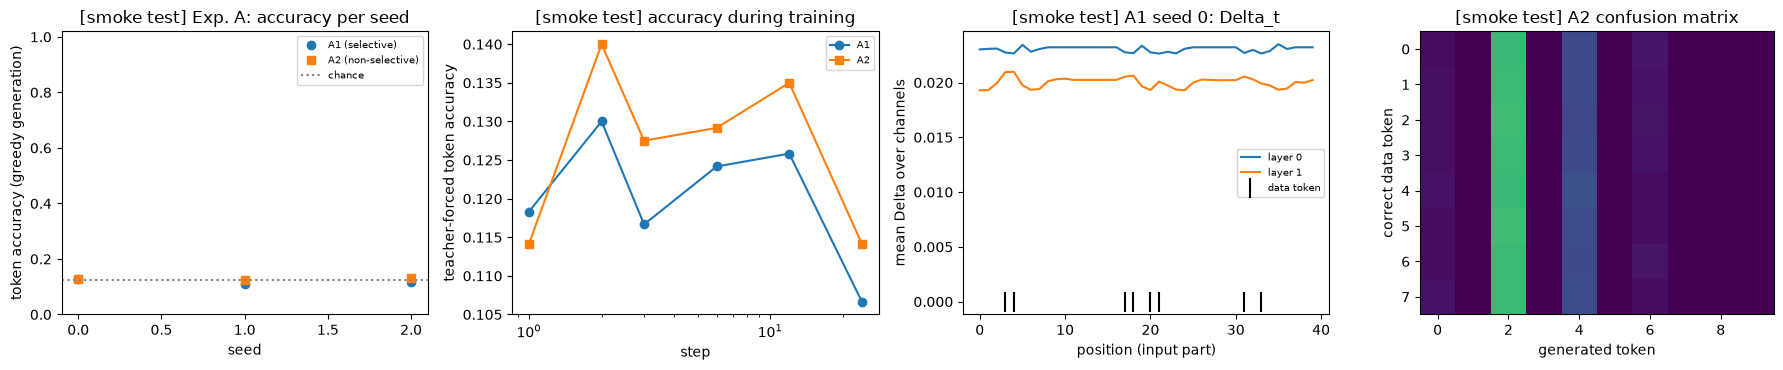

In [13]:
_seeds = list(range(SEEDS_A))
ACCURACY_A1 = np.array([RUNS[("A1", s)]["final"]["token_accuracy"] for s in _seeds])
ACCURACY_A2 = np.array([RUNS[("A2", s)]["final"]["token_accuracy"] for s in _seeds])
A_PER_SEED = ACCURACY_A1 - ACCURACY_A2
# 評価の事例(系列)を再標本化するブートストラップ。系列ごとの正解数 / 答えのトークン数 の比を、全条件・全シードに同じ再標本で作る
_correct_counts = np.stack(
    [RUNS[(kind, s)]["final"]["correct"].sum(axis=1) for kind in ("A1", "A2") for s in _seeds]
).astype(np.float64)
_denominators = np.full(_correct_counts.shape[1], float(TASK_A.num_data))
_boot = paired_bootstrap_ratio_of_sums(_correct_counts, _denominators, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
_boot_contrast = _boot[:, :SEEDS_A].mean(axis=1) - _boot[:, SEEDS_A:].mean(axis=1)
DELTA_A = float(A_PER_SEED.mean())
SIGMA_A = combined_sigma(A_PER_SEED, _boot_contrast)

_health = {(kind, s): learning_precondition(RUNS[(kind, s)]) for kind in ("A1", "A2") for s in _seeds}
precondition_status["P1(A)"] = all(_health.values())
precondition_status["P2(A)"] = float(ACCURACY_A2.mean()) <= A_ROOM_MAX
A_PRECONDITIONS = ["P0(A)", "P1(A)", "P2(A)"]
A_COMPUTED = judge(DELTA_A, SIGMA_A["sigma"])
A_VERDICT = A_COMPUTED if all(precondition_status[k] for k in A_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 A(シード {_seeds}、学習 {NUM_STEPS} ステップ)")
print(f"  正解率 a_1(選択的): {rounded(ACCURACY_A1)}、a_2(非選択): {rounded(ACCURACY_A2)}")
print(f"  d_s = a_1 - a_2: {rounded(A_PER_SEED)}")
print(
    f"  Delta_A = {DELTA_A:+.4f}、sigma_A = {SIGMA_A['sigma']:.4f}(シード間 {SIGMA_A['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_A['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_A = {SIGMA_MULTIPLIER * SIGMA_A['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(A)']}、P1 {precondition_status['P1(A)']}(不成立の学習 {[k for k, v in _health.items() if not v] or 'なし'})、"
    f"P2(改善の余地) {precondition_status['P2(A)']}(a_2 のシード平均 {ACCURACY_A2.mean():.4f} <= {A_ROOM_MAX})"
)
print(f"  判定関数の結果 {A_COMPUTED} -> {RUN_TAG}最終判定: {A_VERDICT}")

# --- 診断量(判定なし) ---
print(
    f"  診断量: 系列全体の一致の割合 A1 {rounded([RUNS[('A1', s)]['final']['exact_match'] for s in _seeds])}、"
    f"A2 {rounded([RUNS[('A2', s)]['final']['exact_match'] for s in _seeds])}(偶然の水準: トークン単位 {TASK_A.chance_accuracy:.3f})"
)
for _kind in ("A1", "A2"):
    _position = np.mean([RUNS[(_kind, s)]["final"]["position_accuracy"] for s in _seeds], axis=0)
    print(f"  診断量: {_kind} の答えの位置ごとの正解率(シード平均、1 番目〜{TASK_A.num_data} 番目) {rounded(_position, 3)}")
print(
    f"  診断量: 非埋め込みパラメータ数 A1 {count_non_embedding_parameters(build_model('A1', 0)):,}、"
    f"A2 {count_non_embedding_parameters(build_model('A2', 0)):,}(差の内訳は 5.5 節の出力 11: 選択的は selection_projection と delta_projection の重みを持ち、"
    f"非選択は B・C のパラメータと delta_bias を持つ)"
)


def confusion_matrix(kind: str) -> np.ndarray:
    # 行: 正解のデータのトークン、列: 生成したトークン(データ 8 種類 + ノイズ + 区切り)。全シード・全評価事例・全位置を合計して行ごとに正規化
    matrix = np.zeros((TASK_A.num_symbols, TASK_A.vocabulary_size))
    targets = EVAL_A_TOKENS[:, TASK_A.input_length + 1 :].numpy()
    for s in _seeds:
        generated = RUNS[(kind, s)]["final"]["answers"]
        np.add.at(matrix, (targets.reshape(-1), generated.reshape(-1)), 1)
    return matrix / matrix.sum(axis=1, keepdims=True)


CONFUSION = {kind: confusion_matrix(kind) for kind in ("A1", "A2")}
for _kind in ("A1", "A2"):
    _matrix = CONFUSION[_kind]
    _off = _matrix[:, : TASK_A.num_symbols].copy()
    np.fill_diagonal(_off, 0.0)
    print(
        f"  診断量: {_kind} の混同行列(正解 -> 生成): 対角の平均 {np.mean(np.diag(_matrix)):.3f}、データ以外のトークン(ノイズ・区切り)を生成した割合 "
        f"{_matrix[:, TASK_A.num_symbols :].sum(axis=1).mean():.4f}、データのトークンどうしの誤りで最大の 1 セル {_off.max():.3f}"
    )

# 作用点に近い診断量: 条件 A1 の Δ_t(チャネルについての平均)の、入力部分のデータのトークンの位置とノイズのトークンの位置での平均
_probe = [RUNS[("A1", s)]["delta_probe"] for s in _seeds]
for _layer in range(SYN_NUM_LAYERS):
    _data = np.array([p["data"][_layer] for p in _probe])
    _noise = np.array([p["noise"][_layer] for p in _probe])
    _sep = np.array([p["separator"][_layer] for p in _probe])
    _ans = np.array([p["answer"][_layer] for p in _probe])
    print(
        f"  診断量(作用点に近い量): A1 の層 {_layer} の Δ の平均 データ {_data.mean():.4f}(各シード {rounded(_data, 4)})、"
        f"ノイズ {_noise.mean():.4f}(各シード {rounded(_noise, 4)})、データ / ノイズ = {np.mean(_data / _noise):.2f}、"
        f"区切り {_sep.mean():.4f}、答えの区間 {_ans.mean():.4f}"
    )

_fig, _axes = plt.subplots(1, 4, figsize=(18, 3.8))
_axes[0].plot(_seeds, ACCURACY_A1, "o", label="A1 (selective)")
_axes[0].plot(_seeds, ACCURACY_A2, "s", label="A2 (non-selective)")
_axes[0].axhline(TASK_A.chance_accuracy, color="gray", linestyle=":", label="chance")
_axes[0].set(xlabel="seed", ylabel="token accuracy (greedy generation)", title=f"{PLOT_TAG}Exp. A: accuracy per seed", ylim=(0, 1.02))
_axes[0].legend(fontsize=7)
for _kind, _marker in (("A1", "o"), ("A2", "s")):
    _curve = np.array([[c["accuracy"] for c in RUNS[(_kind, s)]["curve"]] for s in _seeds])
    _axes[1].plot(RUNS[(_kind, 0)]["eval_step"], _curve.mean(axis=0), marker=_marker, label=_kind)
_axes[1].set(xscale="log", xlabel="step", ylabel="teacher-forced token accuracy", title=f"{PLOT_TAG}accuracy during training")
_axes[1].legend(fontsize=7)
_example = RUNS[("A1", 0)]["delta_probe"]
for _layer in range(SYN_NUM_LAYERS):
    _axes[2].plot(_example["example"][_layer][: TASK_A.input_length], label=f"layer {_layer}")
_data_positions = np.flatnonzero(_example["example_is_data"])
_axes[2].scatter(_data_positions, np.zeros(len(_data_positions)), marker="|", color="k", s=200, label="data token")
_axes[2].set(xlabel="position (input part)", ylabel="mean Delta over channels", title=f"{PLOT_TAG}A1 seed 0: Delta_t")
_axes[2].legend(fontsize=7)
_axes[3].imshow(CONFUSION["A2"], vmin=0, vmax=1, cmap="viridis")
_axes[3].set(xlabel="generated token", ylabel="correct data token", title=f"{PLOT_TAG}A2 confusion matrix")
plt.tight_layout()
plt.show()

### 6.8 実験 B: 計算量のべき指数

6.3 節で定義した層・水準・計測の関数を使い、掃引 $R$ 回 × 反復 $K$ 回を計測する(ウォームアップは 6.3 節で済んでいる)。

[スモークテスト] 実験 B(系列長 (512, 1024, 2048)、掃引 3 回 x 反復 3 回、デバイス mps)
  掃引ごとのべき指数 b_1(Mamba の層): [1.009, 0.849, 0.894]、b_2(注意機構の層): [0.722, 1.012, 0.608]
  掃引ごとの Delta_B = b_2 - b_1: [-0.286, 0.164, -0.286]
  Delta_B = -0.1361、sigma_B = 0.1499(掃引ごとの Delta_B の標準偏差 0.2597 / sqrt(3))、閾値 2 sigma_B = 0.2999
  前提条件: P-B1(ドリフトなし) True(不成立 なし)、P-B2(平均の標準誤差 <= 平均の 5%) False(不成立 [('mamba', 512), ('attention', 512), ('attention', 1024), ('attention', 2048)]、比の最大 0.7044)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量: b_1 = 0.917(理論値 1 との差 -0.083)、b_2 = 0.781(理論値 2 との差 -1.219)。掃引ごとの回帰の標準誤差の平均 b_1 0.087・b_2 0.266
  診断量: 水準ごとの時間の中央値(全掃引・全反復、ミリ秒):
    mamba: 512: 72.64、1024: 155.07、2048: 281.23
    attention: 512: 2.91、1024: 4.52、2048: 9.69
  診断量: 水準ごとの P-B1 の先頭 3 反復 / 末尾 3 反復の平均(ミリ秒)と P-B2 の標準誤差 / 平均:
    mamba: 512: 76.85/71.85・0.0552、1024: 160.03/152.30・0.0405、2048: 307.23/276.61・0.0430
    attention: 512: 8.91/3.57・0.3890、1024: 34.94/3.73・0.7044、2048: 12.69/9.73・0.1109
  診断量: 最大メモリは CUDA でのみ測る(このデバイスでは未計

  診断量: 推論時の 1 トークンあたり — Mamba の 1 ステップ更新 1.393 ms、状態 19,456 バイト(文脈の長さによらず一定)。注意機構(KV キャッシュつき、1 層): 文脈 512: 15.644 ms・KV キャッシュ 545,792 バイト、文脈 2048: 16.629 ms・KV キャッシュ 2,118,656 バイト、文脈 8192: 16.135 ms・KV キャッシュ 8,410,112 バイト(逐次ループの実装の絶対時間は公式実装を代表しない)


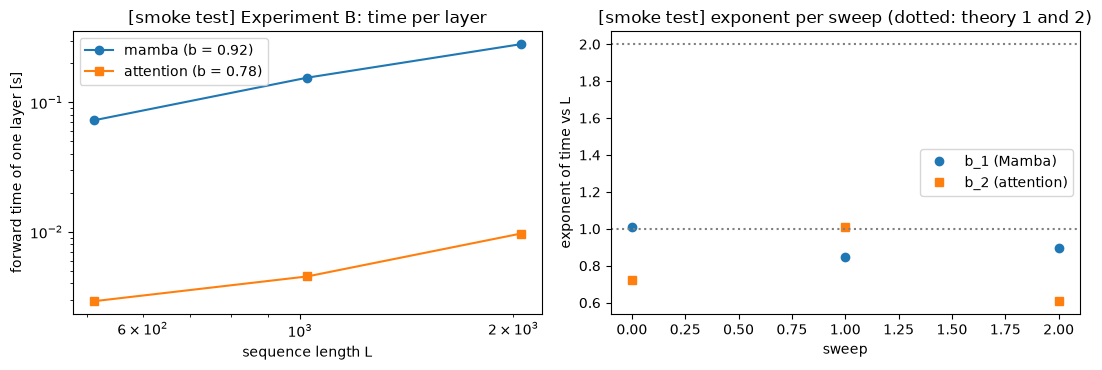

実験 B の計測 0.1 分(見積もり 0.3 分)


In [14]:
_t0_b = time.time()
B_RAW = {c: {length: [[] for _ in range(B_SWEEPS)] for length in B_LEVELS} for c in ("mamba", "attention")}
for _sweep in range(B_SWEEPS):
    for _repeat in range(B_REPEATS):
        _times = run_b_pass(_sweep * B_REPEATS + _repeat)
        for _c, _by_length in _times.items():
            for _length, _seconds in _by_length.items():
                B_RAW[_c][_length][_sweep].append(_seconds)
B_MEASURE_SECONDS = time.time() - _t0_b


def series_in_time_order(condition: str, length: int) -> np.ndarray:
    return np.array([t for sweep in B_RAW[condition][length] for t in sweep])


def compute_p0a(values) -> dict:
    # P-B1(ウォームアップの担保): 先頭 3 反復の平均と末尾 3 反復の平均の差が、全反復の標準偏差(ddof=1)の 2 倍以内か
    arr = np.asarray(values)
    diff = abs(float(arr[-3:].mean()) - float(arr[:3].mean()))
    threshold = P0A_MAX_DRIFT_SIGMA * float(arr.std(ddof=1))
    return {"head_mean": float(arr[:3].mean()), "tail_mean": float(arr[-3:].mean()), "diff": diff, "threshold": threshold, "holds": bool(diff <= threshold)}


def compute_p0b(values) -> dict:
    # P-B2(判定精度の担保): 平均の標準誤差(標準偏差 ddof=1 / sqrt(反復回数))が平均の 5% 以下か
    arr = np.asarray(values)
    stderr = float(arr.std(ddof=1)) / math.sqrt(len(arr))
    return {"mean": float(arr.mean()), "stderr": stderr, "ratio": stderr / float(arr.mean()), "holds": bool(stderr / float(arr.mean()) <= P0B_MAX_RELATIVE_STDERR)}


P0A = {(c, L): compute_p0a(series_in_time_order(c, L)) for c in B_RAW for L in B_LEVELS}
P0B = {(c, L): compute_p0b(series_in_time_order(c, L)) for c in B_RAW for L in B_LEVELS}
precondition_status["P-B1"] = all(v["holds"] for v in P0A.values())
precondition_status["P-B2"] = all(v["holds"] for v in P0B.values())

# 掃引ごとのべき指数: 水準ごとの中央値の対数に対する回帰(水準が独立な単位。擬似反復を避ける)
B_FITS = {c: [] for c in B_RAW}
for _sweep in range(B_SWEEPS):
    for _c in B_RAW:
        _medians = [float(np.median(B_RAW[_c][L][_sweep])) for L in B_LEVELS]
        B_FITS[_c].append(fit_power_law_exponent(B_LEVELS, _medians))
EXPONENT_MAMBA = np.array([f.exponent for f in B_FITS["mamba"]])
EXPONENT_ATTENTION = np.array([f.exponent for f in B_FITS["attention"]])
B_PER_SWEEP = EXPONENT_ATTENTION - EXPONENT_MAMBA
DELTA_B = float(B_PER_SWEEP.mean())
SIGMA_B = float(B_PER_SWEEP.std(ddof=1)) / math.sqrt(B_SWEEPS)
B_PRECONDITIONS = ["P-B1", "P-B2"]
B_COMPUTED = judge(DELTA_B, SIGMA_B)
B_VERDICT = B_COMPUTED if all(precondition_status[k] for k in B_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 B(系列長 {B_LEVELS}、掃引 {B_SWEEPS} 回 x 反復 {B_REPEATS} 回、デバイス {device.type})")
print(f"  掃引ごとのべき指数 b_1(Mamba の層): {rounded(EXPONENT_MAMBA, 3)}、b_2(注意機構の層): {rounded(EXPONENT_ATTENTION, 3)}")
print(f"  掃引ごとの Delta_B = b_2 - b_1: {rounded(B_PER_SWEEP, 3)}")
print(
    f"  Delta_B = {DELTA_B:+.4f}、sigma_B = {SIGMA_B:.4f}(掃引ごとの Delta_B の標準偏差 {B_PER_SWEEP.std(ddof=1):.4f} / sqrt({B_SWEEPS}))、"
    f"閾値 2 sigma_B = {SIGMA_MULTIPLIER * SIGMA_B:.4f}"
)
_bad_a = [k for k, v in P0A.items() if not v["holds"]]
_bad_b = [k for k, v in P0B.items() if not v["holds"]]
print(
    f"  前提条件: P-B1(ドリフトなし) {precondition_status['P-B1']}(不成立 {_bad_a or 'なし'})、P-B2(平均の標準誤差 <= 平均の "
    f"{P0B_MAX_RELATIVE_STDERR:.0%}) {precondition_status['P-B2']}(不成立 {_bad_b or 'なし'}、比の最大 {max(v['ratio'] for v in P0B.values()):.4f})"
)
print(f"  判定関数の結果 {B_COMPUTED} -> {RUN_TAG}最終判定: {B_VERDICT}")

# --- 診断量(判定なし) ---
print(
    f"  診断量: b_1 = {EXPONENT_MAMBA.mean():.3f}(理論値 1 との差 {EXPONENT_MAMBA.mean() - 1:+.3f})、"
    f"b_2 = {EXPONENT_ATTENTION.mean():.3f}(理論値 2 との差 {EXPONENT_ATTENTION.mean() - 2:+.3f})。掃引ごとの回帰の標準誤差の平均 "
    f"b_1 {np.mean([f.exponent_stderr for f in B_FITS['mamba']]):.3f}・b_2 {np.mean([f.exponent_stderr for f in B_FITS['attention']]):.3f}"
)
print("  診断量: 水準ごとの時間の中央値(全掃引・全反復、ミリ秒):")
for _c in B_RAW:
    print(f"    {_c}: " + "、".join(f"{L}: {1000 * float(np.median(series_in_time_order(_c, L))):.2f}" for L in B_LEVELS))
print("  診断量: 水準ごとの P-B1 の先頭 3 反復 / 末尾 3 反復の平均(ミリ秒)と P-B2 の標準誤差 / 平均:")
for _c in B_RAW:
    print(f"    {_c}: " + "、".join(
        f"{L}: {1000 * P0A[(_c, L)]['head_mean']:.2f}/{1000 * P0A[(_c, L)]['tail_mean']:.2f}・{P0B[(_c, L)]['ratio']:.4f}" for L in B_LEVELS
    ))

# 最大メモリの系列長に対するべき指数(決定的な量なので判定には使わない。CUDA でのみ測る)
if device.type == "cuda":
    _peaks = {c: [] for c in B_RAW}
    for _length in B_LEVELS:
        for _c in B_RAW:
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            _base = torch.cuda.memory_allocated()
            time_layer(_c, _length)
            _peaks[_c].append(torch.cuda.max_memory_allocated() - _base)
    _memory_fits = {c: fit_power_law_exponent(B_LEVELS, _peaks[c]) for c in _peaks}
    print(
        "  診断量: 最大メモリの増分(MiB) "
        + "、".join(f"{c}: {[round(p / 2**20, 1) for p in _peaks[c]]}(べき指数 {_memory_fits[c].exponent:.3f})" for c in _peaks)
    )
else:
    print("  診断量: 最大メモリは CUDA でのみ測る(このデバイスでは未計測)")
_analytic_mamba = [2 * L * B_MAMBA.d_inner * MAMBA_STATE_DIM * 4 for L in B_LEVELS]  # Ā と B̄x の 2 枚(FP32)
_analytic_attention = [3 * B_NUM_HEADS * L**2 * 4 for L in B_LEVELS]  # スコア・マスク後・softmax の 3 枚(FP32)
print(
    f"  診断量(閉形式の下限): 一時テンソルのバイト数のべき指数 Mamba {fit_power_law_exponent(B_LEVELS, _analytic_mamba).exponent:.3f}、"
    f"注意機構 {fit_power_law_exponent(B_LEVELS, _analytic_attention).exponent:.3f}"
)

# 推論時の 1 トークンあたりの時間と状態のサイズ: Mamba の 1 ステップ更新(定数) と、KV キャッシュつきの注意機構(文脈の長さに比例)
DECODE_ROWS = []
with torch.no_grad():
    _state = B_MAMBA.initial_state(1, device, torch.float32)
    _token = torch.randn(1, B_D_MODEL, device=device)
    _mamba_step = lambda: B_MAMBA.step(_token, _state)  # noqa: E731
    timed_call(_mamba_step)
    _mamba_ms = 1000 * float(np.median([timed_call(_mamba_step) for _ in range(20)]))
    _state_bytes = sum(t.numel() * t.element_size() for t in _state)
    for _context in B_DECODE_CONTEXTS:
        _cache = KeyValueCache(1)
        _d_k = B_D_MODEL // B_NUM_HEADS
        _cache.update(0, torch.randn(1, B_NUM_HEADS, _context, _d_k, device=device), torch.randn(1, B_NUM_HEADS, _context, _d_k, device=device))
        _new = torch.randn(1, 1, B_D_MODEL, device=device)
        _attention_step = lambda: B_ATTENTION(_new, _new, _new, kv_cache=_cache, layer_idx=0)  # noqa: E731
        timed_call(_attention_step)
        _attention_ms = 1000 * float(np.median([timed_call(_attention_step) for _ in range(20)]))
        DECODE_ROWS.append((_context, _attention_ms, _cache.memory_bytes()))
print(
    f"  診断量: 推論時の 1 トークンあたり — Mamba の 1 ステップ更新 {_mamba_ms:.3f} ms、状態 {_state_bytes:,} バイト(文脈の長さによらず一定)。"
    + "注意機構(KV キャッシュつき、1 層): "
    + "、".join(f"文脈 {c}: {ms:.3f} ms・KV キャッシュ {b:,} バイト" for c, ms, b in DECODE_ROWS)
    + "(逐次ループの実装の絶対時間は公式実装を代表しない)"
)

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.8))
for _c, _marker in (("mamba", "o"), ("attention", "s")):
    _medians = [float(np.median(series_in_time_order(_c, L))) for L in B_LEVELS]
    _axes[0].plot(B_LEVELS, _medians, marker=_marker, label=f"{_c} (b = {np.mean([f.exponent for f in B_FITS[_c]]):.2f})")
_axes[0].set(xscale="log", yscale="log", xlabel="sequence length L", ylabel="forward time of one layer [s]", title=f"{PLOT_TAG}Experiment B: time per layer")
_axes[0].legend()
_axes[1].plot(range(B_SWEEPS), EXPONENT_MAMBA, "o", label="b_1 (Mamba)")
_axes[1].plot(range(B_SWEEPS), EXPONENT_ATTENTION, "s", label="b_2 (attention)")
_axes[1].axhline(1, color="gray", linestyle=":")
_axes[1].axhline(2, color="gray", linestyle=":")
_axes[1].set(xlabel="sweep", ylabel="exponent of time vs L", title=f"{PLOT_TAG}exponent per sweep (dotted: theory 1 and 2)")
_axes[1].legend()
plt.tight_layout()
plt.show()
print(f"実験 B の計測 {B_MEASURE_SECONDS / 60:.1f} 分(見積もり {B_TOTAL_SECONDS / 60:.1f} 分)")

### 6.9 実験 C: 長さの外挿(induction heads)

[スモークテスト] 実験 C(シード [0, 1, 2]、学習 24 ステップ、L_train = 32、L_test = 128)
  C1: a(L_train) [0.04, 0.05, 0.04]、a(L_test) [0.05, 0.1, 0.04]、d = a(L_train) - a(L_test) [-0.01, -0.05, 0.0]
  C2: a(L_train) [0.08, 0.07, 0.04]、a(L_test) [0.08, 0.02, 0.04]、d = a(L_train) - a(L_test) [0.0, 0.05, 0.0]
  d_s(条件 2 - 条件 1) = [0.01, 0.1, 0.0]
  Delta_C = +0.0367、sigma_C = 0.0386(シード間 0.0318・ブートストラップ 0.0218、反復 1,000)、閾値 2 sigma_C = 0.0771
  前提条件: P0 False、P1 True(不成立の学習 なし)、P2(習得) False(a(L_train) のシード平均 C1 0.0433・C2 0.0633 >= 0.9)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量: 偶然の水準 0.0625。系列長ごとの正解率(シード平均 ± シード間の標準偏差):
    C1: 1x(32): 0.043 ± 0.006、2x(64): 0.053 ± 0.025、4x(128): 0.063 ± 0.032、8x(256): 0.073 ± 0.015、16x(512): 0.057 ± 0.021
    C2: 1x(32): 0.063 ± 0.021、2x(64): 0.063 ± 0.023、4x(128): 0.047 ± 0.031、8x(256): 0.063 ± 0.006、16x(512): 0.077 ± 0.038
  診断量: L_test = 128 の正解率の各シードの値(二峰かどうかが分かる形、昇順): C1 [0.04, 0.05, 0.1]、C2 [0.02, 0.04, 0.08]
  診断量: L_train の各シードの値(昇順): C1 [0.04, 0.04, 0.05]、C2 [0.0

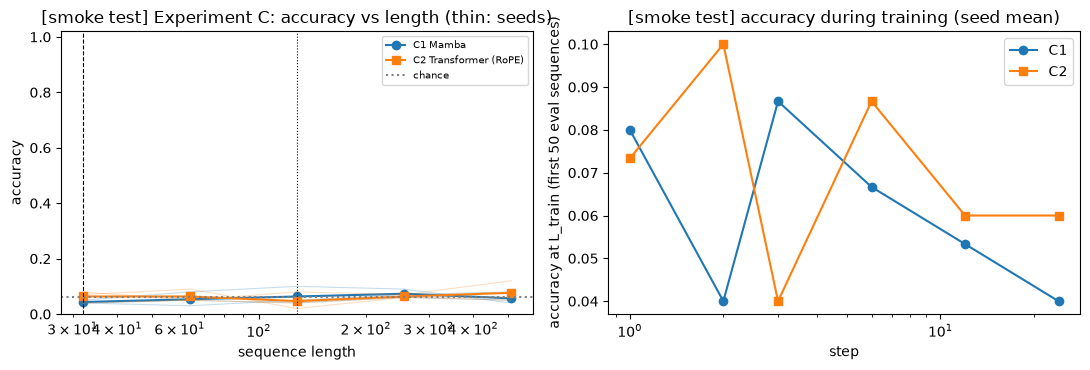

In [15]:
_seeds = list(range(SEEDS_C))


def accuracy_at(kind: str, length: int) -> np.ndarray:
    return np.array([RUNS[(kind, s)]["by_length"][length]["accuracy"] for s in _seeds])


ACCURACY_TRAIN = {kind: accuracy_at(kind, C_TRAIN_LENGTH) for kind in ("C1", "C2")}
ACCURACY_TEST = {kind: accuracy_at(kind, C_TEST_LENGTH) for kind in ("C1", "C2")}
DROP = {kind: ACCURACY_TRAIN[kind] - ACCURACY_TEST[kind] for kind in ("C1", "C2")}  # d_i,s
C_PER_SEED = DROP["C2"] - DROP["C1"]
# 評価の事例を再標本化するブートストラップ。系列長ごとに別の評価集合なので、再標本は系列長ごとに独立に作る。
# 各系列長で、全条件・全シードに同じ再標本を使う
_runs = [(kind, s) for kind in ("C1", "C2") for s in _seeds]
_boot = {}
for _offset, _length in enumerate((C_TRAIN_LENGTH, C_TEST_LENGTH)):
    _correct = np.stack([RUNS[key]["by_length"][_length]["correct"].astype(np.float64) for key in _runs])  # (実行, 事例)
    _boot[_length] = paired_bootstrap_ratio_of_sums(
        _correct, np.ones(_correct.shape[1]), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED + 1 + _offset
    )  # (反復, 実行)
_index = {key: i for i, key in enumerate(_runs)}


def bootstrap_drop(kind: str) -> np.ndarray:
    columns = [_index[(kind, s)] for s in _seeds]
    return (_boot[C_TRAIN_LENGTH][:, columns] - _boot[C_TEST_LENGTH][:, columns]).mean(axis=1)


_boot_contrast = bootstrap_drop("C2") - bootstrap_drop("C1")
DELTA_C = float(C_PER_SEED.mean())
SIGMA_C = combined_sigma(C_PER_SEED, _boot_contrast)

_health = {(kind, s): learning_precondition(RUNS[(kind, s)]) for kind in ("C1", "C2") for s in _seeds}
precondition_status["P1(C)"] = all(_health.values())
precondition_status["P2(C)"] = all(float(ACCURACY_TRAIN[kind].mean()) >= C_MASTERY_MIN for kind in ("C1", "C2"))
C_PRECONDITIONS = ["P0(C)", "P1(C)", "P2(C)"]
C_COMPUTED = judge(DELTA_C, SIGMA_C["sigma"])
C_VERDICT = C_COMPUTED if all(precondition_status[k] for k in C_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 C(シード {_seeds}、学習 {NUM_STEPS} ステップ、L_train = {C_TRAIN_LENGTH}、L_test = {C_TEST_LENGTH})")
for _kind in ("C1", "C2"):
    print(
        f"  {_kind}: a(L_train) {rounded(ACCURACY_TRAIN[_kind])}、a(L_test) {rounded(ACCURACY_TEST[_kind])}、"
        f"d = a(L_train) - a(L_test) {rounded(DROP[_kind])}"
    )
print(f"  d_s(条件 2 - 条件 1) = {rounded(C_PER_SEED)}")
print(
    f"  Delta_C = {DELTA_C:+.4f}、sigma_C = {SIGMA_C['sigma']:.4f}(シード間 {SIGMA_C['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_C['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_C = {SIGMA_MULTIPLIER * SIGMA_C['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(C)']}、P1 {precondition_status['P1(C)']}(不成立の学習 {[k for k, v in _health.items() if not v] or 'なし'})、"
    f"P2(習得) {precondition_status['P2(C)']}(a(L_train) のシード平均 C1 {ACCURACY_TRAIN['C1'].mean():.4f}・C2 {ACCURACY_TRAIN['C2'].mean():.4f} >= {C_MASTERY_MIN})"
)
print(f"  判定関数の結果 {C_COMPUTED} -> {RUN_TAG}最終判定: {C_VERDICT}")

# --- 診断量(判定なし)。「Mamba が正解率を保つ」こと自体は判定の対象ではなく、ここで読む ---
print(f"  診断量: 偶然の水準 {TASK_C.chance_accuracy:.4f}。系列長ごとの正解率(シード平均 ± シード間の標準偏差):")
for _kind in ("C1", "C2"):
    print(
        f"    {_kind}: "
        + "、".join(
            f"{length // C_TRAIN_LENGTH}x({length}): {accuracy_at(_kind, length).mean():.3f} ± {accuracy_at(_kind, length).std(ddof=1):.3f}"
            for length in C_LENGTHS
        )
    )
print(f"  診断量: L_test = {C_TEST_LENGTH} の正解率の各シードの値(二峰かどうかが分かる形、昇順): " + "、".join(
    f"{_kind} {sorted(rounded(ACCURACY_TEST[_kind], 3))}" for _kind in ("C1", "C2")
))
print(f"  診断量: L_train の各シードの値(昇順): " + "、".join(f"{_kind} {sorted(rounded(ACCURACY_TRAIN[_kind], 3))}" for _kind in ("C1", "C2")))
print(
    f"  診断量: 非埋め込みパラメータ数 C1 {count_non_embedding_parameters(build_model('C1', 0)):,}、C2 {count_non_embedding_parameters(build_model('C2', 0)):,}"
)

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.8))
for _kind, _marker, _label in (("C1", "o", "C1 Mamba"), ("C2", "s", "C2 Transformer (RoPE)")):
    _per_length = np.array([accuracy_at(_kind, length) for length in C_LENGTHS])  # (長さ, シード)
    _axes[0].plot(C_LENGTHS, _per_length.mean(axis=1), marker=_marker, label=_label)
    for _s in range(_per_length.shape[1]):
        _axes[0].plot(C_LENGTHS, _per_length[:, _s], color=f"C{0 if _kind == 'C1' else 1}", alpha=0.25, linewidth=0.8)
_axes[0].axhline(TASK_C.chance_accuracy, color="gray", linestyle=":", label="chance")
_axes[0].axvline(C_TRAIN_LENGTH, color="k", linestyle="--", linewidth=0.8)
_axes[0].axvline(C_TEST_LENGTH, color="k", linestyle=":", linewidth=0.8)
_axes[0].set(xscale="log", xlabel="sequence length", ylabel="accuracy", ylim=(0, 1.02), title=f"{PLOT_TAG}Experiment C: accuracy vs length (thin: seeds)")
_axes[0].legend(fontsize=7)
for _kind, _marker in (("C1", "o"), ("C2", "s")):
    _curve = np.array([[c["accuracy"] for c in RUNS[(_kind, s)]["curve"]] for s in _seeds])
    _axes[1].plot(RUNS[(_kind, 0)]["eval_step"], _curve.mean(axis=0), marker=_marker, label=_kind)
_axes[1].set(xscale="log", xlabel="step", ylabel=f"accuracy at L_train (first {CURVE_SEQUENCES} eval sequences)", title=f"{PLOT_TAG}accuracy during training (seed mean)")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.10 実験 D: 言語モデリングの動作確認(判定基準を設けない)

計画で選ばれた学習ステップ数で、Mamba の言語モデルを 008 のレシピで 1 シード学習し、008 の学習済みモデルと同じ評価窓で検証 bits-per-byte を測る。優劣や同等性について結論を書かない。

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)


コーパス: 600,000 文字(取得元 hub)。学習用 570,000 文字(131,596 トークン)、検証 30,000 文字(30,006 バイト、評価窓 26 個、ハッシュ 1afddae075eaf5ab)
実験 D の学習: 16 ステップ x バッチ 32 x 系列長 256 = 131,072 トークン(学習用の 1.00 エポック相当)。008 は 2,181 ステップ(同じ学習量ではない)


[スモークテスト] 実験 D(判定基準を設けない観察)
  非埋め込みパラメータ数 / 総数: Mamba 3,066,368 / 5,163,520、008 のモデル 3,149,056 / 5,246,208(Mamba は 008 の 0.974 倍)
  検証 bits-per-byte(同じ評価窓・同じ評価の関数): Mamba(最終ステップ 16) 2.2479、008 のモデル(Hub の main) 1.0484。途中の Mamba: 2: 2.660, 4: 2.507, 8: 2.326, 16: 2.248
  学習: 損失 8.648 -> 7.496、clipping の発動 0.88、更新のスキップ 0、最後の損失スケール 1


  サンプル(プロンプト 'The history of')
    Mamba(状態を持ち回る生成): 'The history of theession was20a. "R country– Jerseyuić themized Supety speak emergities\n\nFundraisingY hard league She}},{"type":"Feature","properties":{"fill":"#ffffcc","fill-opacit\n\nOrganizationsly Associationh Brownñ Women\'supI cal, Connecticut of thearon\nCalifornia\n\nPrimary e Secretary inst thean,oyur'
    008 のモデル: "The history of the main ride of the country during the world in Europe, and that marriage emerged in the European Republic of India is a nationalist political political pupil. India has condemned the participation in the maintenance. India's foreign"
  サンプル(プロンプト 'In mathematics, a function')
    Mamba(状態を持ち回る生成): "In mathematics, a functionMionords 2,icit highlightedage referend–20 brokeimSA representativeseca, Sar desuissative Plan at the News call coup Lwaysament drop's expressed\n\nState with Commun Border� when itselfheldity global\nP flag\nSh of 28 Fox"
    008 のモデル: 'In mathematics, a function willing 

  診断量: 状態を持ち回る貪欲な生成と文脈を再計算する貪欲な生成の一致したトークンの割合 1.000(FP32、24 トークン)


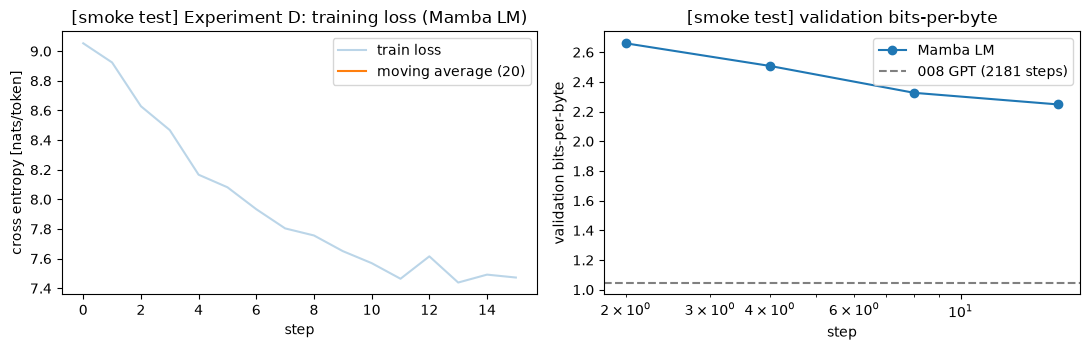

実験 D 1.4 分(見積もり 1.9 分)


In [16]:
_t0_d = time.time()
D_RESULT = None
if D_STEPS is None:
    print(f"{RUN_TAG}実験 D: 選ばれた計画(計画 {SELECTED_PLAN['plan']})では省略した(実行時間の見積もりのみによる選択、6.1 節)")
else:
    # --- コーパス・トークナイザ・評価窓(008 と同じ英語 Wikipedia のコーパスの末尾 5% を検証の部分とする) ---
    d_tokenizer, _loaded = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
    assert _loaded, "トークナイザを Hugging Face Hub から取得できなかった"
    assert d_tokenizer.vocab_size == D_VOCAB_SIZE
    d_corpus, d_corpus_metadata = load_wikipedia_corpus_with_fallback(
        "en", CORPUS_REPO_ID, WIKIPEDIA_CACHE_DIR, manifest_path=MANIFEST_PATH, return_metadata=True
    )
    assert len(d_corpus.encode("utf-8")) == d_corpus_metadata["raw_bytes"], "コーパスの取得が破損している"
    assert d_corpus_metadata["source"] == "hub", f"コーパスの取得元が Hub でない: {d_corpus_metadata['source']}"
    if CFG["D_TRAIN_CHARACTERS"] is not None:  # スモークテストはコーパスの先頭だけを使う
        d_corpus = d_corpus[: CFG["D_TRAIN_CHARACTERS"]]
    d_train_text, d_val_text = split_train_val_text(d_corpus, D_VALIDATION_RATIO)
    d_total_bytes = len(d_val_text.encode("utf-8"))
    d_train_ids, d_val_ids = encode_corpus(d_tokenizer, d_train_text), encode_corpus(d_tokenizer, d_val_text)
    assert d_tokenizer.decode(d_tokenizer.encode(d_train_text[:50_000])) == d_train_text[:50_000], "トークナイザのラウンドトリップが一致しない"
    d_windows, d_mask = make_evaluation_windows(d_val_ids, D_SEQUENCE_LENGTH)
    d_windows_hash = hashlib.sha256(d_windows.numpy().tobytes()).hexdigest()[:16]
    print(
        f"コーパス: {len(d_corpus):,} 文字(取得元 {d_corpus_metadata['source']})。学習用 {len(d_train_text):,} 文字({len(d_train_ids):,} トークン)、"
        f"検証 {len(d_val_text):,} 文字({d_total_bytes:,} バイト、評価窓 {len(d_windows)} 個、ハッシュ {d_windows_hash})"
    )
    print(
        f"実験 D の学習: {D_STEPS} ステップ x バッチ {D_BATCH_SIZE} x 系列長 {D_SEQUENCE_LENGTH} = {D_STEPS * D_BATCH_SIZE * D_SEQUENCE_LENGTH:,} トークン"
        f"(学習用の {D_STEPS * D_BATCH_SIZE * D_SEQUENCE_LENGTH / len(d_train_ids):.2f} エポック相当)。008 は 2,181 ステップ"
        f"({'同じ学習量' if D_STEPS == LEVELS['prod']['D_STEP_CANDIDATES'][0] else '同じ学習量ではない'})"
    )

    # --- 比較の相手: 008 の学習済みモデル(Hub の main)。同じ評価窓・同じ評価の関数(FP32)で測る ---
    from huggingface_hub import hf_hub_download

    _reference_config = json.loads(Path(hf_hub_download(REFERENCE_MODEL_REPO_ID, "config.json")).read_text(encoding="utf-8"))
    _reference_state = hf_hub_download(REFERENCE_MODEL_REPO_ID, "model_state.pt")
    assert _reference_config["vocabulary_size"] == d_tokenizer.vocab_size
    reference_model = GPTLanguageModel(
        vocabulary_size=_reference_config["vocabulary_size"],
        d_model=_reference_config["d_model"],
        num_layers=_reference_config["num_layers"],
        num_heads=_reference_config["num_heads"],
        d_ff=_reference_config["d_ff"],
        max_sequence_length=_reference_config["sequence_length"],
        positional_transform=RotaryPositionEmbedding(
            _reference_config["d_model"] // _reference_config["num_heads"], max_position=_reference_config["sequence_length"]
        ),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, _reference_config["d_model"], _reference_config["swiglu_d_ff"]),
        tie_embeddings=_reference_config["tie_embeddings"],
        dropout=_reference_config["dropout"],
    )
    reference_model.load_state_dict(torch.load(_reference_state, map_location="cpu"))
    reference_model = reference_model.to(device).eval()
    reference_bpb = evaluate_bits_per_byte(reference_model, d_windows, d_mask, d_total_bytes, device)
    reference_parameters = (count_non_embedding_parameters(reference_model), sum(p.numel() for p in reference_model.parameters()))

    # --- Mamba 言語モデルを 008 のレシピで 1 シード学習する ---
    torch.manual_seed(D_SEED)
    d_model_lm = MambaLanguageModel(
        D_VOCAB_SIZE, D_D_MODEL, D_NUM_LAYERS, state_dim=MAMBA_STATE_DIM, expand=MAMBA_EXPAND, conv_kernel=MAMBA_CONV_KERNEL,
        selective=True, discretization="zero_order_hold", use_checkpoint=True,
    )
    d_parameters = (count_non_embedding_parameters(d_model_lm), sum(p.numel() for p in d_model_lm.parameters()))
    assert abs(d_parameters[0] / reference_parameters[0] - 1) <= 0.05, (d_parameters, reference_parameters)  # 非埋め込みパラメータ数は 008 の 5% 以内
    d_eval_steps = tuple(sorted({max(1, round(f * D_STEPS)) for f in D_EVAL_FRACTIONS}))
    d_warmup = max(1, round(WARMUP_RATIO * D_STEPS))
    d_optimizer = AdamW(d_model_lm.parameters(), lr=D_LEARNING_RATE, weight_decay=D_WEIGHT_DECAY, foreach=True)
    d_schedule = functools.partial(
        compute_warmup_cosine_learning_rate, warmup_steps=d_warmup, total_steps=D_STEPS,
        peak_learning_rate=D_LEARNING_RATE, min_learning_rate=D_LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )
    d_history = train_language_model(
        d_model_lm, d_train_ids, d_windows, d_mask, d_total_bytes, num_steps=D_STEPS, batch_size=D_BATCH_SIZE,
        sequence_length=D_SEQUENCE_LENGTH, learning_rate=D_LEARNING_RATE, eval_interval=D_STEPS, device=device, seed=D_SEED,
        optimizer=d_optimizer, learning_rate_schedule=d_schedule, gradient_clip_threshold=D_GRADIENT_CLIP_THRESHOLD,
        autocast_dtype=torch.float16 if USE_FP16_AUTOCAST else None,
        loss_scaler=DynamicLossScaler(D_INIT_LOSS_SCALE, growth_interval=D_LOSS_SCALE_GROWTH_INTERVAL) if USE_FP16_AUTOCAST else None,
        evaluate_at_final_step=True, eval_steps=d_eval_steps,
    )
    assert d_history["eval_step"][-1] == D_STEPS == len(d_history["train_loss"]) and d_history["eval_step"] == list(d_eval_steps)
    mamba_bpb = d_history["eval_bits_per_byte"][-1]  # 学習の最終ステップの重みで評価した値

    print(f"{RUN_TAG}実験 D(判定基準を設けない観察)")
    print(
        f"  非埋め込みパラメータ数 / 総数: Mamba {d_parameters[0]:,} / {d_parameters[1]:,}、008 のモデル {reference_parameters[0]:,} / {reference_parameters[1]:,}"
        f"(Mamba は 008 の {d_parameters[0] / reference_parameters[0]:.3f} 倍)"
    )
    print(
        f"  検証 bits-per-byte(同じ評価窓・同じ評価の関数): Mamba(最終ステップ {D_STEPS}) {mamba_bpb:.4f}、008 のモデル(Hub の main) {reference_bpb:.4f}。"
        f"途中の Mamba: " + ", ".join(f"{s}: {v:.3f}" for s, v in zip(d_history["eval_step"], d_history["eval_bits_per_byte"], strict=True))
    )
    print(
        f"  学習: 損失 {np.mean(d_history['train_loss'][:5]):.3f} -> {np.mean(d_history['train_loss'][-max(5, D_STEPS // 20):]):.3f}、"
        f"clipping の発動 {np.mean(d_history['gradient_clip_triggered']):.2f}、更新のスキップ {int(sum(d_history['step_skipped']))}、"
        f"最後の損失スケール {d_history['loss_scale'][-1]:g}"
    )
    # 状態を持ち回る生成によるサンプル(温度 0.8。比較のため 008 のモデルの同じ温度のサンプルも示す)
    d_model_lm = d_model_lm.to(device)
    D_SAMPLES = []
    for _k, _prompt in enumerate(D_PROMPTS):
        _ids = torch.tensor([d_tokenizer.encode(_prompt)], device=device)
        _mamba_out = d_model_lm.generate(_ids, D_GENERATION_TOKENS, temperature=0.8, seed=_k, use_state=True)
        _ref_out = reference_model.generate(_ids, D_GENERATION_TOKENS, temperature=0.8, seed=_k)
        D_SAMPLES.append((_prompt, d_tokenizer.decode(_mamba_out[0].tolist()), d_tokenizer.decode(_ref_out[0].tolist())))
    for _prompt, _mamba_text, _ref_text in D_SAMPLES:
        print(f"  サンプル(プロンプト {_prompt!r})\n    Mamba(状態を持ち回る生成): {_mamba_text!r}\n    008 のモデル: {_ref_text!r}")
    # 診断量: 状態を持ち回る貪欲な生成と文脈を再計算する貪欲な生成の一致(学習後の FP32 のモデル。FP64 での厳密な一致は 5.4 節で確かめた)
    _probe_ids = torch.tensor([d_tokenizer.encode(D_PROMPTS[0])], device=device)
    _with_state = d_model_lm.generate(_probe_ids, 24, temperature=0.0, use_state=True)
    _without_state = d_model_lm.generate(_probe_ids, 24, temperature=0.0, use_state=False)
    _match = float((_with_state == _without_state).float().mean())
    print(f"  診断量: 状態を持ち回る貪欲な生成と文脈を再計算する貪欲な生成の一致したトークンの割合 {_match:.3f}(FP32、24 トークン)")
    D_RESULT = {"history": d_history, "mamba_bpb": mamba_bpb, "reference_bpb": reference_bpb, "parameters": d_parameters, "samples": D_SAMPLES}

    _fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
    _loss = np.asarray(d_history["train_loss"])
    _kernel = np.ones(min(20, len(_loss))) / min(20, len(_loss))
    _axes[0].plot(_loss, alpha=0.3, label="train loss")
    _axes[0].plot(np.arange(len(_kernel) - 1, len(_loss)), np.convolve(_loss, _kernel, mode="valid"), label="moving average (20)")
    _axes[0].set(xlabel="step", ylabel="cross entropy [nats/token]", title=f"{PLOT_TAG}Experiment D: training loss (Mamba LM)")
    _axes[0].legend()
    _axes[1].plot(d_history["eval_step"], d_history["eval_bits_per_byte"], marker="o", label="Mamba LM")
    _axes[1].axhline(reference_bpb, color="gray", linestyle="--", label="008 GPT (2181 steps)")
    _axes[1].set(xscale="log", xlabel="step", ylabel="validation bits-per-byte", title=f"{PLOT_TAG}validation bits-per-byte")
    _axes[1].legend()
    plt.tight_layout()
    plt.show()
    del d_model_lm, d_optimizer, reference_model
    empty_device_cache()
D_SECONDS = time.time() - _t0_d
print(f"実験 D {D_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['d'] / 60:.1f} 分)")

### 6.11 不変条件のアサーションと`SMOKE_TEST`の配線

- 実効水準の照合: 実際に学習した種類・シード・ステップ数・評価のステップが、5.3 節で印字した水準と 6.4 節で選ばれた計画と一致する。較正も本番と同じ学習ステップ数で行われた。
- 条件間で揃えた量: 較正・計測のシードが実験のシードと共有されない。評価集合・較正用の集合が互いに別である。
- 判定の記録の整合: 各実験の前提条件がすべて記録されている。

In [17]:
# --- 実効水準の照合(SMOKE_TEST の配線): 5.2 節で印字した水準と、選ばれた計画が、実際の学習・評価で使われた値と一致する ---
assert SELECTED_PLAN in PLANS and NUM_STEPS == SELECTED_PLAN["steps"] and EVAL_STEPS == eval_steps_for(NUM_STEPS)
assert NUM_STEPS in (CFG["STEPS"], CFG["STEPS"] // 2) and SEEDS_A in (CFG["SEEDS_FULL"], CFG["SEEDS_CUT"]) and SEEDS_C in (CFG["SEEDS_FULL"], CFG["SEEDS_CUT"])
assert len(EVAL_A_TOKENS) == CFG["EVAL_SEQUENCES"] and all(len(v[0]) == CFG["EVAL_SEQUENCES"] for v in EVAL_C.values())
assert len(CALIBRATION_A_TOKENS) == len(CALIBRATION_C_TOKENS) == CFG["CALIBRATION_SEQUENCES"]
assert BOOTSTRAP_RESAMPLES == CFG["BOOTSTRAP_RESAMPLES"] and tuple(B_LEVELS) == tuple(CFG["B_LEVELS"])
assert set(RUNS) == {(kind, s) for kind in ("A1", "A2") for s in range(SEEDS_A)} | {(kind, s) for kind in ("C1", "C2") for s in range(SEEDS_C)}
for (_kind, _seed), _record in RUNS.items():
    assert _record["num_steps"] == NUM_STEPS and len(_record["train_loss"]) == NUM_STEPS and _record["eval_step"] == list(EVAL_STEPS)
    assert _record["learning_rate"] == LEARNING_RATE[_kind] and _record["kind"] == _kind and _record["seed"] == _seed
for _kind in KINDS:
    assert CALIBRATION[_kind]["num_steps"] == NUM_STEPS  # 較正は本番と同じ学習ステップ数で行った
    assert CALIBRATION[_kind]["chosen"] in CALIBRATION[_kind]["grid"]
assert all(len(B_RAW[c][L]) == B_SWEEPS and all(len(sweep) == B_REPEATS for sweep in B_RAW[c][L]) for c in B_RAW for L in B_LEVELS)
if D_STEPS is not None:
    assert D_RESULT is not None and len(D_RESULT["history"]["train_loss"]) == D_STEPS
else:
    assert D_RESULT is None
# --- 条件間で揃えた量 ---
assert min(CALIBRATION_SEED_INDEX, TIMING_SEED_INDEX) >= max(SEEDS_A, SEEDS_C) and CALIBRATION_SEED_INDEX != TIMING_SEED_INDEX  # 較正・計測のシードは実験のシードと共有しない
assert DATA_SEED_BASE["A"] != DATA_SEED_BASE["C"] and EVAL_SEED_A != CALIBRATION_SEED_A and EVAL_SEED_C != CALIBRATION_SEED_C
_evaluation_hashes = {
    "A": hashlib.sha256(EVAL_A_TOKENS.numpy().tobytes()).hexdigest()[:12],
    "C": {L: hashlib.sha256(v[0].numpy().tobytes()).hexdigest()[:12] for L, v in EVAL_C.items()},
}
assert not torch.equal(CALIBRATION_A_TOKENS, EVAL_A_TOKENS) and not torch.equal(CALIBRATION_C_TOKENS, EVAL_C[C_TRAIN_LENGTH][0])  # 較正用の集合は評価集合と別
# --- 判定の記録の整合 ---
for _name, _keys in (("A", A_PRECONDITIONS), ("B", B_PRECONDITIONS), ("C", C_PRECONDITIONS)):
    assert all(k in precondition_status for k in _keys), (_name, _keys)
print(
    f"{RUN_TAG}実効水準の照合: 計画 {SELECTED_PLAN['plan']}(A のシード {SEEDS_A}・C のシード {SEEDS_C}・学習 {NUM_STEPS} ステップ・"
    f"D {D_STEPS})が、学習した全記録({len(RUNS)} 回)・較正({len(KINDS)} 条件)・実験 B の記録({B_SWEEPS} x {B_REPEATS} 回)・実験 D と一致: OK"
)
print(f"評価集合のハッシュ: {json.dumps(_evaluation_hashes)}")

[スモークテスト] 実効水準の照合: 計画 0(A のシード 3・C のシード 3・学習 24 ステップ・D 16)が、学習した全記録(12 回)・較正(4 条件)・実験 B の記録(3 x 3 回)・実験 D と一致: OK
評価集合のハッシュ: {"A": "181b9270ea1b", "C": {"32": "11259f524744", "64": "beea949cebec", "128": "00a3fab2e183", "256": "4c6c244dd30c", "512": "8438bd255cf9"}}


### 6.12 判定結果の一覧

In [18]:
print(f"{RUN_TAG}判定結果(計画 {SELECTED_PLAN['plan']}、学習 {NUM_STEPS} ステップ、実験 A・C のシード {SEEDS_A}・{SEEDS_C})")
print(
    f"  実験 A: {A_VERDICT}(判定関数の結果 {A_COMPUTED}、Delta_A = {DELTA_A:+.4f}、閾値 {SIGMA_MULTIPLIER * SIGMA_A['sigma']:.4f}、"
    f"前提条件 {json.dumps({k: precondition_status[k] for k in A_PRECONDITIONS})})"
)
print(
    f"  実験 B: {B_VERDICT}(判定関数の結果 {B_COMPUTED}、Delta_B = {DELTA_B:+.4f}、閾値 {SIGMA_MULTIPLIER * SIGMA_B:.4f}、"
    f"前提条件 {json.dumps({k: precondition_status[k] for k in B_PRECONDITIONS})})"
)
print(
    f"  実験 C: {C_VERDICT}(判定関数の結果 {C_COMPUTED}、Delta_C = {DELTA_C:+.4f}、閾値 {SIGMA_MULTIPLIER * SIGMA_C['sigma']:.4f}、"
    f"前提条件 {json.dumps({k: precondition_status[k] for k in C_PRECONDITIONS})})"
)
print("  実験 D: 判定基準を設けない観察(上の 6.10 節の出力)" if D_STEPS is not None else "  実験 D: 省略(選ばれた計画)")
_total = time.time() - NOTEBOOK_START_TIME
print(
    f"全体の経過時間 {_total / 60:.1f} 分(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分、6.4 節の見積もり "
    f"{(ELAPSED_AT_SELECTION + PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total']) / 60:.1f} 分)"
)

[スモークテスト] 判定結果(計画 0、学習 24 ステップ、実験 A・C のシード 3・3)
  実験 A: 前提不成立(判定関数の結果 判定不能、Delta_A = -0.0083、閾値 0.0138、前提条件 {"P0(A)": false, "P1(A)": true, "P2(A)": true})
  実験 B: 前提不成立(判定関数の結果 判定不能、Delta_B = -0.1361、閾値 0.2999、前提条件 {"P-B1": true, "P-B2": false})
  実験 C: 前提不成立(判定関数の結果 判定不能、Delta_C = +0.0367、閾値 0.0771、前提条件 {"P0(C)": false, "P1(C)": true, "P2(C)": false})
  実験 D: 判定基準を設けない観察(上の 6.10 節の出力)
全体の経過時間 4.2 分(予算 120 分、6.4 節の見積もり 8.6 分)


## 7. 結果・考察 / Results and Discussion

**この節の本文は、本番実行(Google Colab T4、`SMOKE_TEST = False`)の後に、実際のセル出力と突き合わせて書く。** 現在のセル出力はスモークテスト(ステップ数を極端に縮小したもの)であり、数値にも判定にも意味はない。以下は、各節に何を書くかの一覧である。

判定(7.3〜7.5 節)は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は 7.8 節に分けて記し、検証済みの結論としては扱わない。

### 7.1 実行の概要

- 実行環境(5.1 節の印字を出典とする): GPU、Python・torch・CUDA・cuDNN の版、コミット、実行日時、精度。
- 準備と計測の時間、定常状態の 1 ステップの時間(種類ごと、実験 D)、べき指数とべき乗則の外挿と比例の値の差、バッチサイズへの依存。
- 選ばれた実行計画と、見積もりと実際の時間の対応。
- 学習率の較正の結果(格子点ごとの値、拡張の有無、選んだ学習率)。

### 7.2 前提条件

- P0〜P2 と P-B1・P-B2 の成否を実験ごとに表にする。不成立があれば、その実験は「前提不成立」として記録し、判定関数の参考値を結論として書かない。

### 7.3 実験 A: 選択性(selective copying)

- 最終判定、$\Delta_A$・$\sigma_A$(シード間とブートストラップの内訳)・閾値。検出力の事前確認(6.2 節)の見込みと、実際の $\sigma_A$ の対応。
- 診断量: 各シードの正解率(二峰かどうか)、系列全体の一致、答えの位置ごとの正解率、混同行列(誤りの構造)、途中の評価の推移、条件 1 の $\Delta_t$ のデータの位置とノイズの位置での平均(3.5 節の予測との対応)。

### 7.4 実験 B: 計算量のべき指数

- 最終判定、$\Delta_B$・$\sigma_B$・閾値。$b_1$・$b_2$ と理論値との差。前提条件 P-B1・P-B2 の成否。
- 診断量: 水準ごとの時間の中央値、最大メモリのべき指数(CUDA)、推論時の 1 トークンあたりの時間と状態のサイズ。逐次ループの実装の絶対時間は公式実装を代表しないことを明記する。

### 7.5 実験 C: 長さの外挿(induction heads)

- 最終判定、$\Delta_C$・$\sigma_C$・閾値。前提条件 P2(C)(習得)の成否。
- 診断量: 系列長ごとの正解率の曲線、偶然の水準との比較、各シードの値(二峰かどうか)。結論は RoPE を使う Transformer に限られることを明記する。

### 7.6 実験 D: 言語モデリングの動作確認(判定基準を設けない)

- 学習曲線、検証 bits-per-byte(Mamba と 008 のモデル)、学習ステップ数が 008 と違う場合は同じ学習量の比較ではないこと、サンプルのテキストの読み取り。優劣や同等性について結論を書かない。1 シードの観察であることを明記する。

### 7.7 実行時間と見積もりの対応

- 見積もりと実際の時間(較正・本番・実験 B・実験 D)、選ばれた計画の妥当性。

### 7.8 事後的な解釈(検証済みの結論ではない)

最終判定が支持以外(反証・判定不能・前提不成立)になった実験について、「なぜそうなったか」を次の 4 項目で書く。前提不成立の実験では、「なぜ前提が崩れたか」と「判定関数の参考値がなぜその向きになったか」を別々の問いとして扱う。

| 項目 | 書くこと |
|---|---|
| 原因の候補 | 設計(条件・水準・較正の格子・学習量など)と、実際に起きた現象の両面から挙げる |
| 根拠 | セル出力の診断量のうち、その候補を支持または否定するもの。根拠となる数値がない候補は、その旨を明記する |
| 確かめる方法 | その候補が正しいかを検証するには、どういう追加の実験が要るか(実行はしない) |
| 教訓 | 次のトピックの設計に持ち越せる一般的な事項 |

- 実験 A・B・C(該当する場合)
- 共通: 結論の一般化の制約(モデルとデータの規模、合成課題であること、学習量、逐次ループの実装であること、1 台の GPU 上の計測であること)

### 本番実行の後に更新が必要な箇所

1. 5.1 節のセットアップセルの`SMOKE_TEST`を`False`にして実行した出力に、全セルの出力を置き換える(Colab で実行)。
2. 1.2 節「本番実行の結果の要約」を記入する。
3. 7.1〜7.8 節の本文を、本番のセル出力と突き合わせて書く(7.8 節は、支持以外の判定になった実験について 4 項目を書く)。
4. `theories/README.md`の 023 の行に、結果の要約を追記する。
5. 本番のセットアップセルに印字されたコミットが、第 1 段階の完了のコミットかその子孫であることを確かめる。